# Machine Learning for Credit Risk Modeling: Predicting Customer Loan Default Using Financial and Behavioral Data

### Ploblem statement

Financial institutions face significant challenges in identifying loan applicants who are likely to default while ensuring that creditworthy customers are not unfairly rejected. Traditional credit risk assessment methods may fail to capture complex relationships within large and diverse financial datasets, leading to poor lending decisions and increased financial losses. This project aims to develop a machine learning model that predicts the probability of customer loan default using the Home Credit Default Risk dataset. By leveraging customer demographic information, financial history, credit bureau records, previous loan applications, installment payments, credit card activity, and POS/Cash loan history, the model seeks to improve credit risk assessment and support more accurate, data-driven lending decisions.

## Importing Libraries

In [1]:
# Core libraries used in almost every cell below
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make inline plots render in Jupyter
%matplotlib inline

### Downloading the raw data

Pulls all 8 tables from the Hugging Face mirror of the competition. Saves each as a CSV into the `data/` folder.

In [2]:
from datasets import load_dataset
import pandas as pd
import os
import gc


# Make sure the data folder exists

folder = "Home_Credit_Data"
os.makedirs(folder, exist_ok=True)

# Home Credit dataset configurations

configs = {
    "application_train_dated": "application_train.csv",
    "application_test": "application_test.csv",
    "bureau": "bureau.csv",
    "bureau_balance": "bureau_balance.csv",
    "previous_application": "previous_application.csv",
    "POS_CASH_balance": "POS_CASH_balance.csv",
    "credit_card_balance": "credit_card_balance.csv",
    "installments_payments": "installments_payments.csv",
    "sample_submission": "sample_submission.csv"
}

print("=" * 60)
print("Downloading Home Credit Default Risk Dataset")
print("=" * 60)

for config_name, output_file in configs.items():

    print(f"\nLoading: {config_name}")

    try:
        dataset = load_dataset(
            "mohameddhameem/home-credit-default-risk",
            config_name
        )

         # Convert the HF dataset split to a pandas DataFrame
        df = dataset["train"].to_pandas()

         # Save to CSV so the rest of the notebook can work with plain pandas
        save_path = os.path.join("data", output_file)
        df.to_csv(save_path, index=False)

        print(f"✓ Saved: {output_file}")
        print(f"  Shape: {df.shape}")

        # Free memory before moving to the next (large) table
        del dataset
        del df
        gc.collect()

    except Exception as e:
        print(f"✗ Failed: {config_name}")
        print(e)

print("\n" + "=" * 60)
print("Download Complete!")
print("=" * 60)

c:\Users\User\Desktop\final project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading: application_train_dated


✓ Saved: application_train.csv
  Shape: (307511, 123)

Loading: application_test
✓ Saved: application_test.csv
  Shape: (48744, 121)

Loading: bureau
✓ Saved: bureau.csv
  Shape: (1716428, 17)

Loading: bureau_balance
✓ Saved: bureau_balance.csv
  Shape: (27299925, 3)

Loading: previous_application
✓ Saved: previous_application.csv
  Shape: (1670214, 37)

Loading: POS_CASH_balance
✓ Saved: POS_CASH_balance.csv
  Shape: (10001358, 8)

Loading: credit_card_balance
✓ Saved: credit_card_balance.csv
  Shape: (3840312, 23)

Loading: installments_payments
✓ Saved: installments_payments.csv
  Shape: (13605401, 8)

Loading: sample_submission
✓ Saved: sample_submission.csv
  Shape: (48744, 2)

Download Complete!


In [3]:
# Load the primary applicant-level table and take a first look
train = pd.read_csv("data/application_train.csv")

print("Shape:", train.shape)
train.head()

Shape: (307511, 123)


,SK_ID_CURR,application_date,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,2018-01-01,1,Cash loans,M,N,Y,0,202500.0,406597.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,2018-01-01,0,Cash loans,F,N,N,0,270000.0,1293502.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,2018-01-01,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,2018-01-01,0,Cash loans,F,N,Y,0,135000.0,312682.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,2018-01-01,0,Cash loans,M,N,Y,0,121500.0,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
##
import os

print("Current working directory:", os.getcwd())
print()
print("Contents of cwd:", os.listdir())
print()

# Search a few likely spots
for candidate in ["data", "Home_Credit_Data", "./data", "../data"]:
    if os.path.exists(candidate):
        print(f"Found folder: {candidate} ->", os.listdir(candidate)[:10])

Current working directory: c:\Users\User\Desktop\final project

Contents of cwd: ['.venv', 'data', 'Home_Credit_Data', 'home_credit_defult.ipynb', 'household_power_consumption.ipynb', 'household_power_consumption_forecasting_and_clustering.py', 'kaggle.py', 'model_features.pkl', 'output', 'random_forest_sales_forecasting_model.pkl', 'README (2).md', 'Retail Sales Forecasting project.docx', 'superstore_sales_forcasting.ipynb', 'This is a great question.docx', 'train.csv (1).zip', 'Tree Survival Rate Forecasting.docx', '~$ee Survival Rate Forecasting.docx', '~$is is a great question.docx']

Found folder: data -> ['application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'installments_payments.csv', 'POS_CASH_balance.csv', 'previous_application.csv', 'sample_submission.csv', 'trial.pbix']
Found folder: Home_Credit_Data -> []
Found folder: ./data -> ['application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'c



Confirm every expected file landed with a non-trivial row count and the key columns
are present, before the pipeline spends time (and memory) processing them.

In [5]:


folder = "data"   

expected_min_rows = {
    "application_train.csv": 300000,
    "application_test.csv": 45000,
    "bureau.csv": 1700000,
    "bureau_balance.csv": 27000000,
    "previous_application.csv": 1600000,
    "POS_CASH_balance.csv": 9900000,
    "credit_card_balance.csv": 3800000,
    "installments_payments.csv": 13000000,
}

for fname, min_rows in expected_min_rows.items():
    path = os.path.join(folder, fname)
    if not os.path.exists(path):
        print(f"✗ MISSING: {fname}")
        continue
    n_rows = sum(1 for _ in open(path)) - 1
    status = "OK" if n_rows >= min_rows else "⚠ LOWER THAN EXPECTED"
    print(f"{fname}: {n_rows:,} rows  [{status}]")

check = pd.read_csv(os.path.join(folder, "application_train.csv"), nrows=5)
print("\napplication_train columns include TARGET:", "TARGET" in check.columns)
print("application_train columns include application_date:", "application_date" in check.columns)

application_train.csv: 307,511 rows  [OK]
application_test.csv: 48,744 rows  [OK]
bureau.csv: 1,716,428 rows  [OK]
bureau_balance.csv: 27,299,925 rows  [OK]
previous_application.csv: 1,670,214 rows  [OK]
POS_CASH_balance.csv: 10,001,358 rows  [OK]
credit_card_balance.csv: 3,840,312 rows  [OK]
installments_payments.csv: 13,605,401 rows  [OK]

application_train columns include TARGET: True
application_train columns include application_date: True


##  Feature Engineering: Aggregate the Secondary Tables


There are 5 extra tables, and each one has many rows per person (like many past loans per applicant). Since our main table only has one row per person, we will first squish each of these 5 tables down to one row per person - using things like the average, total, and worst-case value to summarize their history. Then we merged each of these summarized tables onto our main table, matching rows by the person's ID. After each merge, we will check that the number of rows don't change, just to make sure nothing gets duplicated by mistake. 

In [6]:

# Define the folder where the input datasets are stored
INPUT_DIR = './data'

# Define the folder where processed files or outputs will be saved
OUTPUT_DIR = './output'

# Create the output folder if it does not already exist
# exist_ok=True prevents an error if the folder already exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

def downcast(df, exclude=('SK_ID_CURR',)):
    """Shrink dtypes to reduce memory footprint (float64->float32, int64->smallest int, etc)."""

    # Loop through every column in the dataframe one at a time
    for col in df.columns:

        if col in exclude:       # Skip columns listed in the exclude parameter
            continue

        if df[col].dtype == 'float64':             # Convert float64 columns to float32 This cuts memory usage roughly in half while maintaining good precision
            df[col] = df[col].astype('float32')

        elif df[col].dtype == 'int64':     # Convert int64 columns to the smallest possible integer type (e.g., int8, int16, int32) depending on the values stored
            df[col] = pd.to_numeric(df[col], downcast='integer')

        # If it's True/False, store it as a tiny integer (0 or 1) instead
        elif df[col].dtype == 'bool':
            df[col] = df[col].astype('int8')

        # If it's text, store it as a "category" type instead of plain text    
        elif df[col].dtype == object:
            df[col] = df[col].astype('category')
            
    return df

The Home Credit dataset contains millions of records across several CSV files. Therfore, two folders are created,  one to read the raw data from, and one to save our results into.This makes sure that save folder actually exists, to avoid crashing later when we try to write a file to it.


The **downcast function** is about saving memory. When data is loaded into into pandas, it often uses more computer memory than it needs to. For example, it might use a big number type to store something small, like someone's age. That's a waste of space.

So this function goes through every column and checks what kind of data it holds, then switches it to a smaller, lighter version that still holds the same information correctly:

* Decimal numbers - switched to a smaller decimal type
* Whole numbers - switched to the smallest whole-number type that fits
* True/False - switched to just 0 or 1
* Text - switched to a more compact text format 

By optimizing data types:

- Memory usage is significantly reduced.
- Data loads and operations become faster.
- The risk of running out of RAM is lower.
- Machine learning preprocessing becomes more efficient, especially when merging multiple large tables.

#### A. Aggregate **bureau_balance** - one row per **SK_ID_BUREAU**

This table is monthly loan status history at *other* credit institutions, keyed by ***SK_ID_BUREAU*** (not ***SK_ID_CURR***), so it has to be aggregated up one level before it can attach to ***bureau***.

In [7]:
# Read the CSV file using optimized data types to reduce memory usage.
# bureau_balance is a largest table in the project (~27 million rows), so specifying smaller data types saves a significant amount of RAM.
bb = pd.read_csv(
    f"{INPUT_DIR}/bureau_balance.csv",
    dtype={"SK_ID_BUREAU": "int32", "MONTHS_BALANCE": "int16", "STATUS": "category"},   # Tell pandas exactly what size/type to use for each column while loading,
    # instead of letting it guess, this saves a lot of memory right from the start
)
print("Loaded bureau_balance:", bb.shape)

# Convert each repayment status into separate binary columns.
# One-hot encode the monthly status flag (0-5 = days-past-due bucket, C = closed, X = unknown)
# This turns the single STATUS column into several 0/1 columns, one per status value
status_dummies = pd.get_dummies(bb["STATUS"], prefix="BB_STATUS")
# Keep only the required columns and combine them with the new dummy variables
bb = pd.concat([bb[["SK_ID_BUREAU", "MONTHS_BALANCE"]], status_dummies], axis=1)

# Aggregate to one row per SK_ID_BUREAU: how many months of history, its span, and how many
# months fell into each status bucket

# Aggregate Monthly Records
# Each loan (SK_ID_BUREAU) has many monthly records. summarize them into a single row
bb_agg = bb.groupby("SK_ID_BUREAU").agg(
    BB_MONTHS_COUNT=("MONTHS_BALANCE", "count"),        # Total number of months recorded
    BB_MONTHS_MIN=("MONTHS_BALANCE", "min"),            # Earliest month available
    BB_MONTHS_MAX=("MONTHS_BALANCE", "max"),            # Most recent month available
)

# Sum each dummy column.
# Since the dummy columns contain only 0 and 1, summing gives the number of months in each status.
bb_agg = bb_agg.join(bb.groupby("SK_ID_BUREAU")[status_dummies.columns].sum())

# Convert the grouped index (loan ID) back into a normal column
bb_agg.reset_index(inplace=True)

# Display the aggregated dataset
print("Aggregated bureau_balance shape:", bb_agg.shape)
# Store the summarized dataset as a Parquet file. Parquet files are smaller, faster to read, and more efficient than CSV files.
bb_agg.to_parquet(f"{OUTPUT_DIR}/agg_bureau_balance.parquet", index=False)

# Delete large objects that are no longer needed. ( The original dataset is very large and is no longer needed after aggregation. Deleting it frees up memory for the next processing steps.)
del bb, status_dummies
# Force Python's garbage collector to release memory.
gc.collect()

Loaded bureau_balance: (27299925, 3)
Aggregated bureau_balance shape: (817395, 12)


0

This table (bureau_balance) is huge - about 27 million rows - and it tracks the monthly status of loans that people had at other banks, not Home Credit itself. Each row is one month of one loan's history.

Since it's so big, the code loads it carefully, telling pandas the exact (small) data type for each column up front, instead of loading it the normal way and shrinking it after.

Each loan's monthly status is a code like "0" (up to date), "1-5" (increasingly overdue), "C" (closed), or "X" (unknown). The code turns that one status column into several yes/no columns  one per possible status  so it can be counted and summed later.

Then it groups everything by loan ID and narrows each loan down to one summary row: how many months of history it has, the first and last month, and how many months it spent in each status.

Finally, it saves this smaller summary table to disk, and clears the big original table out of memory since it's no longer needed - this keeps the notebook from running out of memory when working with such a large file.

#### B. Aggregate **bureau** (+ bureau_balance features) - one row per **SK_ID_CURR**

Past loans at other credit institutions. Each applicant can have many rows here (many past loans), so we one-hot the categoricals, fold in the ***bureau_balance*** aggregates, then group by ***SK_ID_CURR*** with mean/sum/min/max.

In [8]:
# Load the bureau dataset

# Read the bureau.csv file into a DataFrame.
# This dataset contains information about each applicant's previous loans from external credit bureaus.bureau = pd.read_csv(f"{INPUT_DIR}/bureau.csv")
bureau = pd.read_csv(f"{INPUT_DIR}/bureau.csv")

print("Loaded bureau:", bureau.shape)

# Merge with the aggregated bureau_balance dataset. Combine bureau.csv with the aggregated bureau_balance
# using SK_ID_BUREAU as the common key.
# how="left" ensures that every bureau loan is kept, even if it has no matching bureau_balance record.

bureau = bureau.merge(bb_agg, on="SK_ID_BUREAU", how="left")

# One-hot encode the categorical columns (Convert each category into separate binary columns.)
# This allows machine learning algorithms to use categorical variables.
for col in ["CREDIT_ACTIVE", "CREDIT_CURRENCY", "CREDIT_TYPE"]:
    bureau = pd.concat([bureau, pd.get_dummies(bureau[col], prefix=col)], axis=1)

# Select Numeric Columns for Aggregation
# Numeric columns get mean/sum/min/max per applicant (captures typical + extreme loan behavior)
num_cols = [
    # Days since the credit was granted
    "DAYS_CREDIT",
    # Number of overdue days
    "CREDIT_DAY_OVERDUE",
    # Expected credit end date
    "DAYS_CREDIT_ENDDATE",
    # Actual credit closing date
    "DAYS_ENDDATE_FACT",
    # Maximum overdue credit amount
    "AMT_CREDIT_MAX_OVERDUE",
    # Number of times the loan was prolonged
    "CNT_CREDIT_PROLONG",
    # Total credit amount
    "AMT_CREDIT_SUM",
    # Outstanding debt
    "AMT_CREDIT_SUM_DEBT",
    # Credit limit
    "AMT_CREDIT_SUM_LIMIT",
    # Amount currently overdue
    "AMT_CREDIT_SUM_OVERDUE",
    # Last bureau update
    "DAYS_CREDIT_UPDATE",
    # Loan annuity
    "AMT_ANNUITY",
    # Aggregated bureau_balance variables
    "BB_MONTHS_COUNT",
    "BB_MONTHS_MIN",
    "BB_MONTHS_MAX",
]
# Find the names of the new  columns we just created above, to summarize them too
bb_status_cols = [c for c in bureau.columns if c.startswith("BB_STATUS_")]
dummy_cols = [c for c in bureau.columns if c.startswith(("CREDIT_ACTIVE_", "CREDIT_CURRENCY_", "CREDIT_TYPE_"))]

# Define Aggregation Rules
# For every numeric column calculate:Mean, Sum, Minimum, Maximum
agg_dict = {c: ["mean", "sum", "min", "max"] for c in num_cols + bb_status_cols}
# For dummy variables calculate only the mean. Example:CREDIT_ACTIVE_Active Mean = proportion of loans that are Active.
agg_dict.update({c: "mean" for c in dummy_cols})     
# Count the total number of bureau loans each applicant has. 
agg_dict["SK_ID_BUREAU"] = "count" 

# Aggregate to One Row Per Customer
# Group all rows by person (applicant ID), and apply the summary plan above
bureau_agg = bureau.groupby("SK_ID_CURR").agg(agg_dict)
# Rename the resulting columns to be clear and consistent
bureau_agg.columns = ["BUREAU_" + "_".join(col).upper() for col in bureau_agg.columns]
# Turn the applicant ID from an index back into a normal column
bureau_agg.reset_index(inplace=True)

print("Aggregated bureau shape:", bureau_agg.shape)
bureau_agg.to_parquet(f"{OUTPUT_DIR}/agg_bureau.parquet", index=False)

del bureau, bb_agg
gc.collect()


Loaded bureau: (1716428, 17)
Aggregated bureau shape: (305811, 117)


0

This picks up the bureau table - every past loan a person had at other banks, not Home Credit. One person can appear many times here (once per past loan), so just like before, everything needs to be squished down to one row per person.

First, it attaches the monthly-history summary from the earlier step, matching by loan ID, so each loan now also carries info like how many months of history it had.

Then it converts the text columns (like loan status: active, closed, etc.) into simple yes/no columns, since summary math like "average" or "sum" only works on numbers, not text.

After that, it groups everything by person and boils each person's loans down into one row, calculating for each number column: the average, the total, the smallest, and the largest value. This captures both the "typical" loan behavior and the worst-case one (like their biggest overdue amount). For the yes/no columns, it just takes the average, which tells you what share of a person's loans fall into each category (for example, what percent were closed loans).

It also counts how many past loans each person had in total.

Finally, it renames the columns clearly, saves the result, and clears the big tables out of memory to keep things running smoothly.

#### C. Aggregate **POS_CASH_balance** - one row per **SK_ID_CURR**

Monthly balance history on POS/cash loans. This table already carries ***SK_ID_CURR*** directly, so no intermediate ***SK_ID_PREV*** step is needed.

In [9]:
# Load the POS_CASH_balance dataset

# Read the dataset while specifying smaller data types to reduce memory usage.
pos = pd.read_csv(
    f"{INPUT_DIR}/POS_CASH_balance.csv",
    dtype={
        "SK_ID_PREV": "int32",                 # Previous loan ID
        "SK_ID_CURR": "int32",                 # Customer ID
        "MONTHS_BALANCE": "int16",             # Months before current application
        "CNT_INSTALMENT": "float32",           # Total scheduled installments
        "CNT_INSTALMENT_FUTURE": "float32",    # Remaining installments
        "NAME_CONTRACT_STATUS": "category",    # Loan status
        "SK_DPD": "int32",                     # Days Past Due
        "SK_DPD_DEF": "int32",                 # Days Past Due with tolerance
    },
)
print("Loaded POS_CASH_balance:", pos.shape)

# One-hot encode contract status (Active, Completed, Signed, etc.)
status_dummies = pd.get_dummies(pos["NAME_CONTRACT_STATUS"], prefix="POS_STATUS")
# Remove the original status column and append the newly created dummy columns.
pos = pd.concat([pos.drop(columns=["NAME_CONTRACT_STATUS"]), status_dummies], axis=1)

# Define Aggregation Rules

# For numerical variables calculate:Mean,Maximum
agg_dict = {c: ["mean", "max"] for c in ["CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE", "SK_DPD", "SK_DPD_DEF"]}

# For dummy variables calculate the mean. The mean represents the proportion of loans in each contract status.
agg_dict.update({c: "mean" for c in status_dummies.columns})

# Count the number of unique previous POS/Cash loans belonging to each customer.
agg_dict["SK_ID_PREV"] = "nunique" 

# Aggregate to One Row Per Customer
# Group all POS/Cash loans belonging to each customer.
pos_agg = pos.groupby("SK_ID_CURR").agg(agg_dict)
# Rename Columns
pos_agg.columns = ["POS_" + "_".join(col).upper() for col in pos_agg.columns]

# Convert SK_ID_CURR back into a normal column.
pos_agg.reset_index(inplace=True)

print("Aggregated POS_CASH_balance shape:", pos_agg.shape)
pos_agg.to_parquet(f"{OUTPUT_DIR}/agg_pos_cash.parquet", index=False)

del pos, status_dummies
gc.collect()

Loaded POS_CASH_balance: (10001358, 8)
Aggregated POS_CASH_balance shape: (337252, 19)


0

The POS_CASH_balance.csv table records the month-by-month repayment history of customers' Point-of-Sale (POS) and cash loans, meaning each customer can appear many times-once for each month of each loan. To make the data suitable for machine learning, the code summarizes these records into one row per customer (SK_ID_CURR).

It first converts the loan status (e.g., Active, Completed) into numeric dummy variables, then groups all records belonging to the same customer. For each customer, it calculates key features such as the average and maximum number of installments, the average and maximum days past due, the proportion of loans in each contract status, and the total number of unique POS/Cash loans. Finally, it renames the columns, saves the aggregated dataset, and frees memory by deleting the large raw dataset, ensuring efficient processing of the remaining tables.

#### D. Aggregate **credit_card_balance** -  one row per **SK_ID_CURR**

In [10]:

# Load the Credit Card Balance Dataset


# Read the credit_card_balance.csv file.
# This dataset contains monthly information about customers'credit card accounts.

cc = pd.read_csv(f"{INPUT_DIR}/credit_card_balance.csv")

# Display the number of rows and columns loaded
print("Loaded credit_card_balance:", cc.shape)


# One-Hot Encode the Contract Status

# Convert each contract status (e.g., Active, Completed) into binary (0/1) columns.

status_dummies = pd.get_dummies(
    cc["NAME_CONTRACT_STATUS"],
    prefix="CC_STATUS"
)

# Remove the original contract status column and append the dummy variables.

cc = pd.concat(
    [
        cc.drop(columns=["NAME_CONTRACT_STATUS"]),
        status_dummies
    ],
    axis=1
)

# Select Numeric Columns
# These are the numerical variables that describe customers' credit card usage and repayment behavior.

num_cols = [
    # Current outstanding balance
    "AMT_BALANCE",
    # Credit limit
    "AMT_CREDIT_LIMIT_ACTUAL",
    # ATM cash withdrawals
    "AMT_DRAWINGS_ATM_CURRENT",
    # Total withdrawals
    "AMT_DRAWINGS_CURRENT",
    # Other withdrawals
    "AMT_DRAWINGS_OTHER_CURRENT",
    # POS purchases
    "AMT_DRAWINGS_POS_CURRENT",
    # Minimum payment due
    "AMT_INST_MIN_REGULARITY",
    # Current payment
    "AMT_PAYMENT_CURRENT",
    # Total payment
    "AMT_PAYMENT_TOTAL_CURRENT",
    # Principal receivable
    "AMT_RECEIVABLE_PRINCIPAL",
    # Receivable amount
    "AMT_RECIVABLE",
    # Total receivable
    "AMT_TOTAL_RECEIVABLE",
    # Number of ATM withdrawals
    "CNT_DRAWINGS_ATM_CURRENT",
    # Total number of withdrawals
    "CNT_DRAWINGS_CURRENT",
    # Other withdrawals count
    "CNT_DRAWINGS_OTHER_CURRENT",
    # POS withdrawal count
    "CNT_DRAWINGS_POS_CURRENT",
    # Number of completed installments
    "CNT_INSTALMENT_MATURE_CUM",
    # Days past due
    "SK_DPD",
    # Days past due with tolerance
    "SK_DPD_DEF"
]

# Define Aggregation Rules

# For each numeric variable calculate:Mean ,Maximum, Sum

agg_dict = {
    c: ["mean", "max", "sum"]
    for c in num_cols
}

# For contract status dummy variables,calculate the mean (proportion).
agg_dict.update({c: "mean"for c in status_dummies.columns})

# Count the number of unique credit card accounts each customer has had.

agg_dict["SK_ID_PREV"] = "nunique"

# Aggregate to One Row Per Customer
# Group all credit card records belonging to each customer.

cc_agg = cc.groupby("SK_ID_CURR").agg(agg_dict)

# Rename Columns
# Create descriptive column names.
cc_agg.columns = ["CC_" + "_".join(col).upper()for col in cc_agg.columns]

# Convert SK_ID_CURR back into a normal column.
cc_agg.reset_index(inplace=True)

# Display Results
print("Aggregated credit_card_balance shape:", cc_agg.shape)

# Save the Aggregated Dataset
cc_agg.to_parquet(f"{OUTPUT_DIR}/agg_credit_card.parquet",index=False)

# Free Memory
# Delete objects that are no longer needed.
del cc, status_dummies
# Force Python to release unused memory.
gc.collect()

Loaded credit_card_balance: (3840312, 23)
Aggregated credit_card_balance shape: (103558, 66)


0

The credit_card_balance.csv table contains the month-by-month history of customers' credit card accounts, so the same customer can appear many times-once for each month of each credit card account. To prepare the data for machine learning, the code summarizes these records into one row per customer (SK_ID_CURR).

It first converts the credit card contract status (such as Active or Completed) into numeric dummy variables, then groups all records belonging to the same customer. For each customer, it calculates the average, maximum, and total values for key credit card features such as balances, credit limits, payments, withdrawals, receivables, and days past due. It also calculates the proportion of records in each contract status and counts the number of unique credit card accounts each customer has had. Finally, it renames the columns with clear prefixes, saves the aggregated dataset, and frees memory by deleting the large raw dataset before processing the next table.

#### E. Aggregate **previous_application** - one row per **SK_ID_CURR**


In [11]:
# Load the Previous Application Dataset

# Read the previous_application.csv file. Each row represents one previous loan application made by a customer.
prev = pd.read_csv(f"{INPUT_DIR}/previous_application.csv")
print("Loaded previous_application:", prev.shape)

# In this dataset, the value 365243 is a placeholdermeaning "date not available".
# Replace it with NaN (missing value) so it is ignored during statistical calculations.
for col in ["DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE", "DAYS_TERMINATION"]:
    prev[col] = prev[col].replace(365243, np.nan)

# One-hot encode all categorical columns, then take the per-applicant mean of each dummy
# (= "share of previous applications that had this category")
cat_cols = [
    "NAME_CONTRACT_TYPE", "FLAG_LAST_APPL_PER_CONTRACT", "NAME_CASH_LOAN_PURPOSE",
    "NAME_CONTRACT_STATUS", "NAME_PAYMENT_TYPE", "CODE_REJECT_REASON", "NAME_TYPE_SUITE",
    "NAME_CLIENT_TYPE", "NAME_GOODS_CATEGORY", "NAME_PORTFOLIO", "NAME_PRODUCT_TYPE",
    "CHANNEL_TYPE", "NAME_SELLER_INDUSTRY", "NAME_YIELD_GROUP", "PRODUCT_COMBINATION",
]
# Start with the customer ID.
dummy_frames = [prev[["SK_ID_CURR"]]]
# Store the names of all dummy columns.
dummy_cols = []
# Convert each categorical column into dummy variables.
for col in cat_cols:
    d = pd.get_dummies(prev[col], prefix=col)
    dummy_cols.extend(d.columns.tolist())
    dummy_frames.append(d)
# Combine all dummy variables into one DataFrame.
prev_dummies = pd.concat(dummy_frames, axis=1)

# Numeric columns get mean/max/min/sum
num_cols = [
    "AMT_ANNUITY", "AMT_APPLICATION", "AMT_CREDIT", "AMT_DOWN_PAYMENT", "AMT_GOODS_PRICE",
    "RATE_DOWN_PAYMENT", "RATE_INTEREST_PRIMARY", "RATE_INTEREST_PRIVILEGED", "DAYS_DECISION",
    "SELLERPLACE_AREA", "CNT_PAYMENT", "DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE",
    "DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE", "DAYS_TERMINATION", "NFLAG_INSURED_ON_APPROVAL",
]

# For every numeric column calculate:Mean, Maximum, Minimum, Sum
agg_dict = {c: ["mean", "max", "min", "sum"] for c in num_cols}
# Group all previous applications belonging to each customer.
prev_num_agg = prev.groupby("SK_ID_CURR").agg(agg_dict)
prev_num_agg.columns = ["PREV_" + "_".join(col).upper() for col in prev_num_agg.columns]

# Calculate the mean of every dummy column.
# This represents the proportion of previous applications in each category.
prev_dummy_agg = prev_dummies.groupby("SK_ID_CURR")[dummy_cols].mean()
# Rename columns.
prev_dummy_agg.columns = ["PREV_" + c.upper() + "_MEAN" for c in prev_dummy_agg.columns]
# Count how many previous applications each customer has submitted.
prev_count = prev.groupby("SK_ID_CURR")["SK_ID_PREV"].count().rename("PREV_COUNT")
# Merge All Aggregated Features
# Combine: Numeric summaries, Dummy summaries, Application count
prev_agg = prev_num_agg.join(prev_dummy_agg).join(prev_count)
# Convert SK_ID_CURR back into a normal column.
prev_agg.reset_index(inplace=True)
#  Display Results
print("Aggregated previous_application shape:", prev_agg.shape)
# Save the Aggregated Dataset
prev_agg.to_parquet(f"{OUTPUT_DIR}/agg_previous_app.parquet", index=False)

# Free Memory

# Delete large DataFrames that are no longer needed.

del prev
del prev_dummies
del prev_num_agg
del prev_dummy_agg

# Release unused memory.

gc.collect()

Loaded previous_application: (1670214, 37)
Aggregated previous_application shape: (338857, 206)


0

The previous_application.csv table contains information about every previous loan application that customers submitted to Home Credit (as opposed to the bureau table, which contains loans from other financial institutions). Since one customer may have submitted multiple applications over time, they can appear many times in this table. To prepare the data for machine learning, the code summarizes all previous applications into one row per customer (SK_ID_CURR).

The first step addresses a data quality issue where several date columns use the value 365243 as a placeholder to indicate that no date is available. These placeholder values are replaced with NaN (missing values) so they are ignored during statistical calculations and do not distort measures such as averages, minimums, or maximums.

Next, all categorical (text) variables, such as loan purpose, contract status, payment type, and rejection reason, are converted into numeric dummy variables, allowing them to be included in the aggregation process.

The customer-level summary is then created in three parts. First, for each numerical feature-such as loan amounts, interest rates, installment information, and application dates-the code calculates the mean, maximum, minimum, and total across all previous applications. Second, for each dummy variable, it calculates the mean, which represents the proportion of a customer's previous applications that belong to each category (for example, the share of applications that were approved or refused). Finally, it counts the total number of previous loan applications submitted by each customer.

The three sets of aggregated features are then combined into a single customer-level dataset. Lastly, the columns are renamed with clear PREV_ prefixes, the summarized dataset is saved as a Parquet file, and the large intermediate DataFrames are removed from memory to improve efficiency before processing the next dataset.

#### F. Aggregate **installments_payments**

In [12]:

# Load the installments_payments table - the actual record of whether each loan installment was paid on time and in full
inst = pd.read_csv(f"{INPUT_DIR}/installments_payments.csv")
print("Loaded installments_payments:", inst.shape)

# Create New Payment Behaviour Features

# Calculate how many days late (or early) a payment was made.
# Positive value  -> payment was late.
# Zero            -> payment was made on time.
# Negative value  -> payment was made early.
inst["DAYS_LATE"] = inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]       
# Calculate the difference between the expected installment amount and the amount actually paid.
# Positive value -> customer underpaid.
# Zero           -> exact payment.
# Negative value -> customer paid more than required.
inst["AMT_PAYMENT_DIFF"] = inst["AMT_INSTALMENT"] - inst["AMT_PAYMENT"]      

# Calculate the payment ratio.
# 1.0  -> paid exactly the required amount.
# >1   -> overpaid.
# <1   -> underpaid.
# Replace zero installment values with NaN to avoid division-by-zero errors.   
inst["AMT_PAYMENT_RATIO"] = inst["AMT_PAYMENT"] / inst["AMT_INSTALMENT"].replace(0, np.nan)

# List of number columns we want to summarize for each person
num_cols = [
    "NUM_INSTALMENT_VERSION", "DAYS_INSTALMENT", "DAYS_ENTRY_PAYMENT",
    "AMT_INSTALMENT", "AMT_PAYMENT", "DAYS_LATE", "AMT_PAYMENT_DIFF", "AMT_PAYMENT_RATIO",
]

# Define Aggregation Rules

# For every numeric feature calculate:, Mean, Maximum, Minimum, Sum, Standard deviation
agg_dict = {c: ["mean", "max", "min", "sum", "std"] for c in num_cols}
# Count the number of unique previous loans with installment records.
agg_dict["SK_ID_PREV"] = "nunique"       
# Count the total number of installment records.        
agg_dict["NUM_INSTALMENT_NUMBER"] = "count"      

# Aggregate to One Row Per Customer
# Group all installment records belongingto each customer.
inst_agg = inst.groupby("SK_ID_CURR").agg(agg_dict)
# Rename Columns

# Create descriptive column names beginning with INSTAL_.
inst_agg.columns = ["INSTAL_" + "_".join(col).upper() for col in inst_agg.columns]
# Convert SK_ID_CURR back into a normal column.
inst_agg.reset_index(inplace=True)

# Display Results
print("Aggregated installments_payments shape:", inst_agg.shape)
# Save the Aggregated Dataset
inst_agg.to_parquet(f"{OUTPUT_DIR}/agg_installments.parquet", index=False)


# Delete the original large DataFrame.
del inst
# Release unused memory.
gc.collect()

Loaded installments_payments: (13605401, 8)
Aggregated installments_payments shape: (339587, 43)


0

The installments_payments.csv table contains the detailed repayment history for customers' previous loans, recording every installment payment made. Since each customer can have multiple loans and each loan consists of many installments, a customer may appear many times in this table. To prepare the data for machine learning, the code summarizes all installment records into **one row per customer (SK_ID_CURR)**.

Before performing the aggregation, the code creates three new features that capture payment behaviour. It calculates **DAYS_LATE**, which measures how many days early or late a payment was (with positive values indicating late payments), **AMT_PAYMENT_DIFF**, which measures the difference between the expected installment amount and the amount actually paid (where positive values indicate underpayment), and **AMT_PAYMENT_RATIO**, which shows the proportion of the expected installment that was paid. These engineered features provide valuable insights into a customer's repayment behaviour and are often strong indicators of future default risk.

The data is then grouped by customer, and for each numerical feature the code calculates the **mean, maximum, minimum, sum, and standard deviation**. These statistics capture not only the customer's typical payment behaviour but also their highest and lowest values, total payment activity, and the consistency of their repayment patterns. The code also counts the **number of unique previous loans** with installment records and the **total number of installments** associated with each customer.

Finally, the aggregated features are renamed using clear *INSTAL_* prefixes, the summarized dataset is saved as a Parquet file, and the large raw dataset is removed from memory to improve efficiency before processing the next table.


#### G. Merge everything onto ***application_train*** / ***application_test***

Each secondary table is now one row per `SK_ID_CURR`, so a left-merge won't duplicate any rows. We verify row counts stay constant after every merge as a sanity check.

In [13]:
 # Load the main application file (either train or test)
def build_features(app_path, is_train):
    df = pd.read_csv(app_path)
    # Reduce memory usage by converting columns to smaller data types
    df = downcast(df)
    # Store the original number of rows.
    # This will later be used to verify that merging does not accidentally duplicate or remove customers.
    start_rows = df.shape[0]

# List of Aggregated Feature Tables
   # These datasets were created during the previous preprocessing steps.
    pieces = [
        f'{OUTPUT_DIR}/agg_bureau.parquet',
        f'{OUTPUT_DIR}/agg_pos_cash.parquet',
        f'{OUTPUT_DIR}/agg_credit_card.parquet',
        f'{OUTPUT_DIR}/agg_previous_app.parquet',
        f'{OUTPUT_DIR}/agg_installments.parquet',
    ]

  # Merge Every Aggregated Dataset
 # Loop through each summarized table one at a time and attach it
    for path in pieces:
        piece = downcast(pd.read_parquet(path))       # Optimize memory usage
        # Attach it onto the main table, matching rows by applicant ID
        # "left" means: keep every row in df, even if a person has no matching data in this table (those columns just become blank)
        df = df.merge(piece, on='SK_ID_CURR', how='left')
         # Verify that the number of customers
        # has not changed after merging.
        assert df.shape[0] == start_rows, f"Row count changed after merging {path}!"

       # Delete the temporary dataset
        del piece
        # Release unused memory
        gc.collect()
    # Display Final Dataset Shape
    print(f"{'train' if is_train else 'test'} final shape:", df.shape)
       # Return the Final Dataset
    return df
# Build the Training Dataset
train = build_features(f'{INPUT_DIR}/application_train.csv', is_train=True)
# Build the Testing Dataset
test = build_features(f'{INPUT_DIR}/application_test.csv', is_train=False)

train final shape: (307511, 569)
test final shape: (48744, 567)


This function takes the main application file and glues all 5 of the summarized tables from earlier onto it, one at a time, matching them up by applicant ID.

It starts by loading the application data and shrinking its memory size, then notes down how many people (rows) are in it before anything else happens.

Then it loops through the 5 summary files one by one, and for each one:

- Loads it and shrinks it too
- Attaches it onto the main table using a "left" merge - this means every original applicant stays in the table no matter what, and if they don't have any history in that particular table (say, they never had a credit card), those new columns just come out blank for them
- Immediately checks that the number of rows hasn't changed. Since each summary table has exactly one row per applicant, a proper merge should never create extra rows. If it did, that would mean something went wrong earlier (like a duplicate ID slipping through), so the code stops right away with an error message instead of silently continuing with bad data
- Clears that summary table from memory before moving to the next one, to keep things running smoothly

Once all 5 tables are attached, it prints the final size and returns the combined table.

At the bottom, this same function is called twice - once to build the full feature table for train, and once for test - so both datasets go through exactly the same process and end up with the same set of columns.

#### 8. Align train/test columns and save

One-hot encoding can occasionally produce a category in train that never appears in test (or vice versa). Reindexing test to train's exact column set (filling any gaps with 0) prevents this from silently breaking prediction later.

Therefore, I need to have the training and testing datasets ready for machine learning for the model expects both datasets to have the same features, the code makes sure they match before saving them.

In [14]:

# Remove Unnecessary Columns

# Some datasets may contain columns that are not useful for model training. Remove them if they exist.

for c in ['application_date']:
    if c in train.columns:
        train = train.drop(columns=[c])            # Remove from the training dataset
    if c in test.columns:
        test = test.drop(columns=[c])               # Remove from the testing dataset


# Create the List of Feature Columns

# Get the list of all feature columns — everything except the answer column
# (TARGET) and the ID column (SK_ID_CURR), since those aren't model inputs
feature_cols = [c for c in train.columns if c not in ('TARGET', 'SK_ID_CURR')]
# Reorder the test dataset so its columns match the training dataset exactly.
# Keep SK_ID_CURR first because it is needed later to identify customers.
# If any feature is missing in the test set, create it and fill it with 0.
test = test.reindex(columns=['SK_ID_CURR'] + feature_cols, fill_value=0)


# Verify the Columns Match

# Confirm that the training and testing datasets contain exactly the same feature columns.
# TARGET exists only in the training dataset,so it is excluded from the comparison.
assert list(train.columns.drop('TARGET')) == list(test.columns), "Column mismatch between train/test!"

# Display Dataset Shapes
print("train:", train.shape, "| test:", test.shape)
print("Columns aligned OK.")

# Save the processed datasets as Parquet files.
train.to_parquet(f'{OUTPUT_DIR}/train_final.parquet', index=False)
test.to_parquet(f'{OUTPUT_DIR}/test_final.parquet', index=False)
print("Saved train_final.parquet and test_final.parquet")

train: (307511, 568) | test: (48744, 567)
Columns aligned OK.
Saved train_final.parquet and test_final.parquet


The Code above first removes any columns that should not be used for training, such as the raw application_date column. Next, it creates a list of all the feature columns by excluding the customer ID (SK_ID_CURR) and the target variable (TARGET), since these are not input features for the model.

The code then reshapes the test dataset so it has the same columns and the same column order as the training dataset. If the test dataset is missing any feature columns, they are added and filled with 0.

An assert statement is used to check that the training and testing datasets now have matching columns. If they do not, the code immediately stops with an error, preventing problems during model training.

Finally, both datasets are saved as Parquet files. This allows the processed data to be loaded quickly in future without repeating the entire preprocessing pipeline.

In [15]:
print(train.shape)
train.head()

(307511, 568)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,INSTAL_AMT_PAYMENT_DIFF_MIN,INSTAL_AMT_PAYMENT_DIFF_SUM,INSTAL_AMT_PAYMENT_DIFF_STD,INSTAL_AMT_PAYMENT_RATIO_MEAN,INSTAL_AMT_PAYMENT_RATIO_MAX,INSTAL_AMT_PAYMENT_RATIO_MIN,INSTAL_AMT_PAYMENT_RATIO_SUM,INSTAL_AMT_PAYMENT_RATIO_STD,INSTAL_SK_ID_PREV_NUNIQUE,INSTAL_NUM_INSTALMENT_NUMBER_COUNT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.000000,0.000000,1.000000,1.0,1.00000,19.0,0.000000,1.0,19.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.000000,0.000000,1.000000,1.0,1.00000,25.0,0.000000,3.0,25.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.000000,0.000000,1.000000,1.0,1.00000,3.0,0.000000,1.0,3.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.000000,0.000000,1.000000,1.0,1.00000,16.0,0.000000,3.0,16.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,29857.365234,2843.383545,0.954545,1.0,0.00005,63.0,0.209751,5.0,66.0


In [16]:
print(test.shape)
test.head()

(48744, 567)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,INSTAL_AMT_PAYMENT_DIFF_MIN,INSTAL_AMT_PAYMENT_DIFF_SUM,INSTAL_AMT_PAYMENT_DIFF_STD,INSTAL_AMT_PAYMENT_RATIO_MEAN,INSTAL_AMT_PAYMENT_RATIO_MAX,INSTAL_AMT_PAYMENT_RATIO_MIN,INSTAL_AMT_PAYMENT_RATIO_SUM,INSTAL_AMT_PAYMENT_RATIO_STD,INSTAL_SK_ID_PREV_NUNIQUE,INSTAL_NUM_INSTALMENT_NUMBER_COUNT
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0.0,0.000000,0.000000,1.000000,1.0,1.000000,7.0,0.000000,2.0,7.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0.0,0.000000,0.000000,1.000000,1.0,1.000000,9.0,0.000000,1.0,9.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0.0,179437.718750,4844.349609,0.935484,1.0,0.000266,145.0,0.241331,4.0,155.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0.0,70348.226562,1724.086914,0.911504,1.0,0.030496,103.0,0.213056,3.0,113.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0.0,0.000000,0.000000,1.000000,1.0,1.000000,12.0,0.000000,1.0,12.0


In [17]:
train.to_csv(f'{OUTPUT_DIR}/train_final.csv', index=False)
test.to_csv(f'{OUTPUT_DIR}/test_final.csv', index=False)
print("Saved CSVs to", OUTPUT_DIR)

Saved CSVs to ./output


### Exploratory Data Analysis (EDA)


### 1. Overview: shape, memory, target balance

In [18]:
import numpy as np

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Memory (train):", round(train.memory_usage(deep=True).sum()/1e9, 2), "GB")
print()
print("Target distribution:")
print(train['TARGET'].value_counts(normalize=True).round(4))

Train shape: (307511, 568)
Test shape: (48744, 567)
Memory (train): 0.77 GB

Target distribution:
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64


### 2. Missing values & duplicate rows

In [19]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 568 entries, SK_ID_CURR to INSTAL_NUM_INSTALMENT_NUMBER_COUNT
dtypes: float32(477), float64(34), int16(2), int32(1), int64(1), int8(37), str(16)
memory usage: 731.4 MB


In [20]:
# checking for duplicates
train.duplicated().sum()

np.int64(0)

In [21]:

# Function to Generate a Missing Value Report


def missing_value_report(df, name="train"):

    # Count the number of missing (NaN) values in each column.
    missing_count = df.isna().sum()

    # Calculate the percentage of missing values in each column.
    missing_pct = (df.isna().mean() * 100).round(2)

    # Create a summary table containing the column name, number of missing values, and percentage of missing values.
    report = pd.DataFrame({
        "column": missing_count.index,
        "missing_count": missing_count.values,
        "missing_pct": missing_pct.values
    })

    # Keep only columns that have missing values, then sort them from the highest to the lowest percentage of missing data.
    report = (
        report[report["missing_count"] > 0]
        .sort_values("missing_pct", ascending=False)
        .reset_index(drop=True)
    )

    # Print Summary Statistics
    print(f"--- {name} ---")

    # Total number of columns
    print(f"Total columns: {df.shape[1]}")
    # Number of columns with missing values
    print(f"Columns with missing values: {len(report)}")
    # Number of columns with no missing values
    print(f"Columns with 0 missing: {df.shape[1] - len(report)}")
    print()
    # Number of columns with more than 90% missing values
    print(f"Columns >90% missing: {(report['missing_pct'] > 90).sum()}")
    # Number of columns with between 50% and 90% missing values
    print(f"Columns 50-90% missing: {((report['missing_pct'] > 50) & (report['missing_pct'] <= 90)).sum()}")
    # Number of columns with less than or equal to 50% missing values
    print(f"Columns <50% missing: {(report['missing_pct'] <= 50).sum()}")
    # Return the complete missing value report
    return report

# Generate Missing Value Reports

# Create a report for the training dataset.
train_missing = missing_value_report(train, "train")
# Create a report for the testing dataset.
test_missing = missing_value_report(test, "test")

# Display the Full Training Report


# Show the complete table of missing values,
# sorted from the highest percentage missing
# to the lowest.

train_missing

--- train ---
Total columns: 568
Columns with missing values: 513
Columns with 0 missing: 55

Columns >90% missing: 6
Columns 50-90% missing: 145
Columns <50% missing: 362
--- test ---
Total columns: 567
Columns with missing values: 510
Columns with 0 missing: 57

Columns >90% missing: 6
Columns 50-90% missing: 97
Columns <50% missing: 407


,column,missing_count,missing_pct
0,PREV_RATE_INTEREST_PRIMARY_MAX,302902,98.50
1,PREV_RATE_INTEREST_PRIVILEGED_MIN,302902,98.50
2,PREV_RATE_INTEREST_PRIVILEGED_MAX,302902,98.50
3,PREV_RATE_INTEREST_PRIVILEGED_MEAN,302902,98.50
4,PREV_RATE_INTEREST_PRIMARY_MIN,302902,98.50
...,...,...,...
508,EXT_SOURCE_2,660,0.21
509,AMT_GOODS_PRICE,278,0.09
510,CNT_FAM_MEMBERS,2,0.00
511,AMT_ANNUITY,12,0.00


In [22]:
def missing_value_report(df, name="train"):
    missing_count = df.isna().sum()
    missing_pct = (df.isna().mean() * 100).round(2)
    
    report = pd.DataFrame({
        'column': missing_count.index,
        'missing_count': missing_count.values,
        'missing_pct': missing_pct.values
    })
    report = report[report['missing_count'] > 0].sort_values('missing_pct', ascending=False).reset_index(drop=True)
    
    print(f"--- {name} ---")
    print(f"Total columns: {df.shape[1]}")
    print(f"Columns with missing values: {len(report)}")
    print(f"Columns with 0 missing: {df.shape[1] - len(report)}")
    print()
    print(f"Columns >90% missing: {(report['missing_pct'] > 90).sum()}")
    print(f"Columns 50-90% missing: {((report['missing_pct'] > 50) & (report['missing_pct'] <= 90)).sum()}")
    print(f"Columns <50% missing: {(report['missing_pct'] <= 50).sum()}")
    
    return report

train_missing = missing_value_report(train, "train")
test_missing = missing_value_report(test, "test")

# Full table, sorted worst to best
train_missing


--- train ---
Total columns: 568
Columns with missing values: 513
Columns with 0 missing: 55

Columns >90% missing: 6
Columns 50-90% missing: 145
Columns <50% missing: 362
--- test ---
Total columns: 567
Columns with missing values: 510
Columns with 0 missing: 57

Columns >90% missing: 6
Columns 50-90% missing: 97
Columns <50% missing: 407


,column,missing_count,missing_pct
0,PREV_RATE_INTEREST_PRIMARY_MAX,302902,98.50
1,PREV_RATE_INTEREST_PRIVILEGED_MIN,302902,98.50
2,PREV_RATE_INTEREST_PRIVILEGED_MAX,302902,98.50
3,PREV_RATE_INTEREST_PRIVILEGED_MEAN,302902,98.50
4,PREV_RATE_INTEREST_PRIMARY_MIN,302902,98.50
...,...,...,...
508,EXT_SOURCE_2,660,0.21
509,AMT_GOODS_PRICE,278,0.09
510,CNT_FAM_MEMBERS,2,0.00
511,AMT_ANNUITY,12,0.00


### 3. Known data anomalies

DAYS_EMPLOYED anomaly count: 55374
As % of rows: 18.01


<Axes: title={'center': 'DAYS_EMPLOYED before fix'}, ylabel='Frequency'>

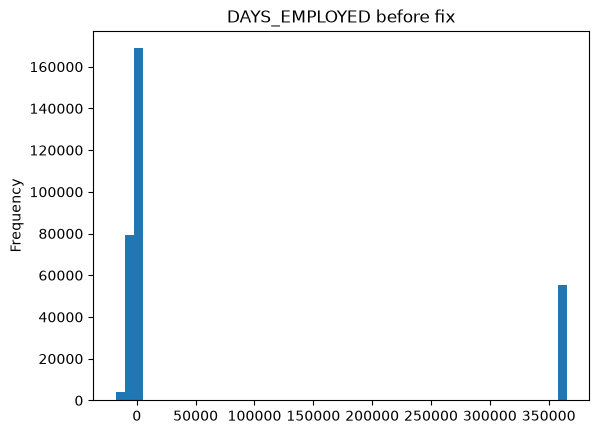

In [23]:
print("DAYS_EMPLOYED anomaly count:", (train['DAYS_EMPLOYED'] == 365243).sum())
print("As % of rows:", round((train['DAYS_EMPLOYED'] == 365243).mean()*100, 2))

# Before fixing, distribution is bimodal/broken:
train['DAYS_EMPLOYED'].plot(kind='hist', bins=50, title='DAYS_EMPLOYED before fix')

DAYS_EMPLOYED is supposed to tell you how many days ago someone started their current job. But Home Credit uses a strange trick: for people who aren't currently employed, instead of leaving this blank, they put in the number 365243 - which works out to roughly 1,000 years. That's obviously not a real answer, it's just a placeholder meaning "not applicable."

This code checks how big of a problem that placeholder actually is in your data:

- It counts exactly how many rows have that fake 365243 value.
- It turns that count into a percentage, so you know how much of your dataset is affected (a few rows would barely matter, but if it's a big chunk, it needs fixing).
- It draws a histogram (a bar chart showing how values are spread out) of DAYS_EMPLOYED as-is. 

Since real values are all fairly small numbers (days someone has worked, so ranging maybe from 0 up to a few thousand) and the fake value is enormous by comparison (365,243), the chart ends up looking broken - as shown  a normal-looking cluster of real values, plus a weird separate spike way off to the side for everyone with the placeholder.

-  That visual is the "before" picture, so later (when the column is fixed  by replacing 365243 with a proper blank value) you can compare it to an "after" picture and see the difference clearly.

### 5. Separating Numerical and Categorical Columns

In [24]:
# Get the list of all columns that hold numbers 
numeric_cols = train.select_dtypes(include=[np.number]).columns

# For every numeric column, check each value: is it infinity (inf or -inf)?
# Then count how many infinite values each column has
inf_counts = np.isinf(train[numeric_cols]).sum()

# Keep only the columns that actually have at least 1 infinite value
inf_cols = inf_counts[inf_counts > 0]

print("Columns with infinite values:")
print(inf_cols)

Columns with infinite values:
Series([], dtype: int64)


In [25]:
# Identifying categorical columns

# or, if pandas 3.0 read them in as the newer string dtype:
# Newer versions of pandas sometimes store text as a "string" dtype instead
# of the older "object" dtype, so this line catches both possibilities —
# whichever one your version of pandas actually used
categorical_cols = train.select_dtypes(include=['object', 'string']).columns

# Show how many numeric columns we found earlier, and how many text columns we just found
print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

# List out the actual names of the text columns, so we can see exactly which ones they are
print(categorical_cols.tolist())

Numeric columns: 552
Categorical columns: 16
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


### 6. Outliers Analysis

In a boxplot :

1. The line inside the box represents the median (the middle value).
2. The box represents the middle 50% of the data (from the 25th to the 75th percentile).
3. The whiskers show the range of most normal observations.
4. The small circles (dots) outside the whiskers are outliers-values that are much higher or lower than most observations.

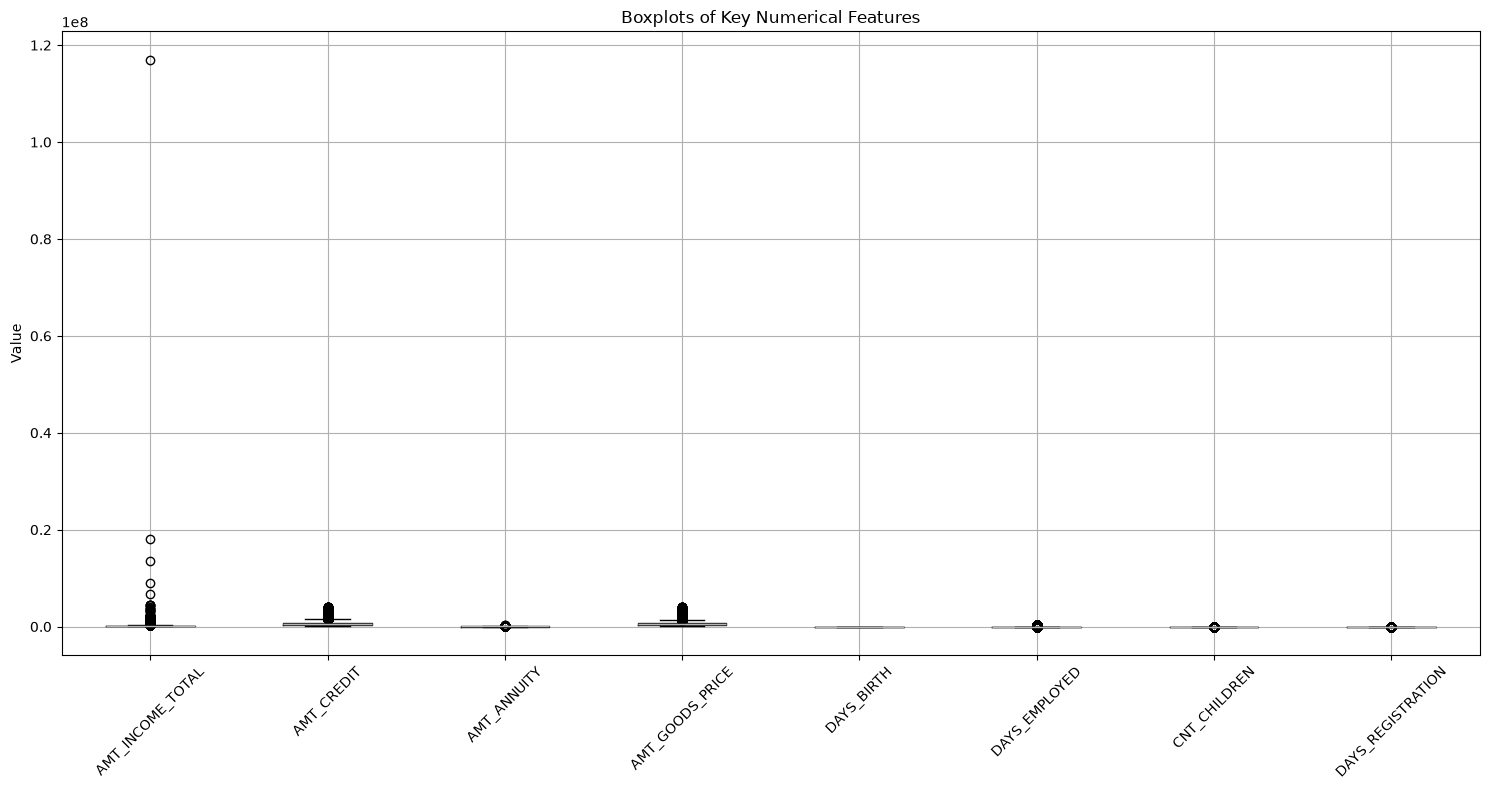

In [26]:
import matplotlib.pyplot as plt
key_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 
            'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'DAYS_REGISTRATION']
key_cols = [c for c in key_cols if c in train.columns]

plt.figure(figsize=(15, 8))
train[key_cols].boxplot(rot=45)
plt.title("Boxplots of Key Numerical Features")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

Skip visual boxplots for 500 columns and compute outlier counts numerically instead 

The  code below identifies potential outliers in the numerical features of the training dataset using the Interquartile Range (IQR) method. For each numerical column, it calculates the lower and upper limits for normal values, counts how many observations fall outside these limits, and calculates the percentage of outliers. The results are sorted from the highest to the lowest percentage of outliers, helping identify variables with unusually extreme values that may need further investigation or preprocessing before training a machine learning model.

In [27]:
def outlier_summary(df, cols):
    results = []
    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        if n_outliers > 0:
            results.append({'column': col, 'n_outliers': n_outliers, 
                             'pct_outliers': round(n_outliers/len(df)*100, 2)})
    return pd.DataFrame(results).sort_values('pct_outliers', ascending=False)

outlier_report = outlier_summary(train, numeric_cols)
outlier_report.head(30)

,column,n_outliers,pct_outliers
464,INSTAL_NUM_INSTALMENT_VERSION_MEAN,88215,28.69
16,REGION_RATING_CLIENT,80527,26.19
17,REGION_RATING_CLIENT_W_CITY,78027,25.37
495,INSTAL_AMT_PAYMENT_DIFF_SUM,72892,23.70
426,PREV_NAME_PRODUCT_TYPE_WALK-IN_MEAN,72663,23.63
7,DAYS_EMPLOYED,72217,23.48
454,PREV_PRODUCT_COMBINATION_CASH X-SELL: MIDDLE_MEAN,71255,23.17
23,REG_CITY_NOT_WORK_CITY,70867,23.05
492,INSTAL_AMT_PAYMENT_DIFF_MEAN,70261,22.85
401,PREV_NAME_GOODS_CATEGORY_COMPUTERS_MEAN,70110,22.80


### 7. Correlation Analysis

A full correlation matrix - all numeric columns against each other with a 500+ numeric columns,  the grid will be 500x500 which is  unreadable as a heatmap and slow to compute. 

Therefore, below are two more practical versions for a dataset this wide:

1. Heatmap of just a manageable subset (e.g. the original raw features):

A correlation matrix shows the strength and direction of the linear relationship between the selected numerical features and the target variable. Correlation values range from -1 to +1, where:

* +1 = Perfect positive relationship (both variables increase together)
* -1 = Perfect negative relationship (one increases while the other decreases)
* 0 = No linear relationship

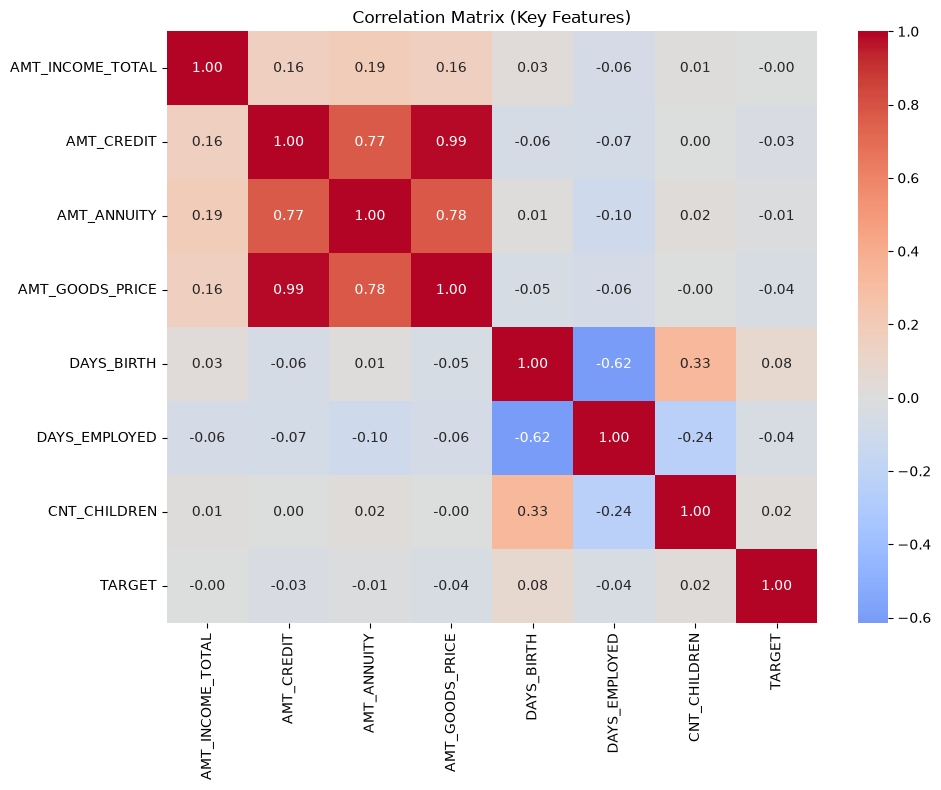

In [28]:
import seaborn as sns

key_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
            'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'TARGET']
key_cols = [c for c in key_cols if c in train.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(train[key_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Key Features)')
plt.tight_layout()
plt.show()

2. Find highly correlated feature pairs across the full set 

In [29]:
corr_matrix = train[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={0: 'correlation', 'level_0': 'feature_1', 'level_1': 'feature_2'})
    .query('correlation > 0.9')
    .sort_values('correlation', ascending=False)
)
print(f"Found {len(high_corr_pairs)} feature pairs with correlation > 0.9")
high_corr_pairs.head(30)

Found 225 feature pairs with correlation > 0.9


,feature_1,feature_2,correlation
208482,PREV_FLAG_LAST_APPL_PER_CONTRACT_N_MEAN,PREV_FLAG_LAST_APPL_PER_CONTRACT_Y_MEAN,1.000000
225076,PREV_NAME_CONTRACT_STATUS_UNUSED OFFER_MEAN,PREV_CODE_REJECT_REASON_CLIENT_MEAN,1.000000
206298,PREV_NAME_CONTRACT_TYPE_CASH LOANS_MEAN,PREV_NAME_CASH_LOAN_PURPOSE_XAP_MEAN,1.000000
149313,CC_AMT_RECIVABLE_MEAN,CC_AMT_TOTAL_RECEIVABLE_MEAN,0.999999
149866,CC_AMT_RECIVABLE_MAX,CC_AMT_TOTAL_RECEIVABLE_MAX,0.999998
150419,CC_AMT_RECIVABLE_SUM,CC_AMT_TOTAL_RECEIVABLE_SUM,0.999987
171442,PREV_AMT_APPLICATION_MAX,PREV_AMT_GOODS_PRICE_MAX,0.999964
132750,CC_AMT_BALANCE_MEAN,CC_AMT_RECIVABLE_MEAN,0.999960
132753,CC_AMT_BALANCE_MEAN,CC_AMT_TOTAL_RECEIVABLE_MEAN,0.999955
286459,INSTAL_DAYS_INSTALMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_SUM,0.999954


In [30]:
corrs = train[numeric_cols].corrwith(train['TARGET']).drop('TARGET').sort_values()

print("Top 15 negative correlations (protective):")
print(corrs.head(15))
print()
print("Top 15 positive correlations (risk factors):")
print(corrs.tail(15))

c:\Users\User\Desktop\final project\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\User\Desktop\final project\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Top 15 negative correlations (protective):
EXT_SOURCE_3                              -0.178919
EXT_SOURCE_2                              -0.160472
EXT_SOURCE_1                              -0.155317
BUREAU_BB_MONTHS_COUNT_MEAN               -0.080193
BUREAU_CREDIT_ACTIVE_CLOSED_MEAN          -0.079369
PREV_CODE_REJECT_REASON_XAP_MEAN          -0.073930
BUREAU_BB_MONTHS_COUNT_MAX                -0.068792
PREV_NAME_CONTRACT_STATUS_APPROVED_MEAN   -0.063521
BUREAU_BB_STATUS_C_MEAN                   -0.062954
BUREAU_BB_STATUS_C_MAX                    -0.061083
INSTAL_DAYS_INSTALMENT_STD                -0.058885
INSTAL_DAYS_ENTRY_PAYMENT_STD             -0.058419
BUREAU_BB_MONTHS_COUNT_MIN                -0.048224
INSTAL_AMT_PAYMENT_RATIO_MIN              -0.045650
CC_AMT_CREDIT_LIMIT_ACTUAL_SUM            -0.045460
dtype: float64

Top 15 positive correlations (risk factors):
PREV_NAME_CONTRACT_STATUS_REFUSED_MEAN              0.077671
DAYS_BIRTH                                          0.0

### 8. Numerical columns Distribution

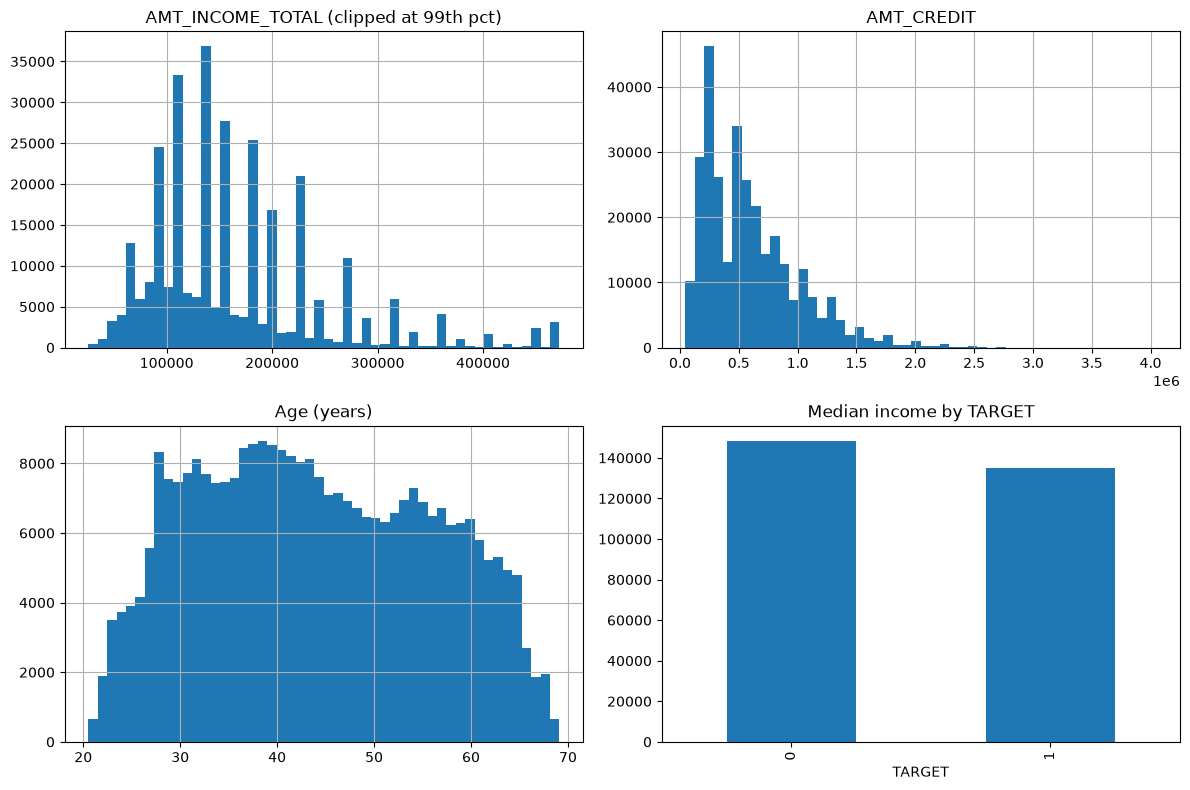

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
(train['AMT_INCOME_TOTAL']).clip(upper=train['AMT_INCOME_TOTAL'].quantile(0.99)).hist(ax=axes[0,0], bins=50)
axes[0,0].set_title('AMT_INCOME_TOTAL (clipped at 99th pct)')

train['AMT_CREDIT'].hist(ax=axes[0,1], bins=50)
axes[0,1].set_title('AMT_CREDIT')

(-train['DAYS_BIRTH']/365).hist(ax=axes[1,0], bins=50)
axes[1,0].set_title('Age (years)')

train.groupby('TARGET')['AMT_INCOME_TOTAL'].median().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Median income by TARGET')
plt.tight_layout()
plt.show()

1. In the AMT_INCOME_TOTAL visualization

The histogram shows the distribution of customers' annual income. The data has been clipped at the 99th percentile, meaning the top 1% of extremely high incomes were excluded from the plot to make the distribution easier to see.

**Therefore,**
1. Most customers earn between 100,000 and 250,000.
2. The distribution is right-skewed, meaning there are many customers with moderate incomes and fewer customers with very high incomes.
3. Even after clipping, a small number of customers still have relatively high incomes.

*Conclusion:*
Most loan applicants have moderate incomes, while only a small proportion earn substantially higher incomes.

2. In the AMT_CREDIT Visualization

The histogram shows the distribution of loan amounts requested.

**Interpretation**
1. Most customers applied for small to medium-sized loans.
2. The distribution is also right-skewed, with fewer customers requesting very large loans.
3. A small number of applicants requested loans exceeding 2 million, creating a long right tail.

*Conclusion:*
The majority of applicants borrow relatively modest amounts, while only a few apply for very large loans.

3. In the Age Visualization

The histogram shows the distribution of applicants' ages.

**Interpretation**
1. Most applicants are between 30 and 60 years old.
2. There are relatively few applicants younger than 25 or older than 65.
3. The distribution is fairly balanced without extreme spikes.

*Conclusion:*
The customer base mainly consists of middle-aged adults, with fewer very young or elderly applicants.

4. In the Median Income by TARGET Visualization

This bar chart compares the median annual income of customers based on the target variable.

TARGET = 0 → Customer repaid the loan successfully.

TARGET = 1 → Customer defaulted on the loan.

**Interpretation**
* Customers who did not default (TARGET = 0) have a higher median income than customers who defaulted.
* Customers who defaulted (TARGET = 1) have a slightly lower median income.

Although the difference is not very large, it suggests that income may have some influence on repayment ability.



Batching through all numeric columns in chunks, e.g. 20 at a time

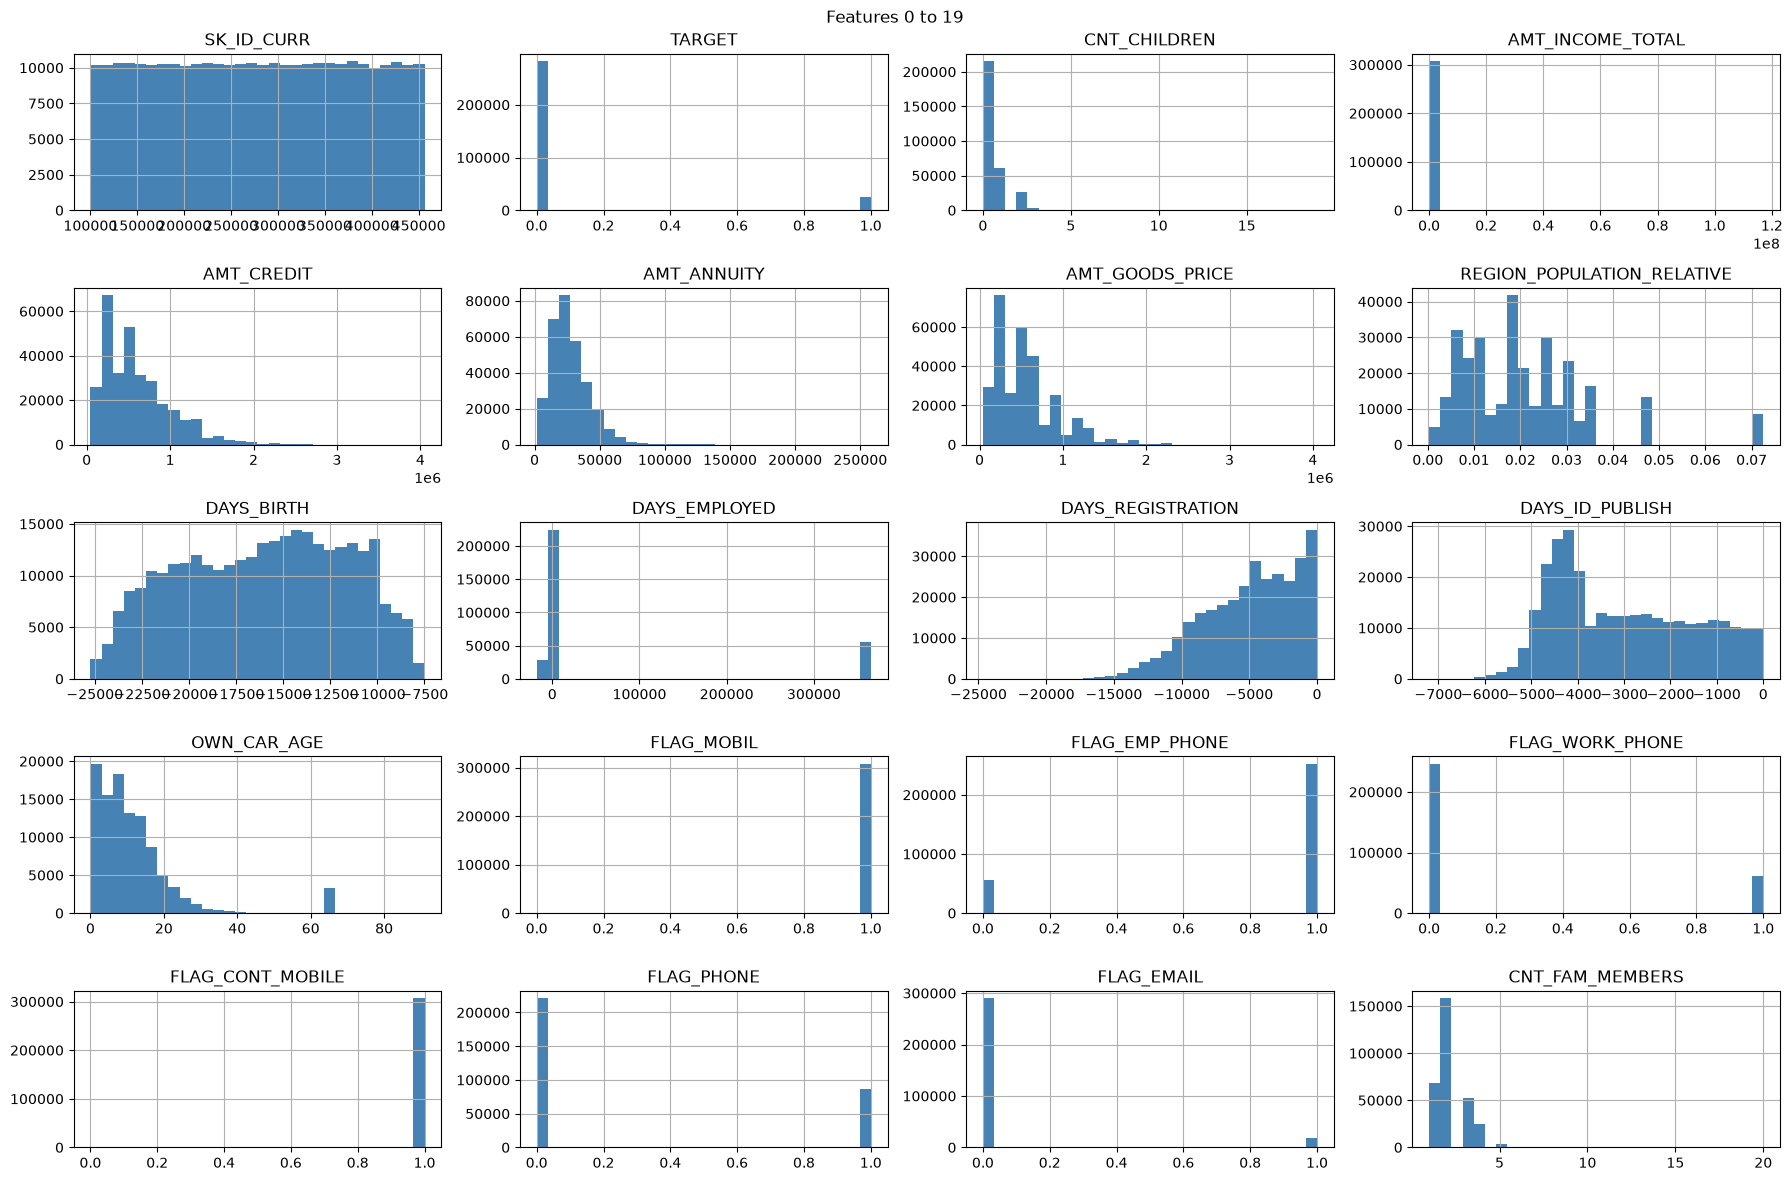

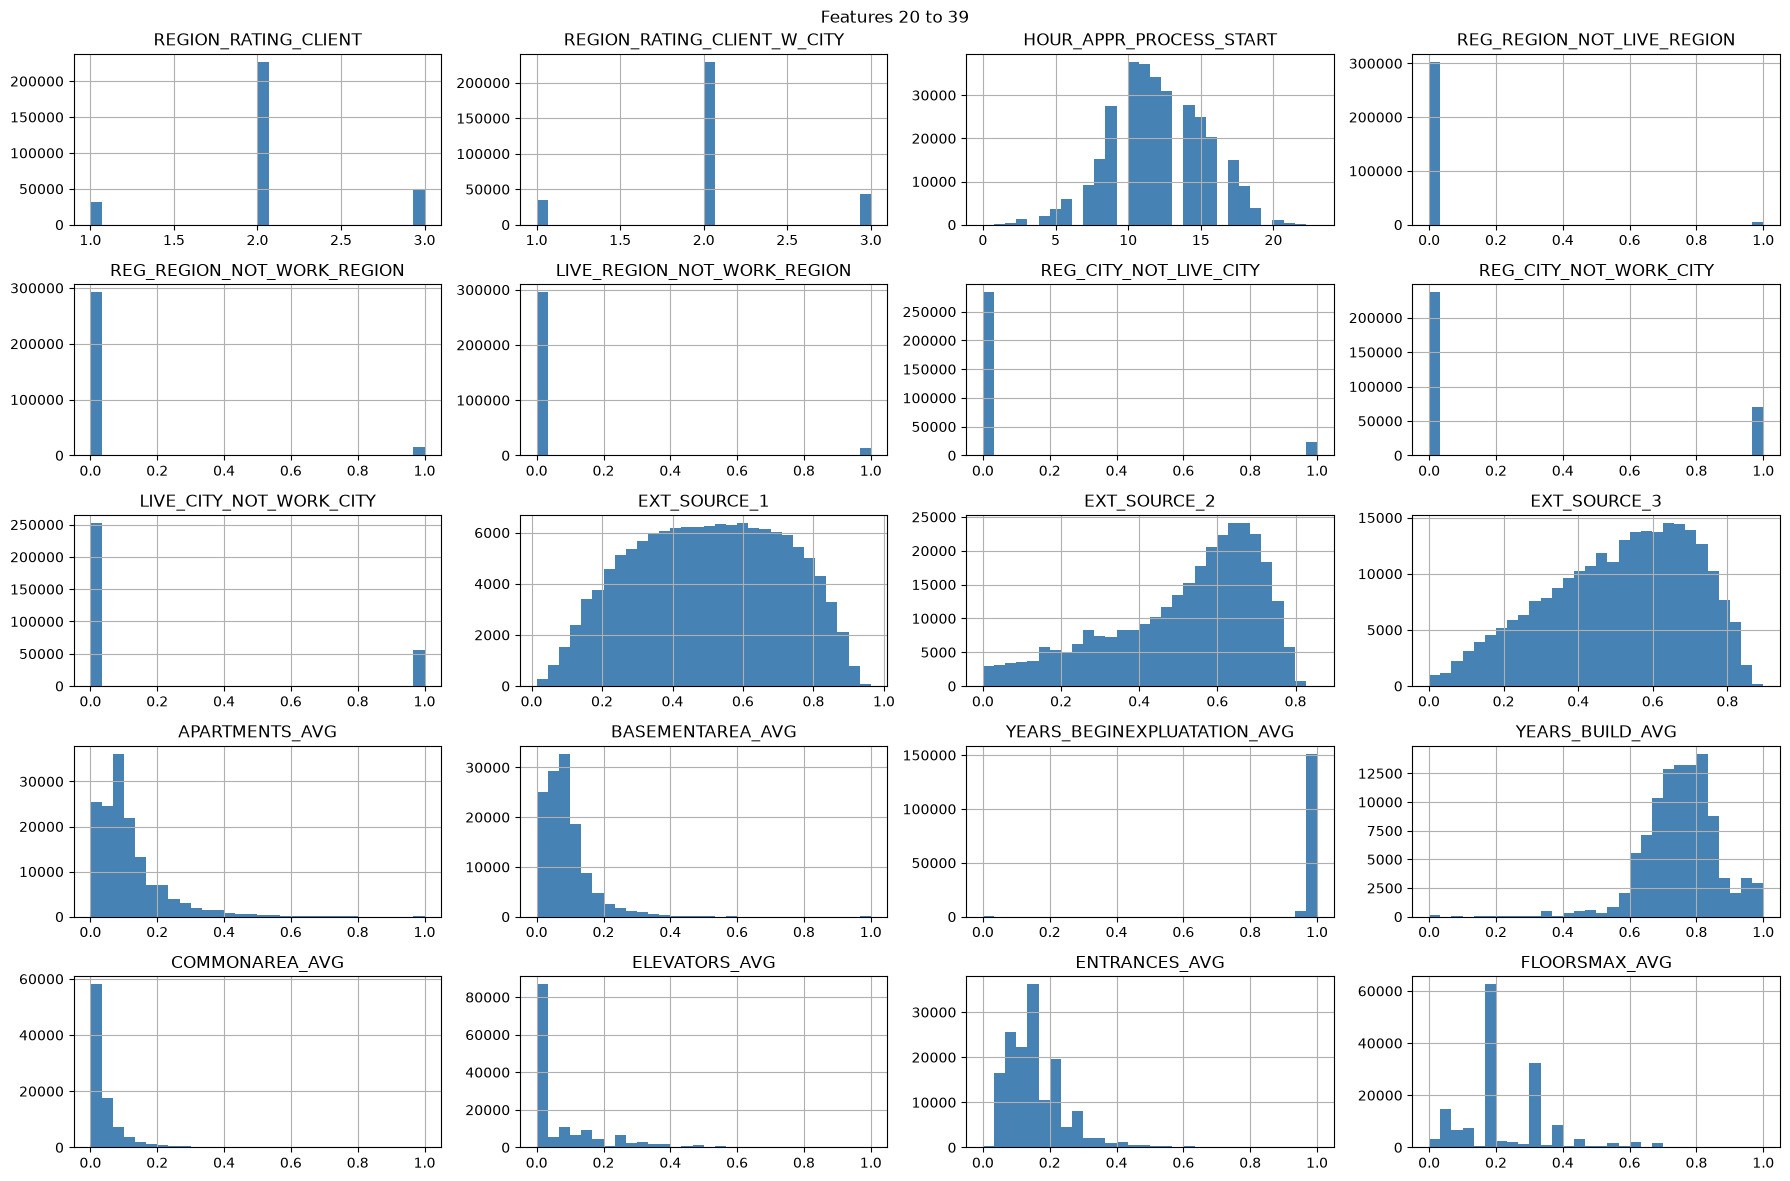

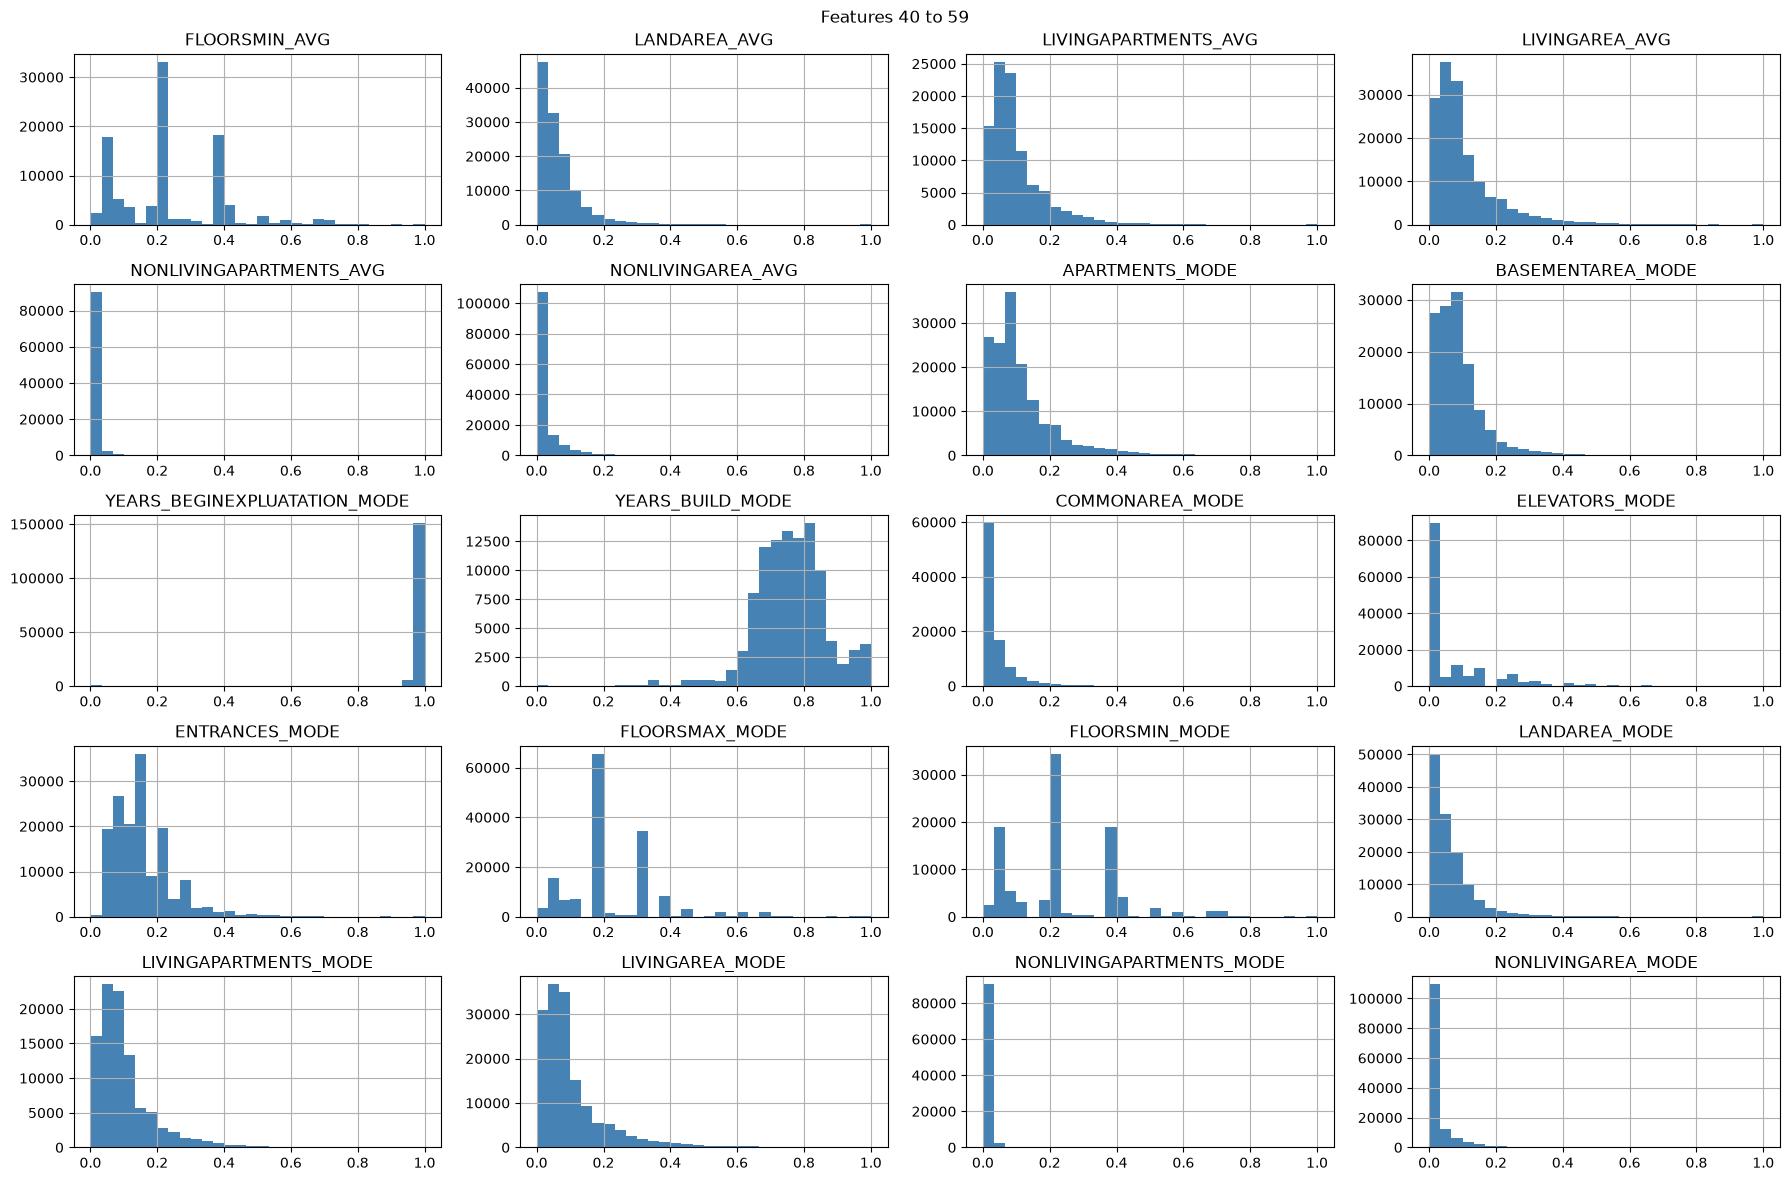

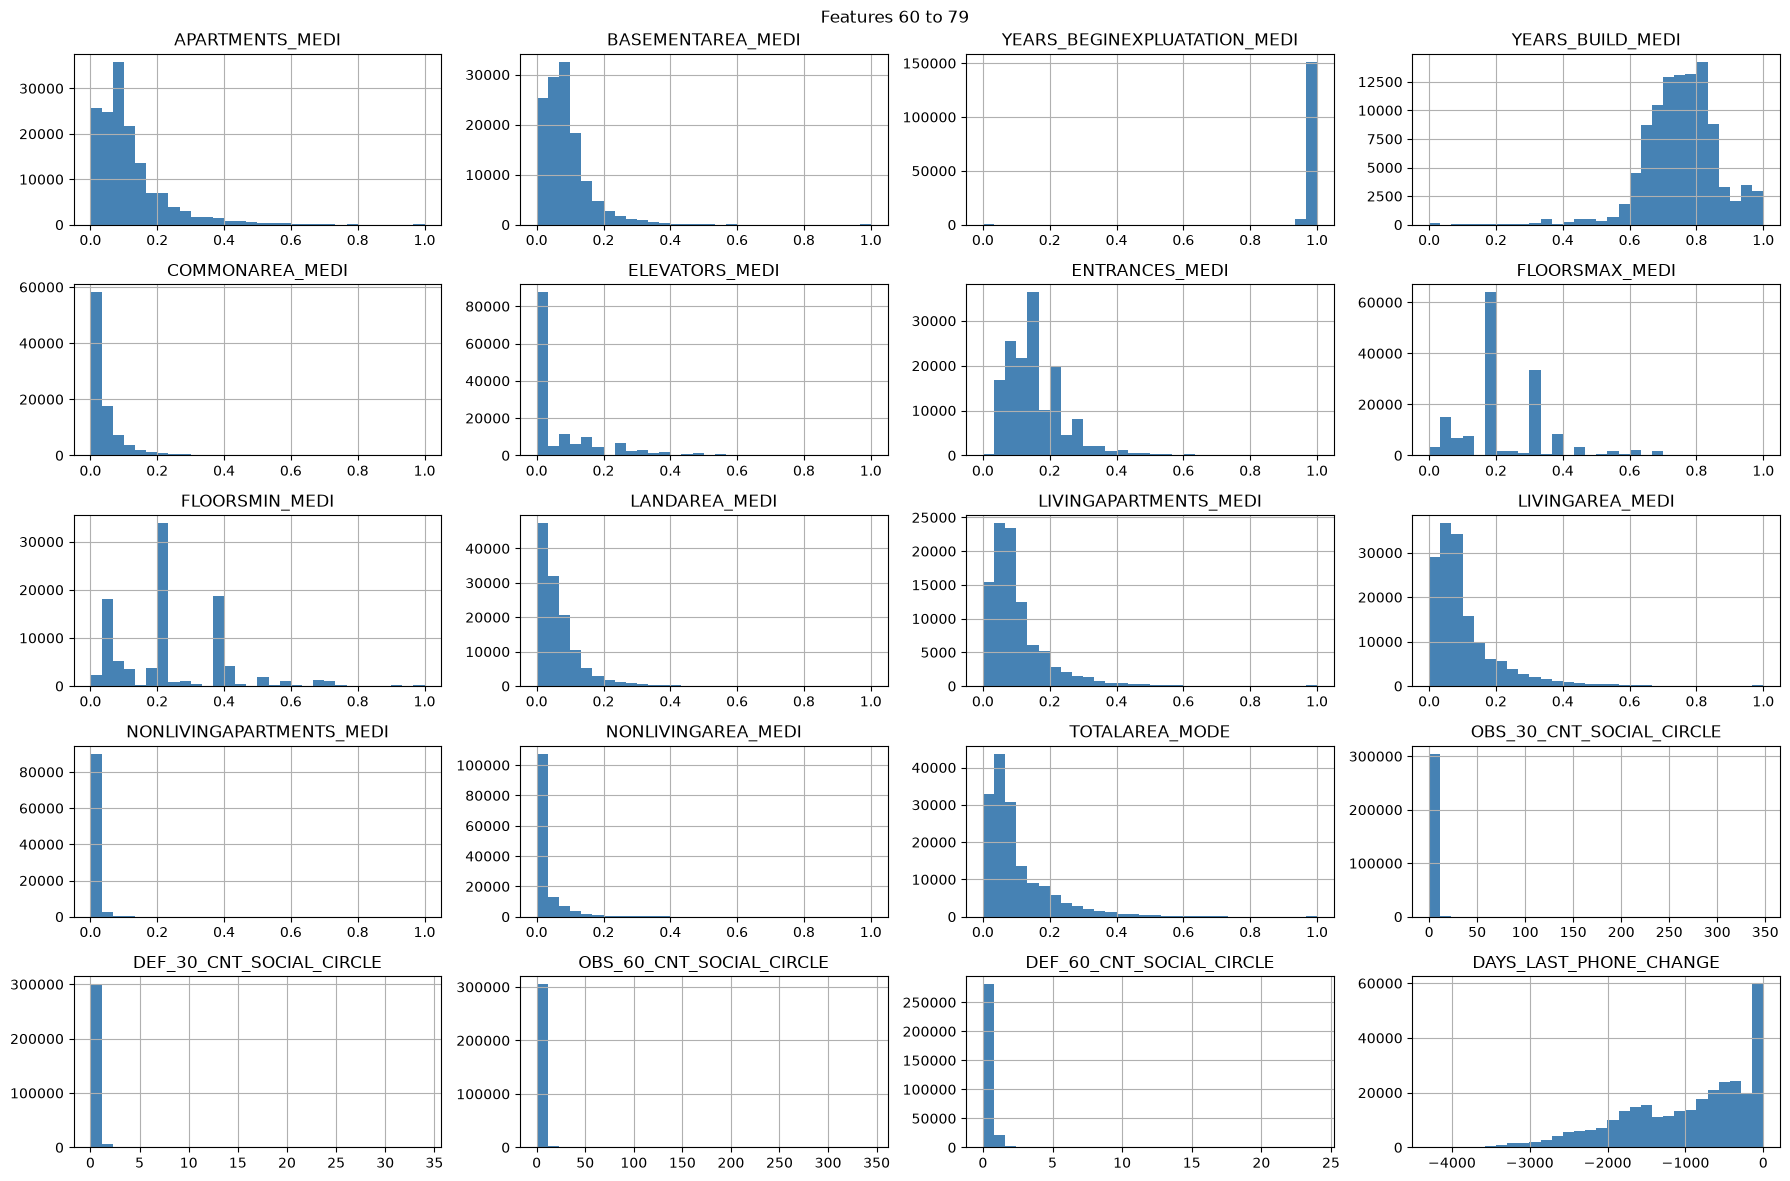

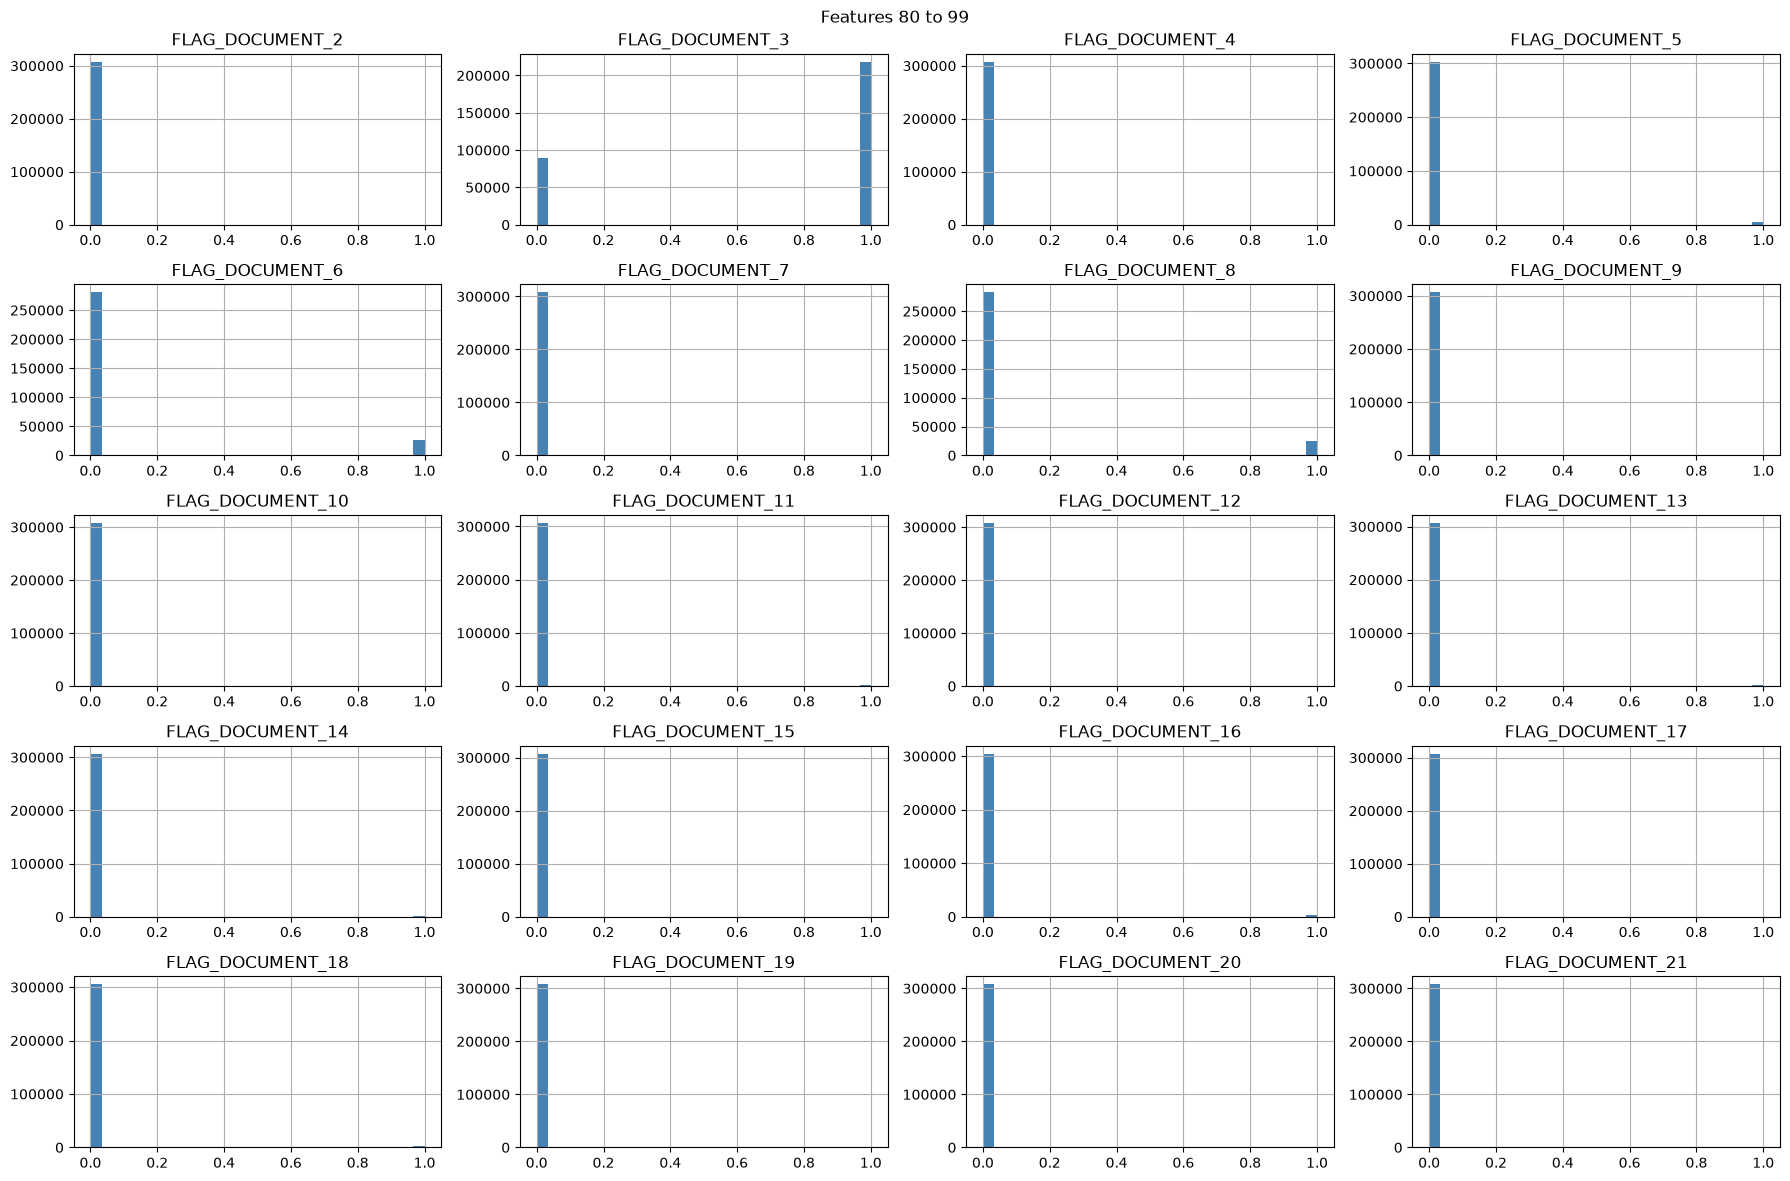

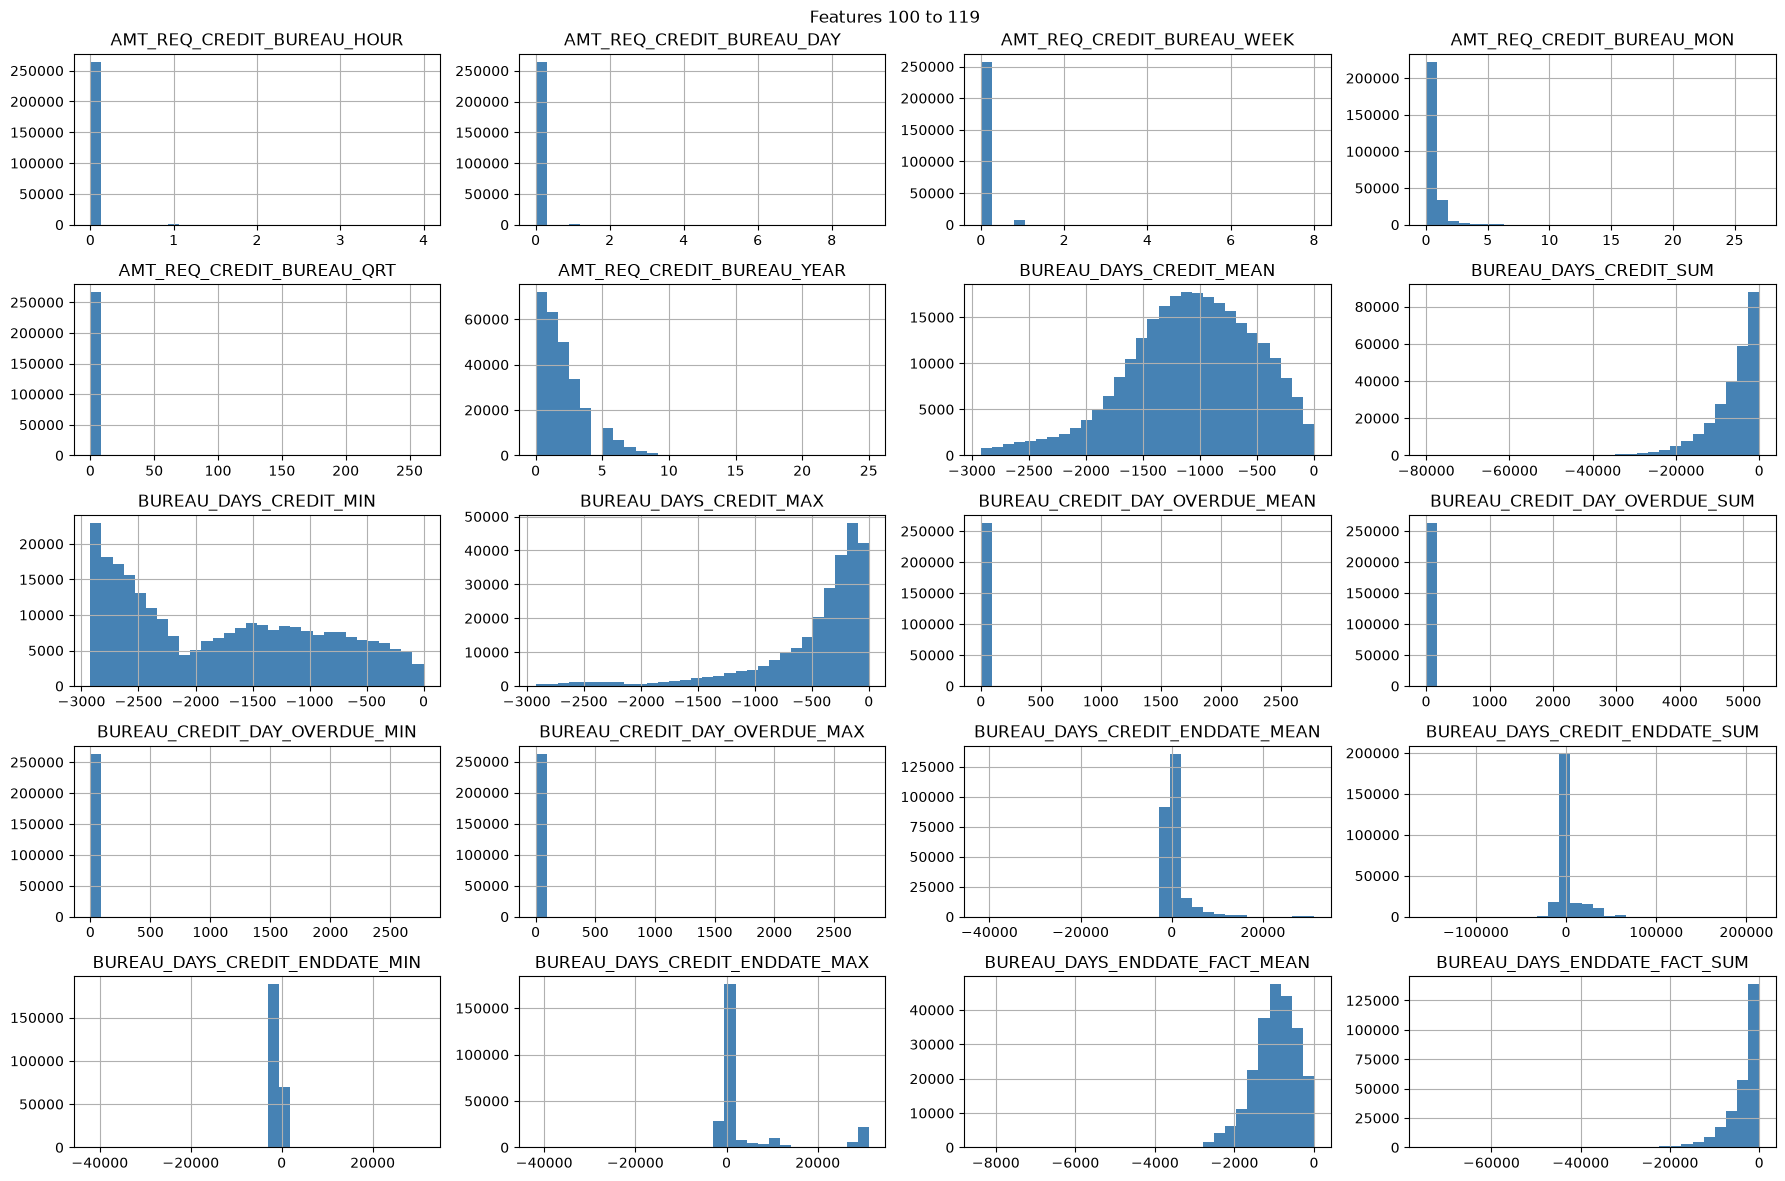

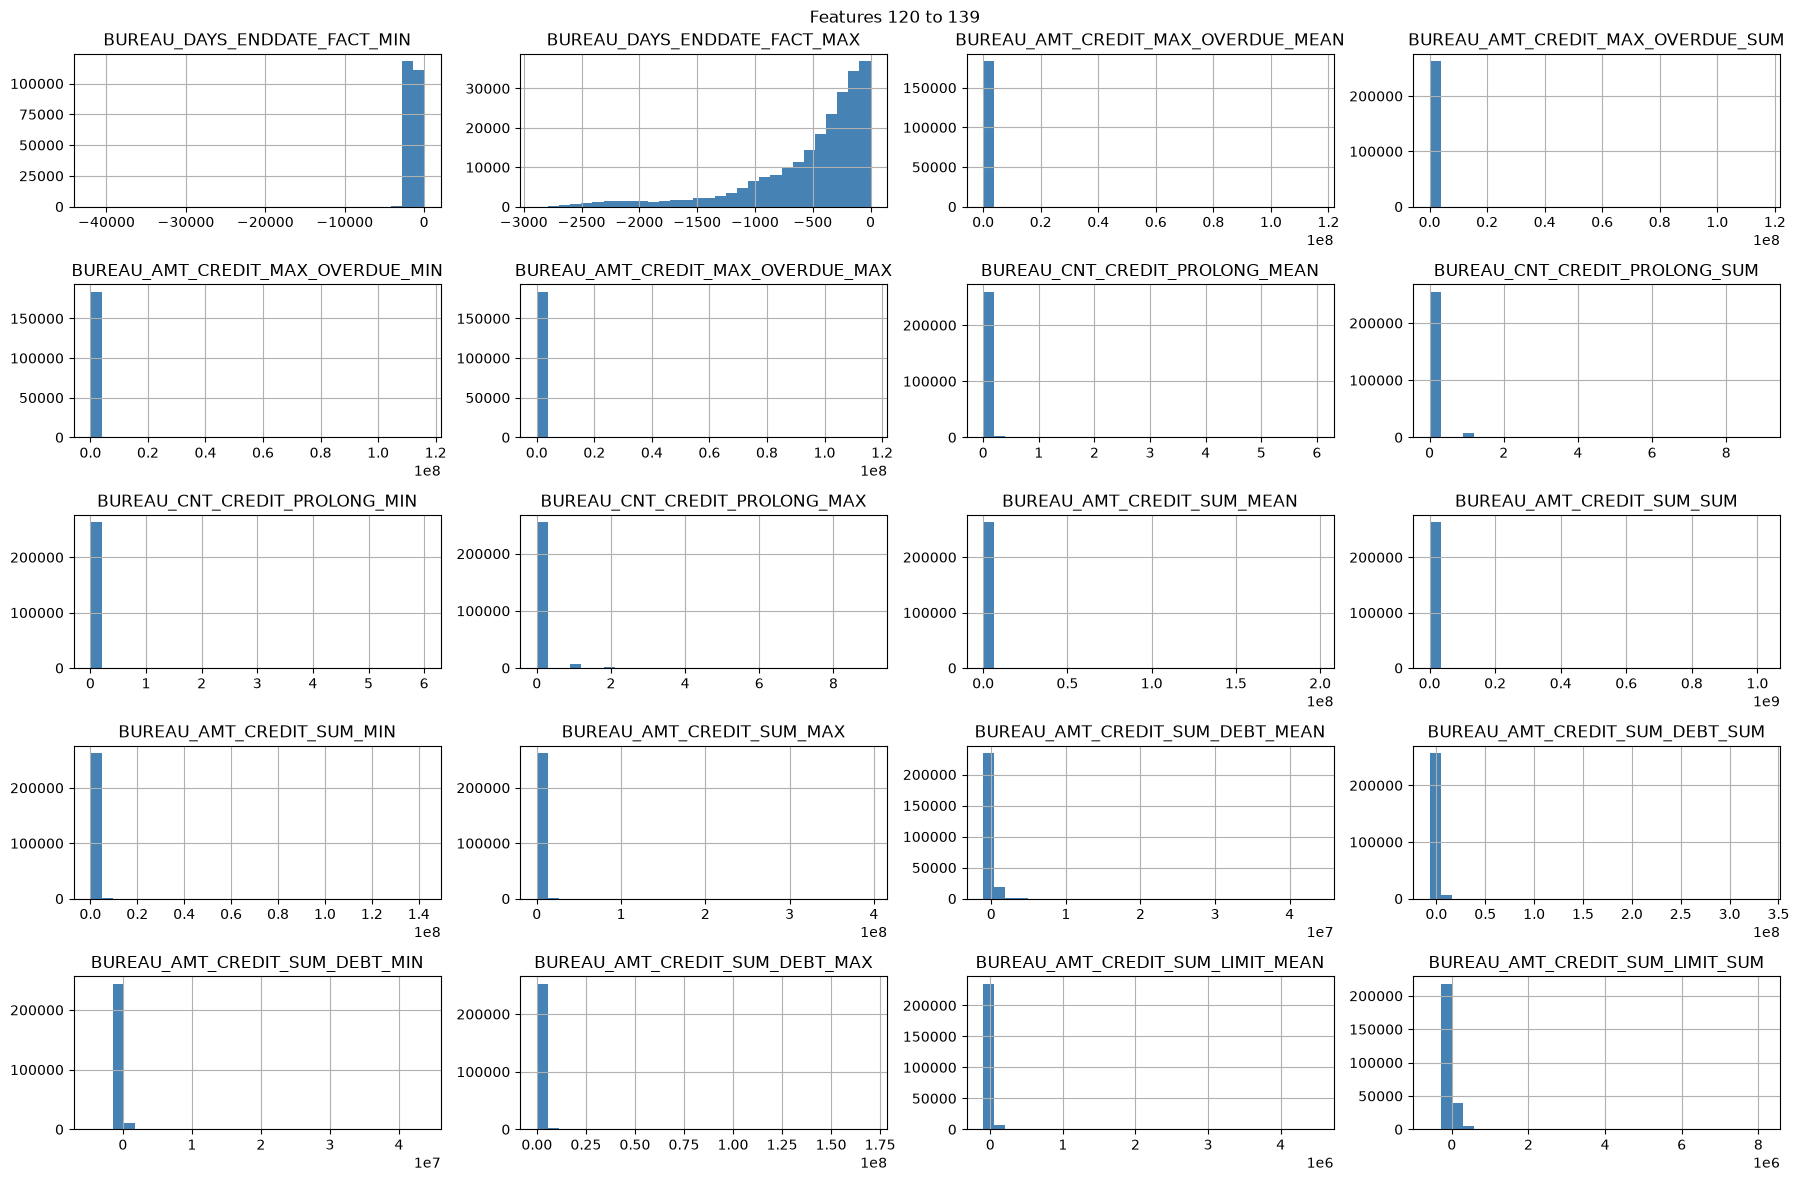

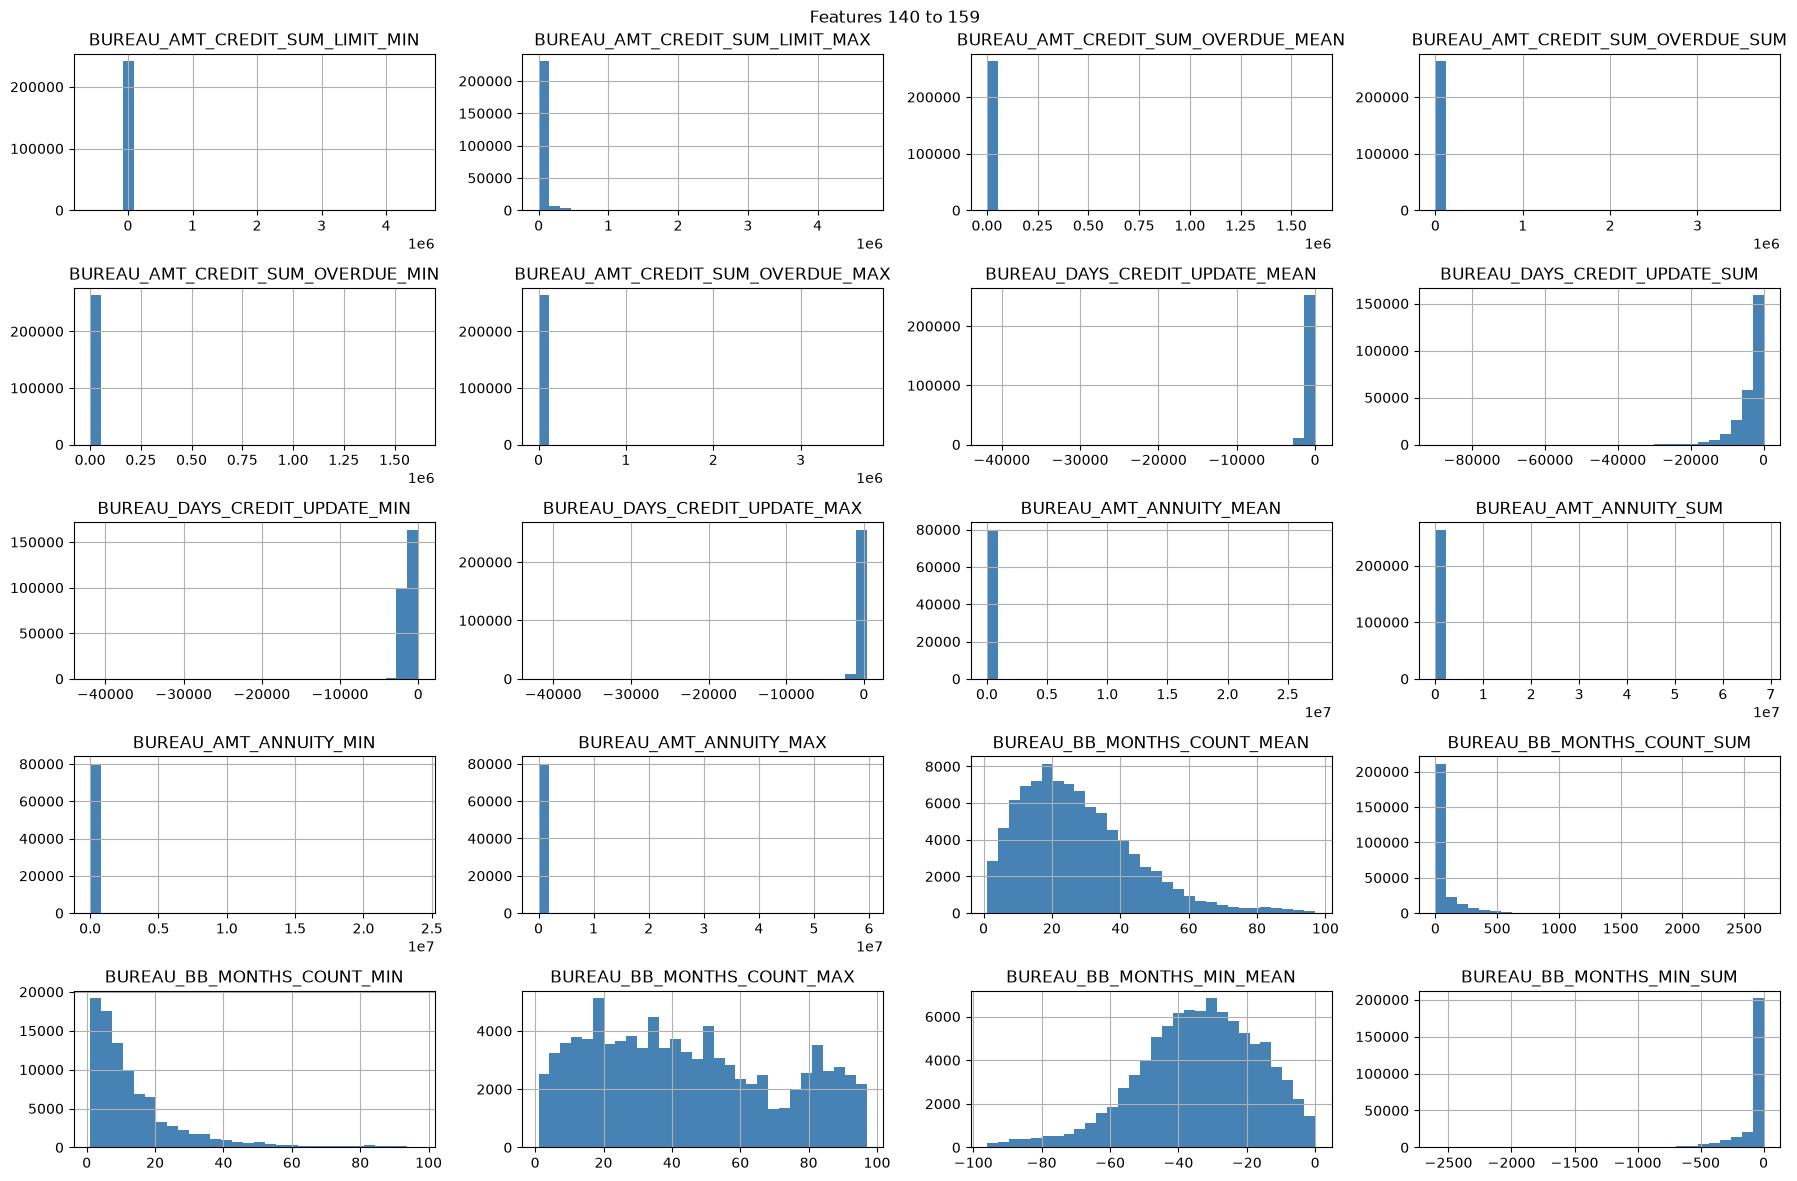

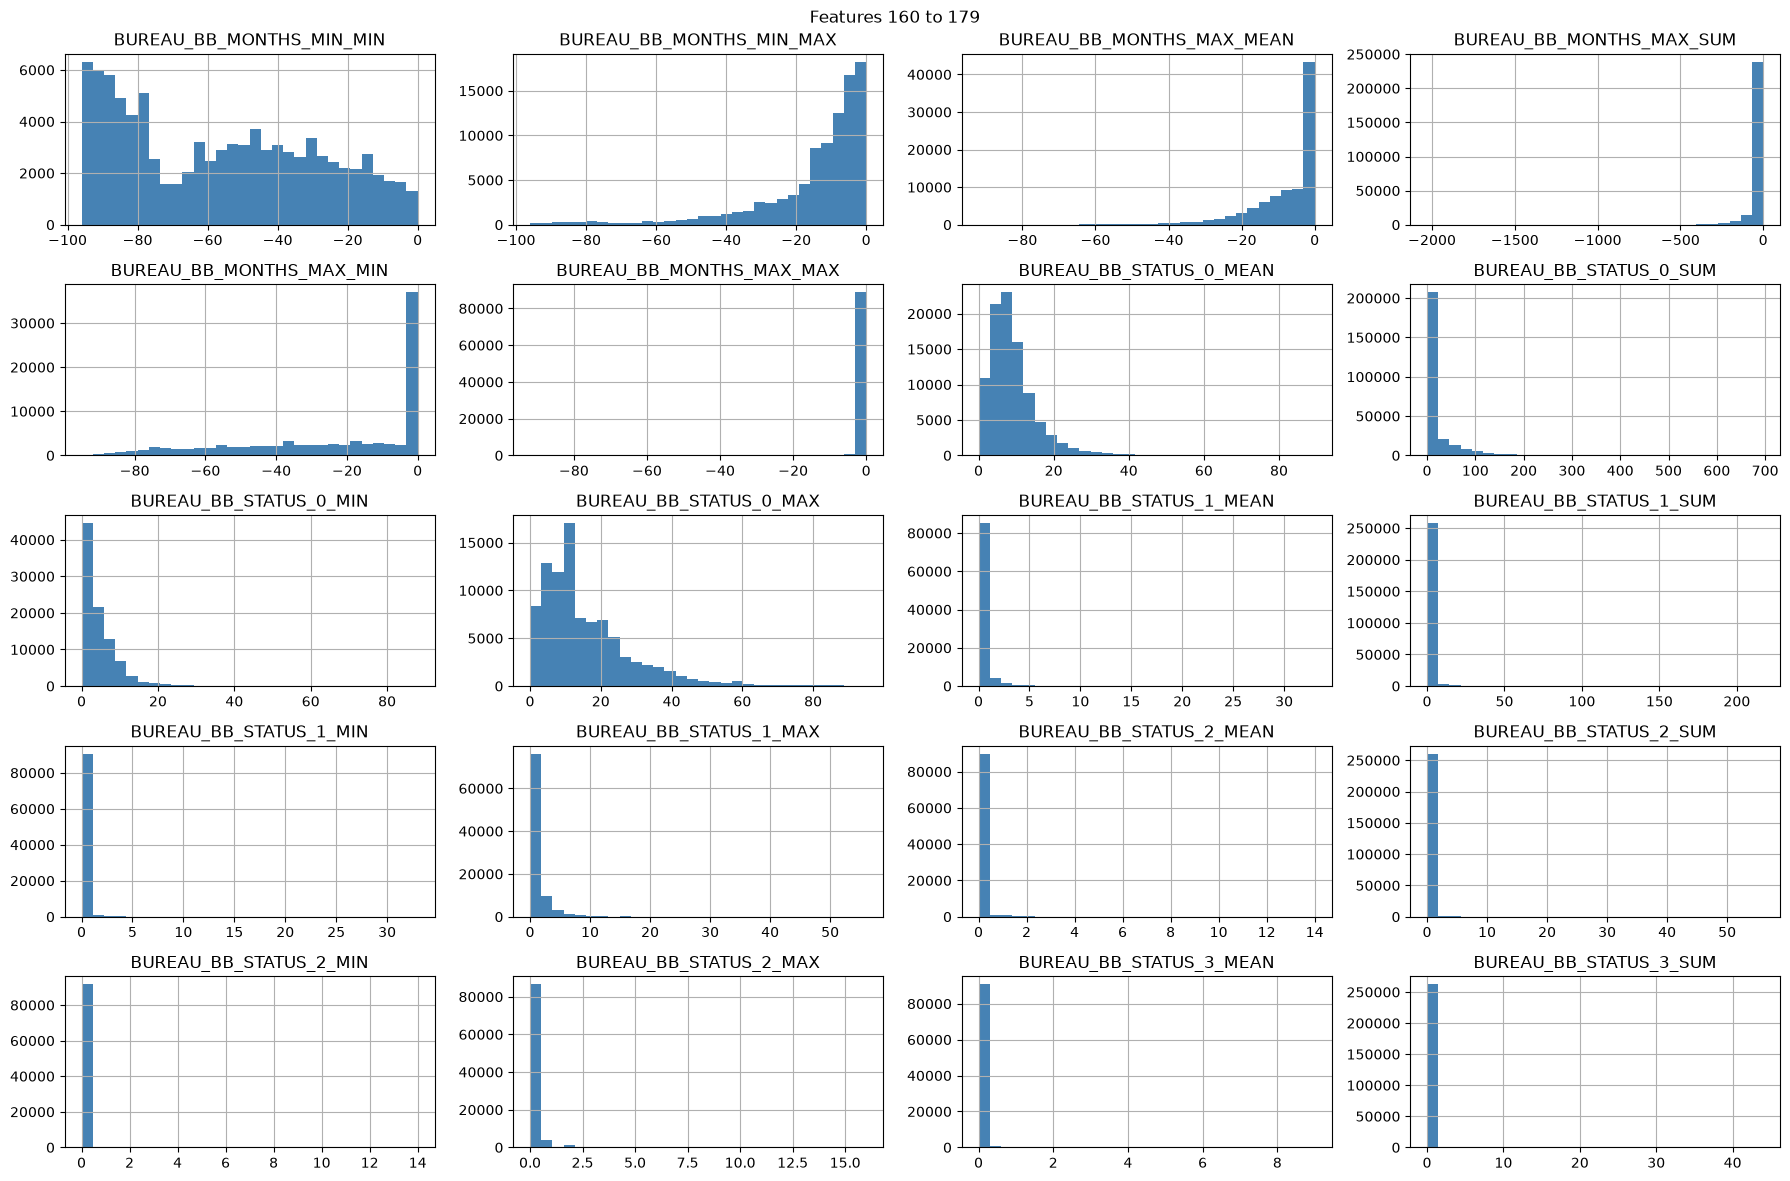

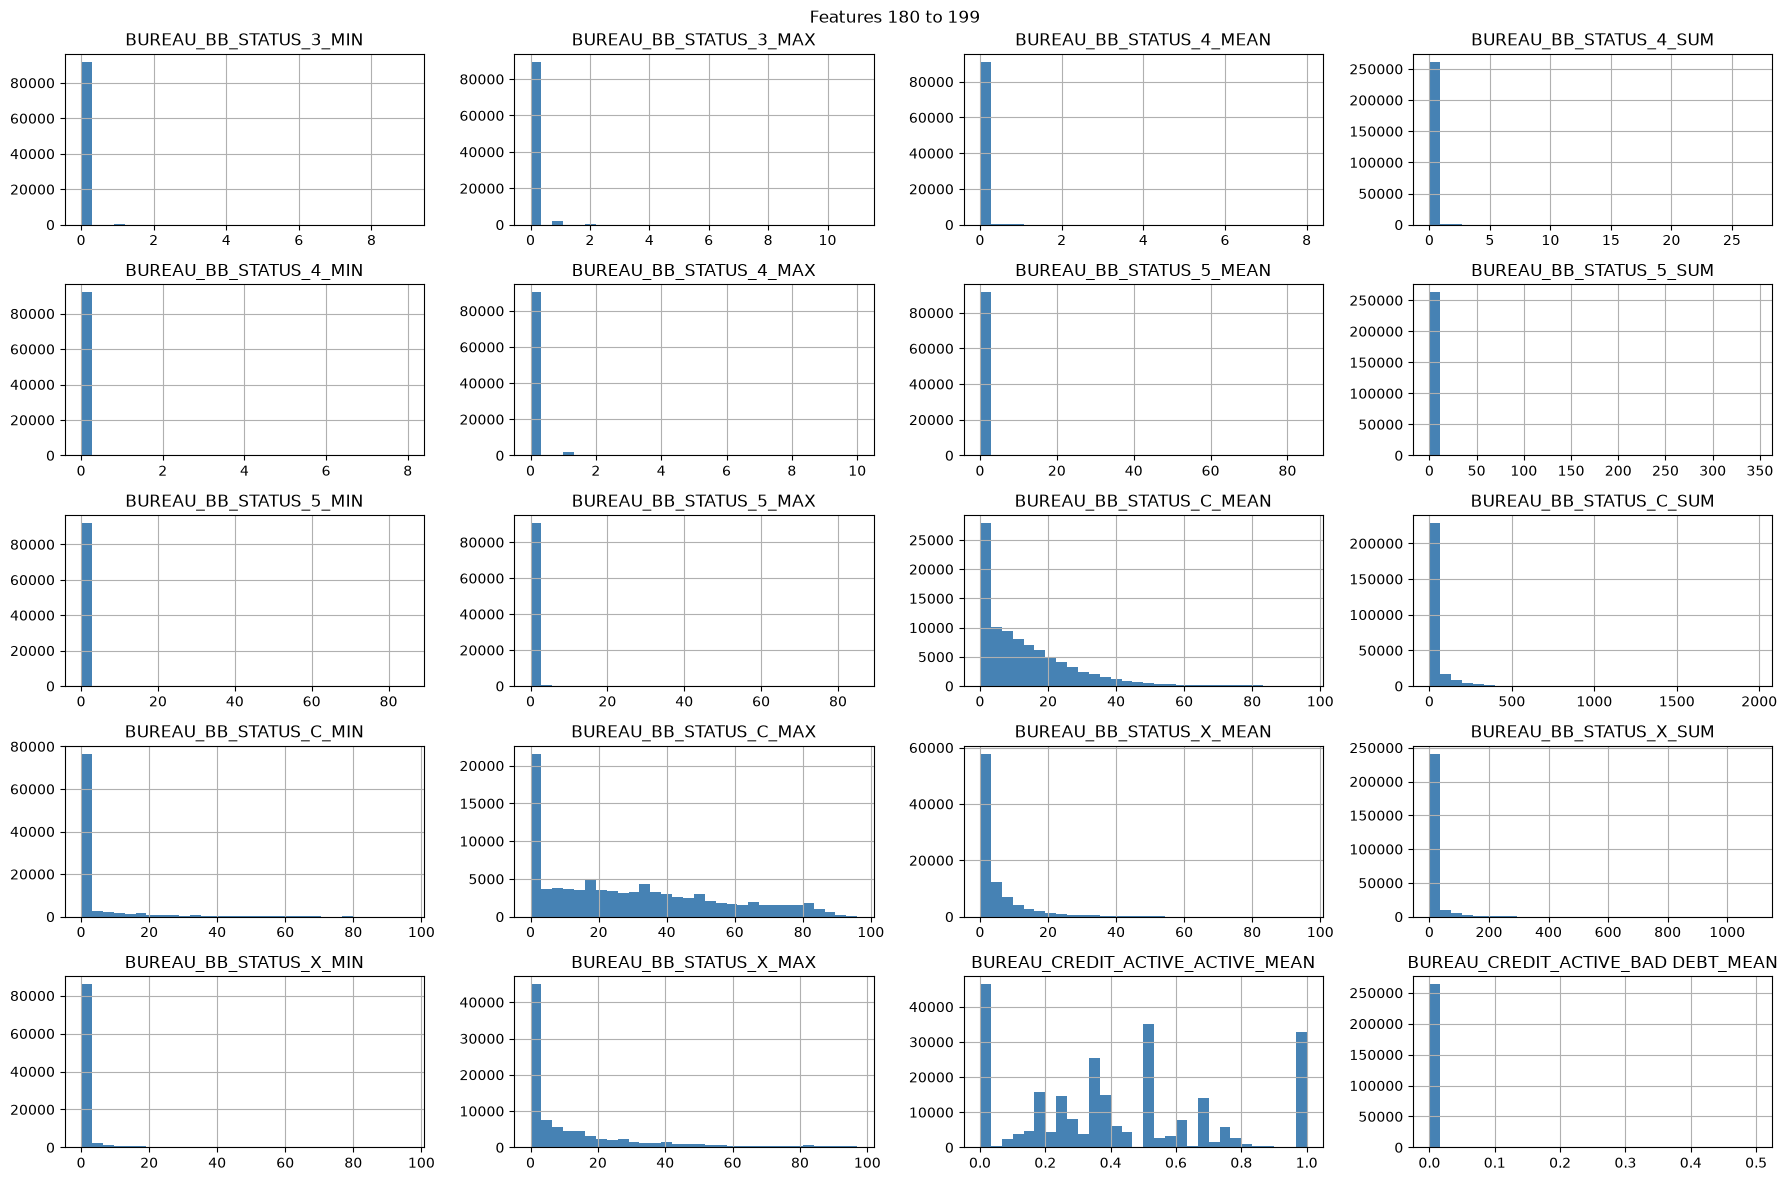

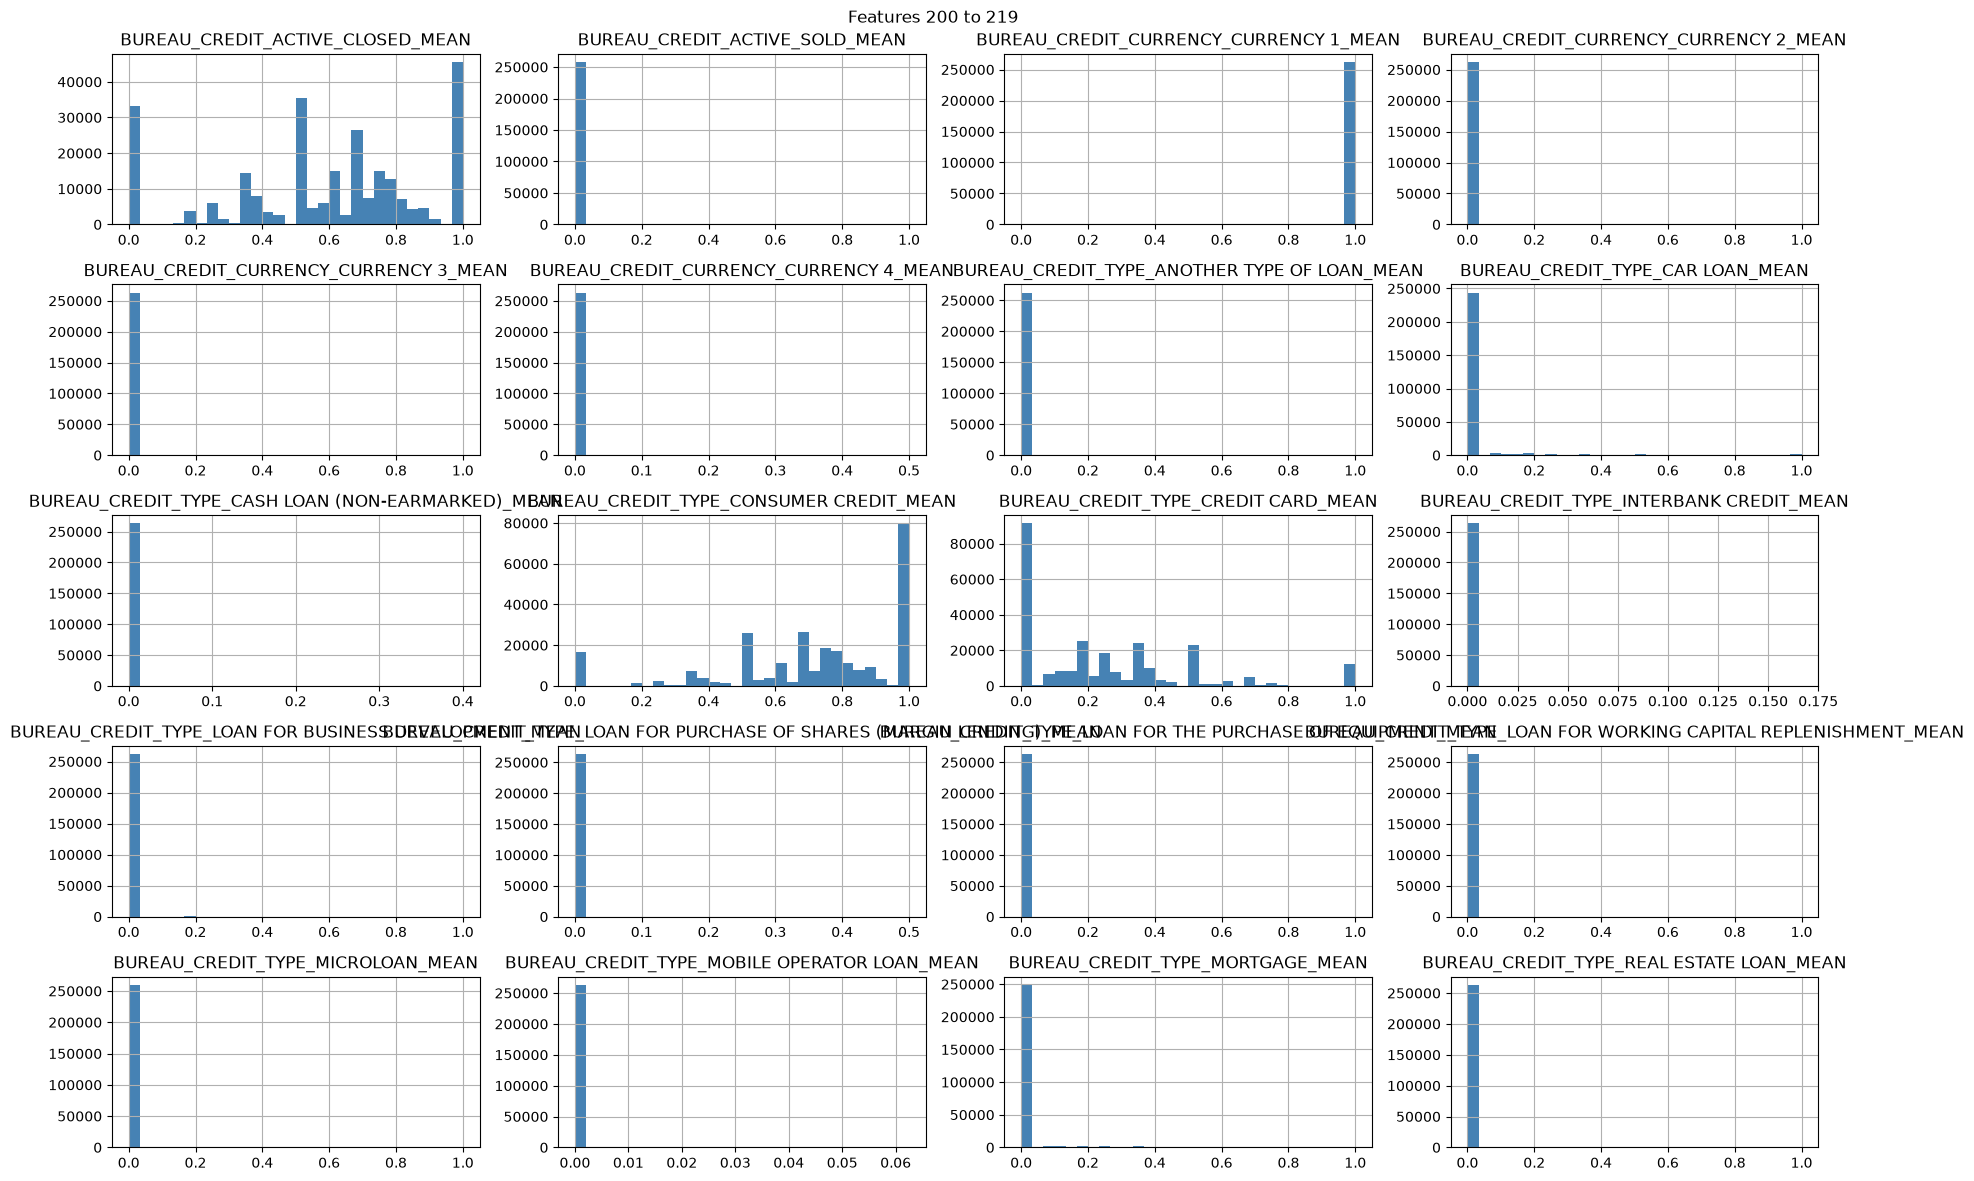

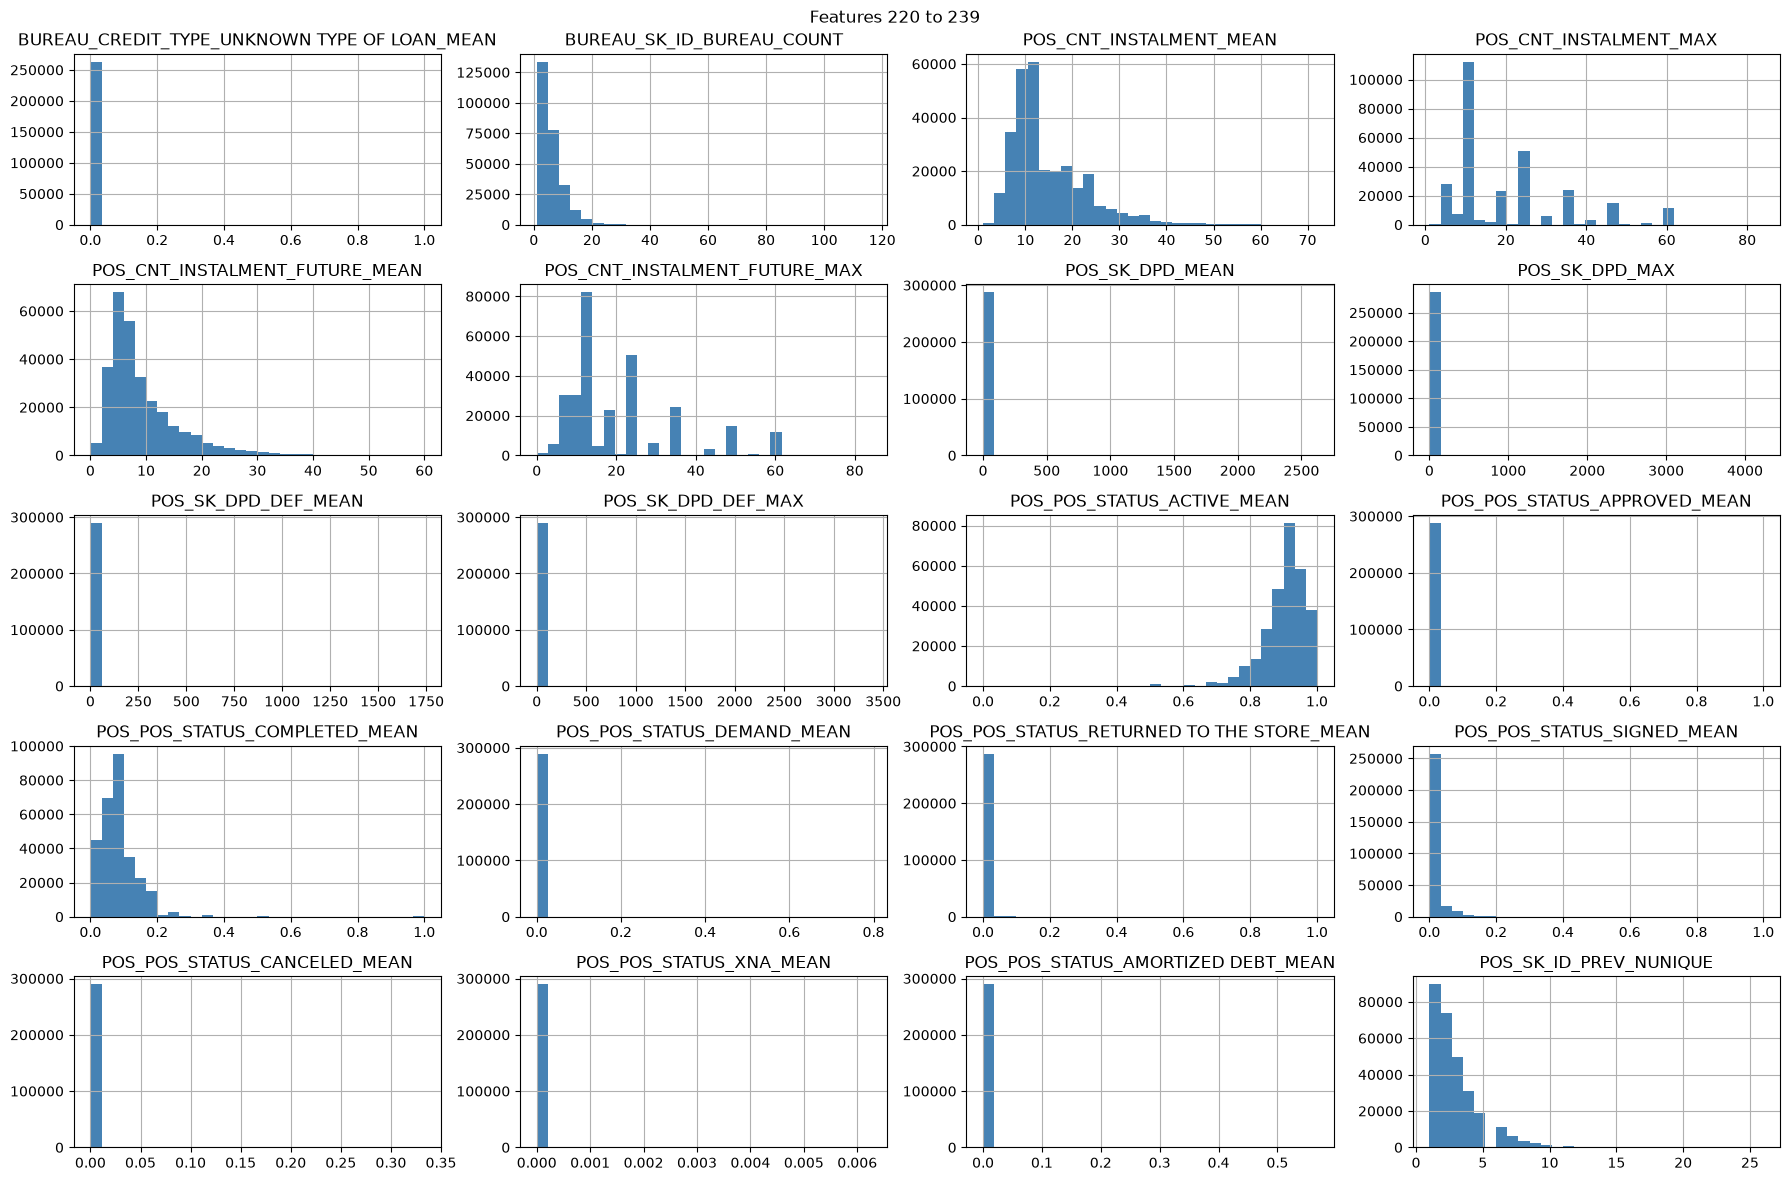

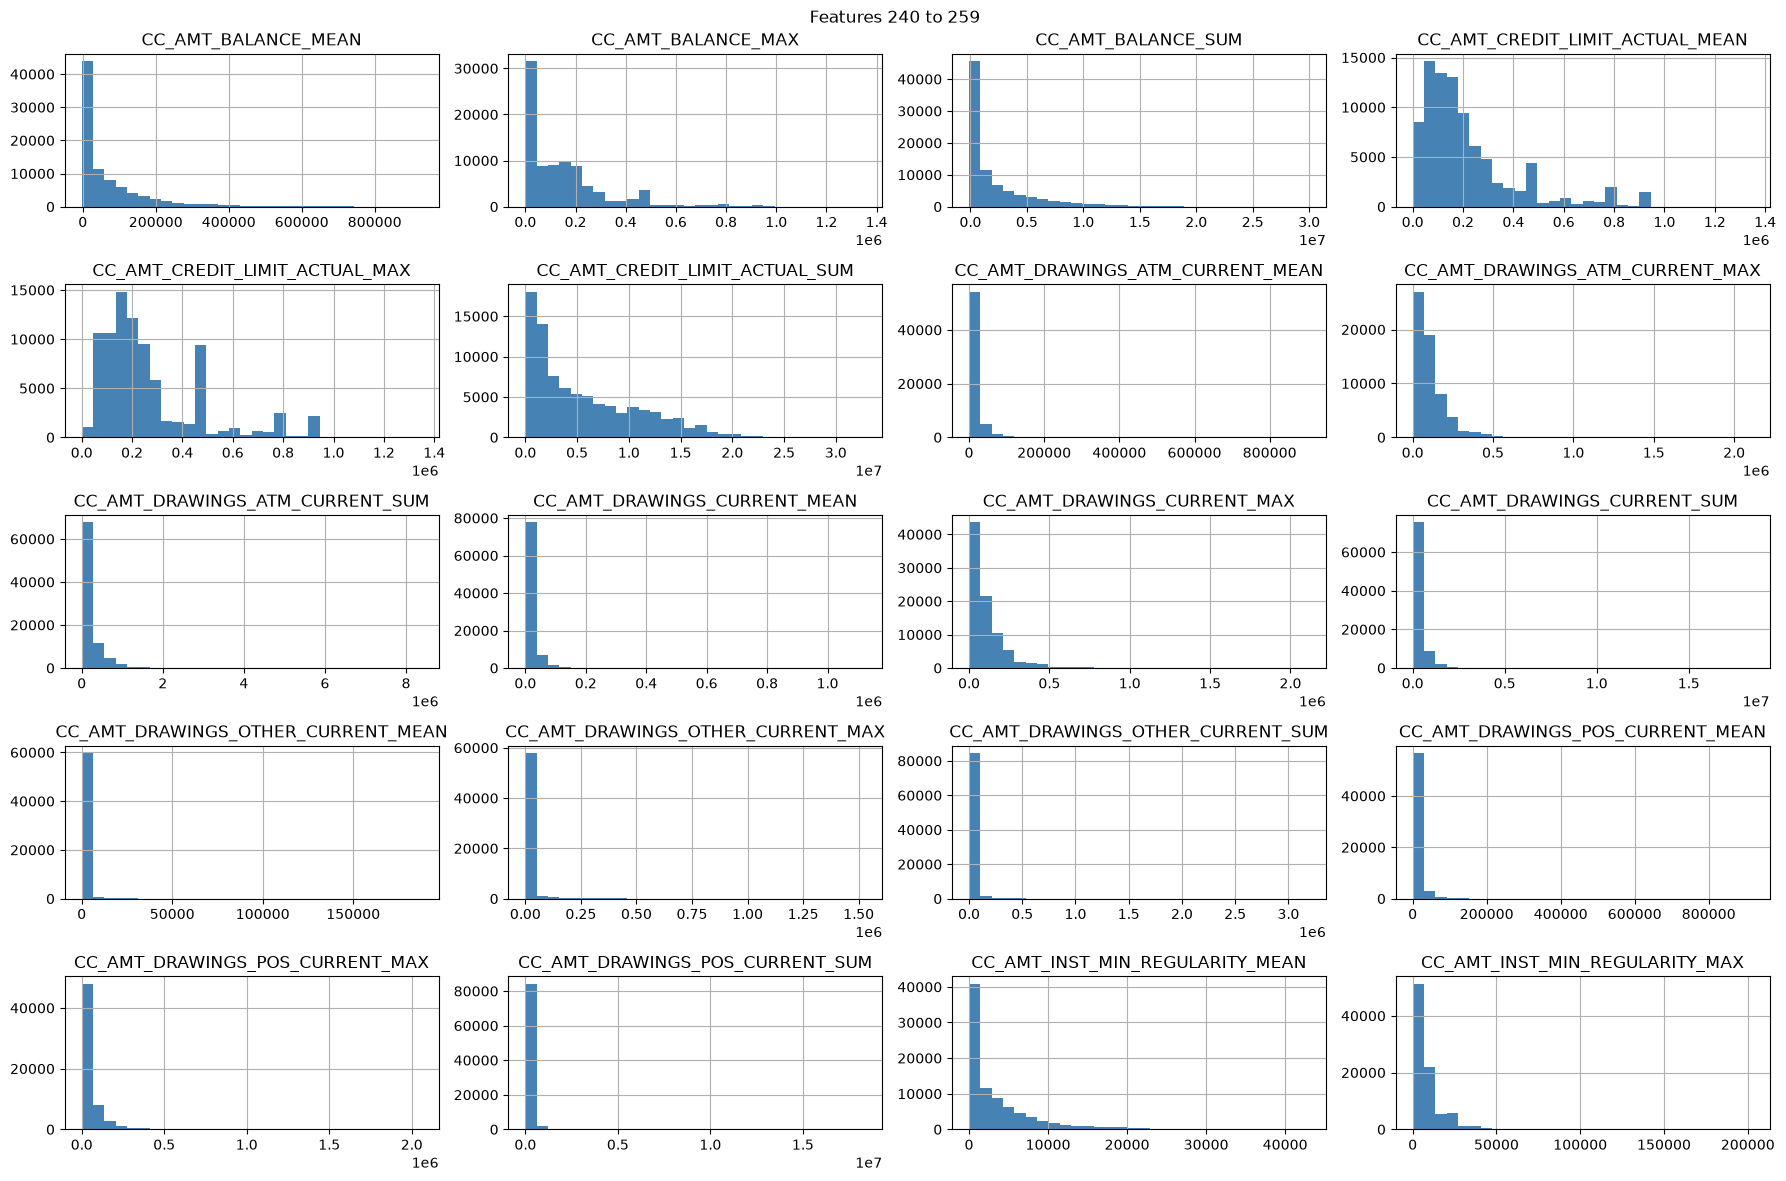

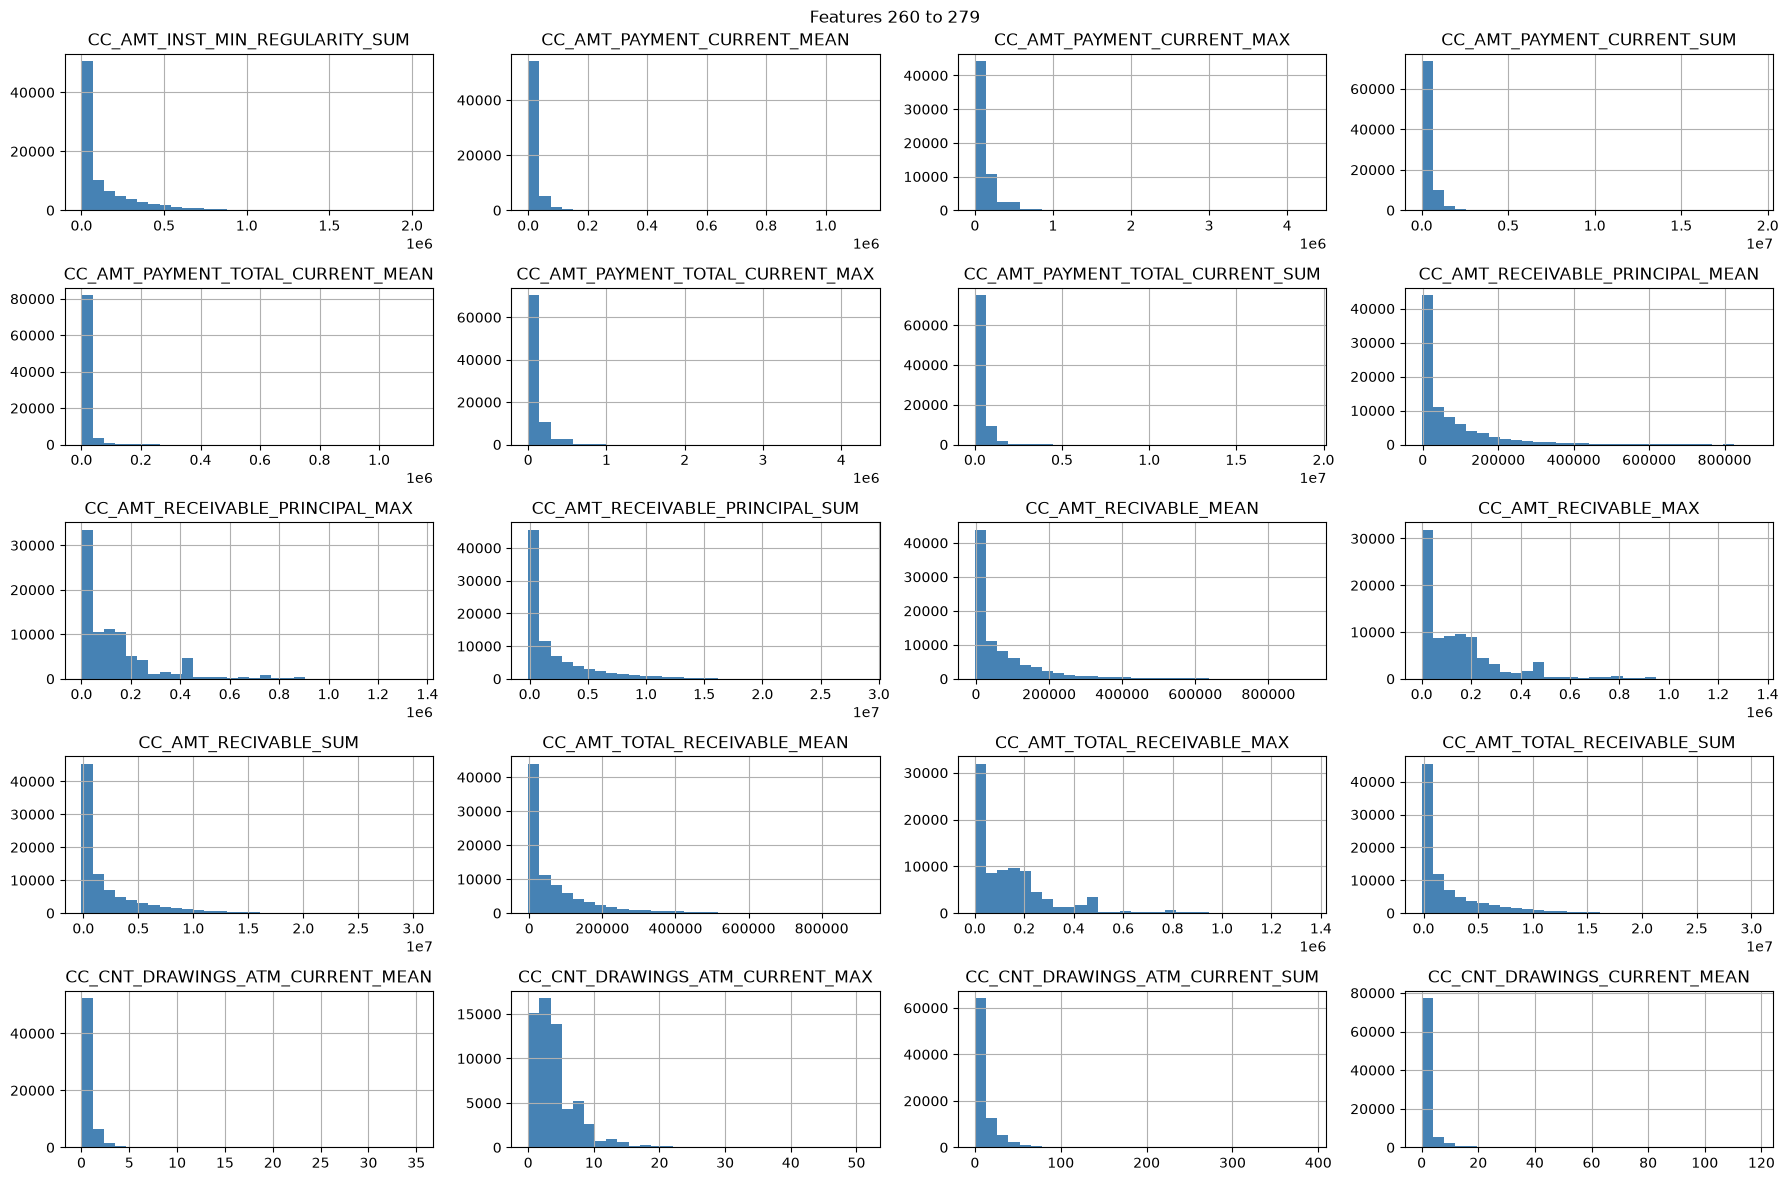

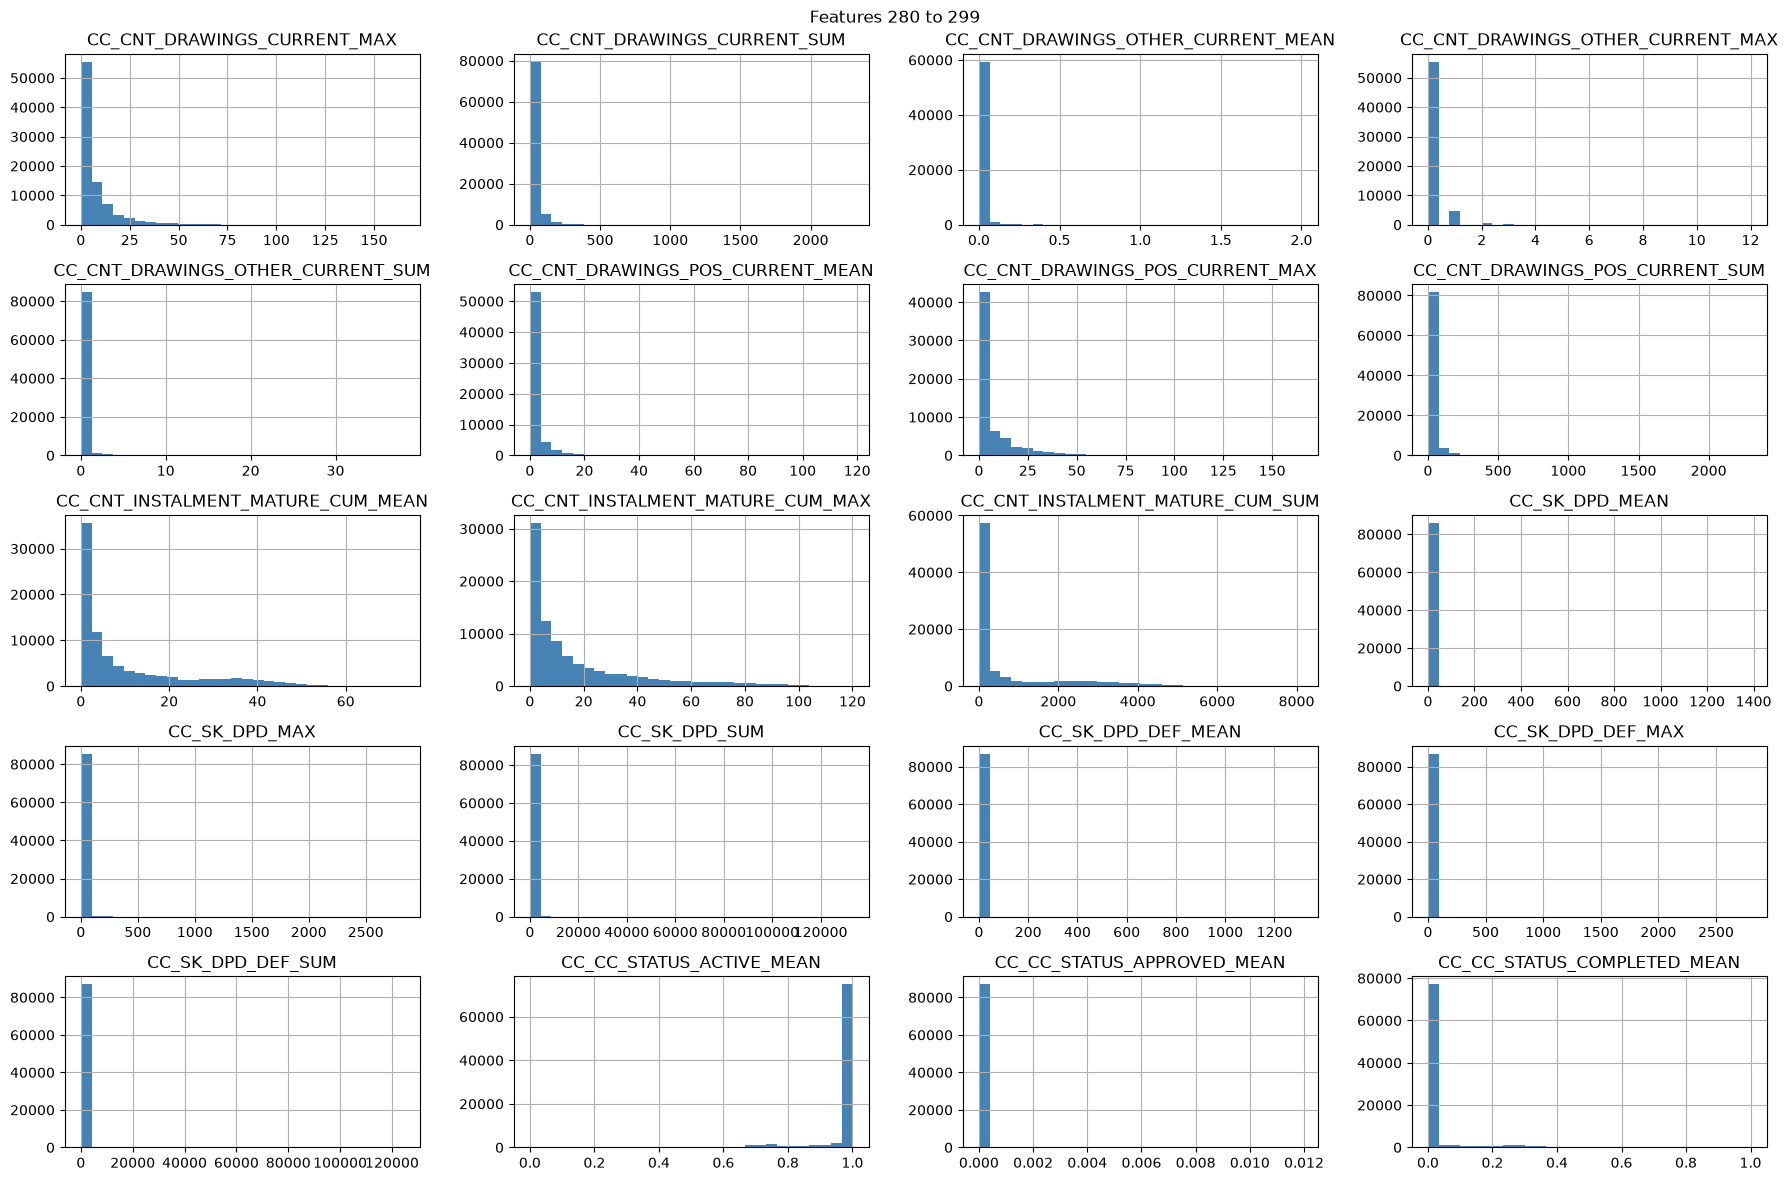

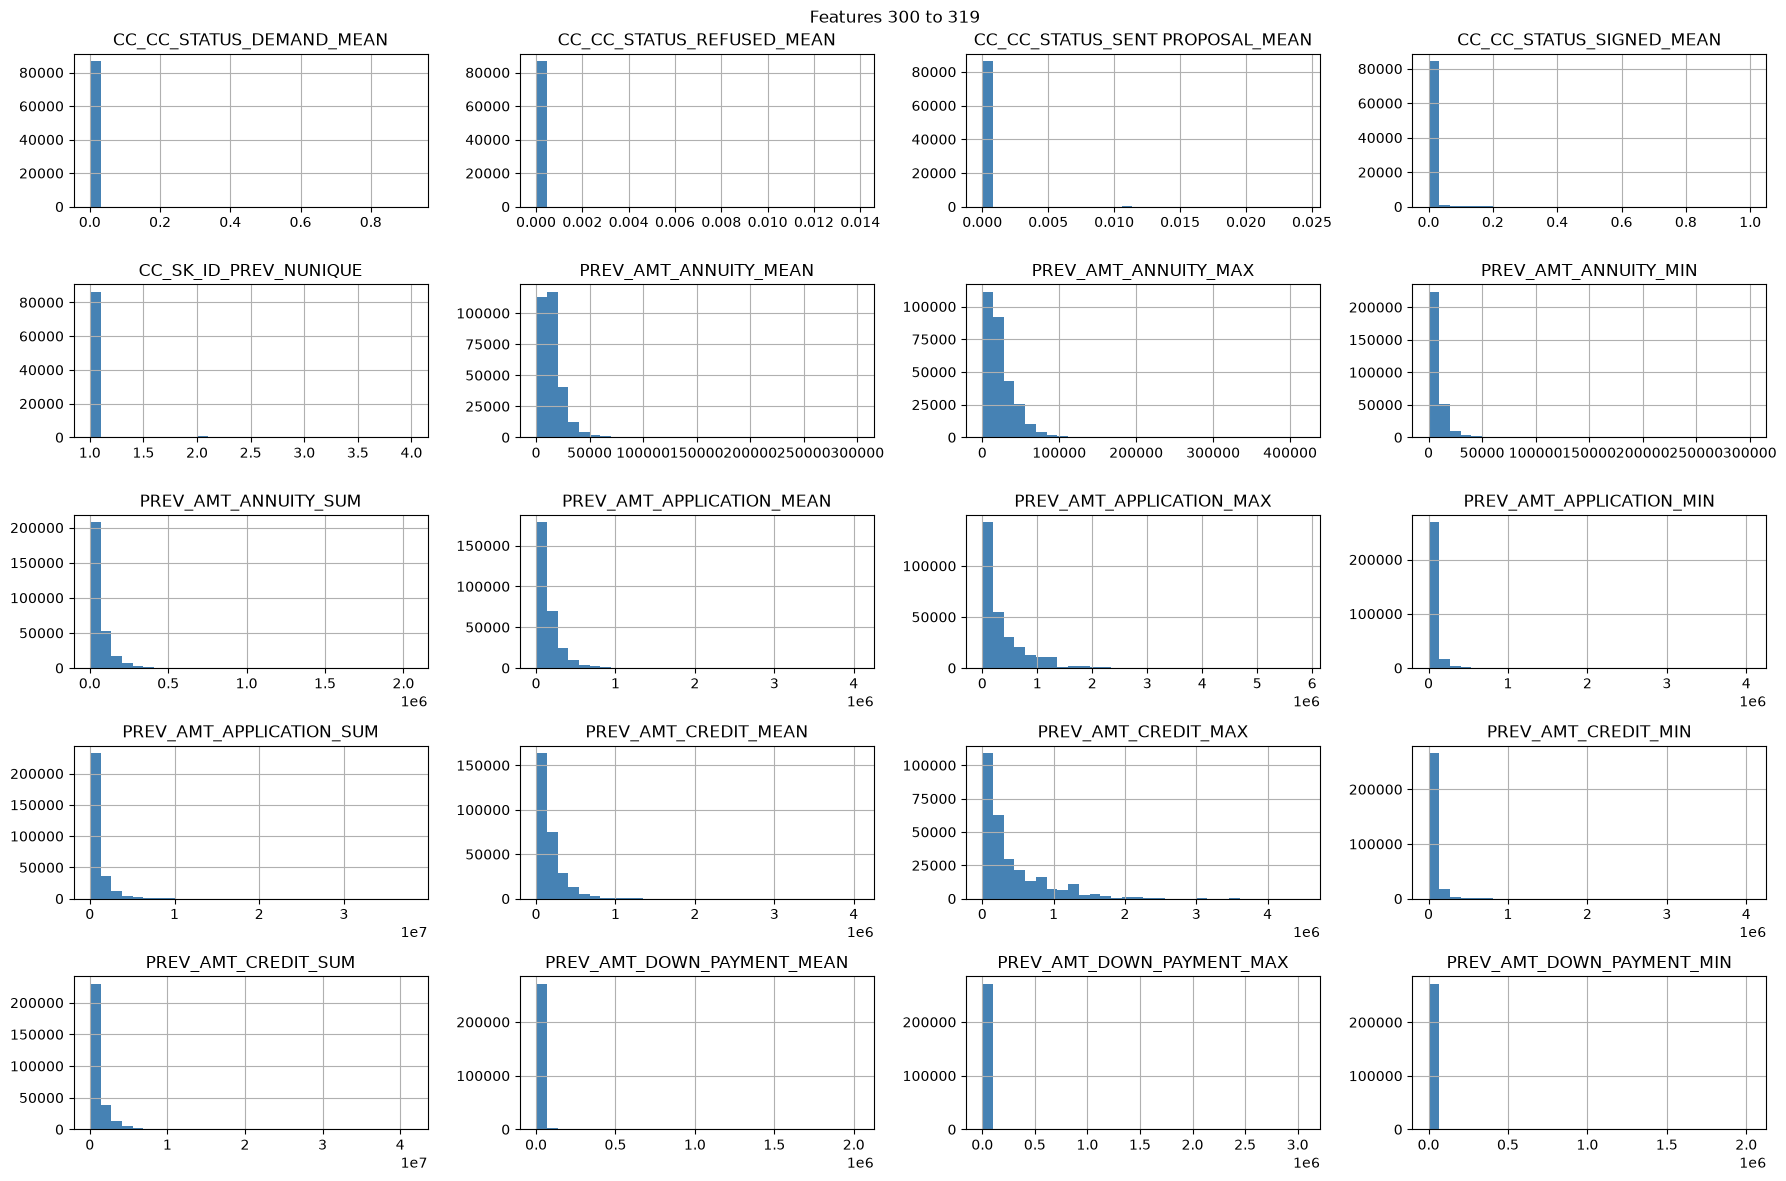

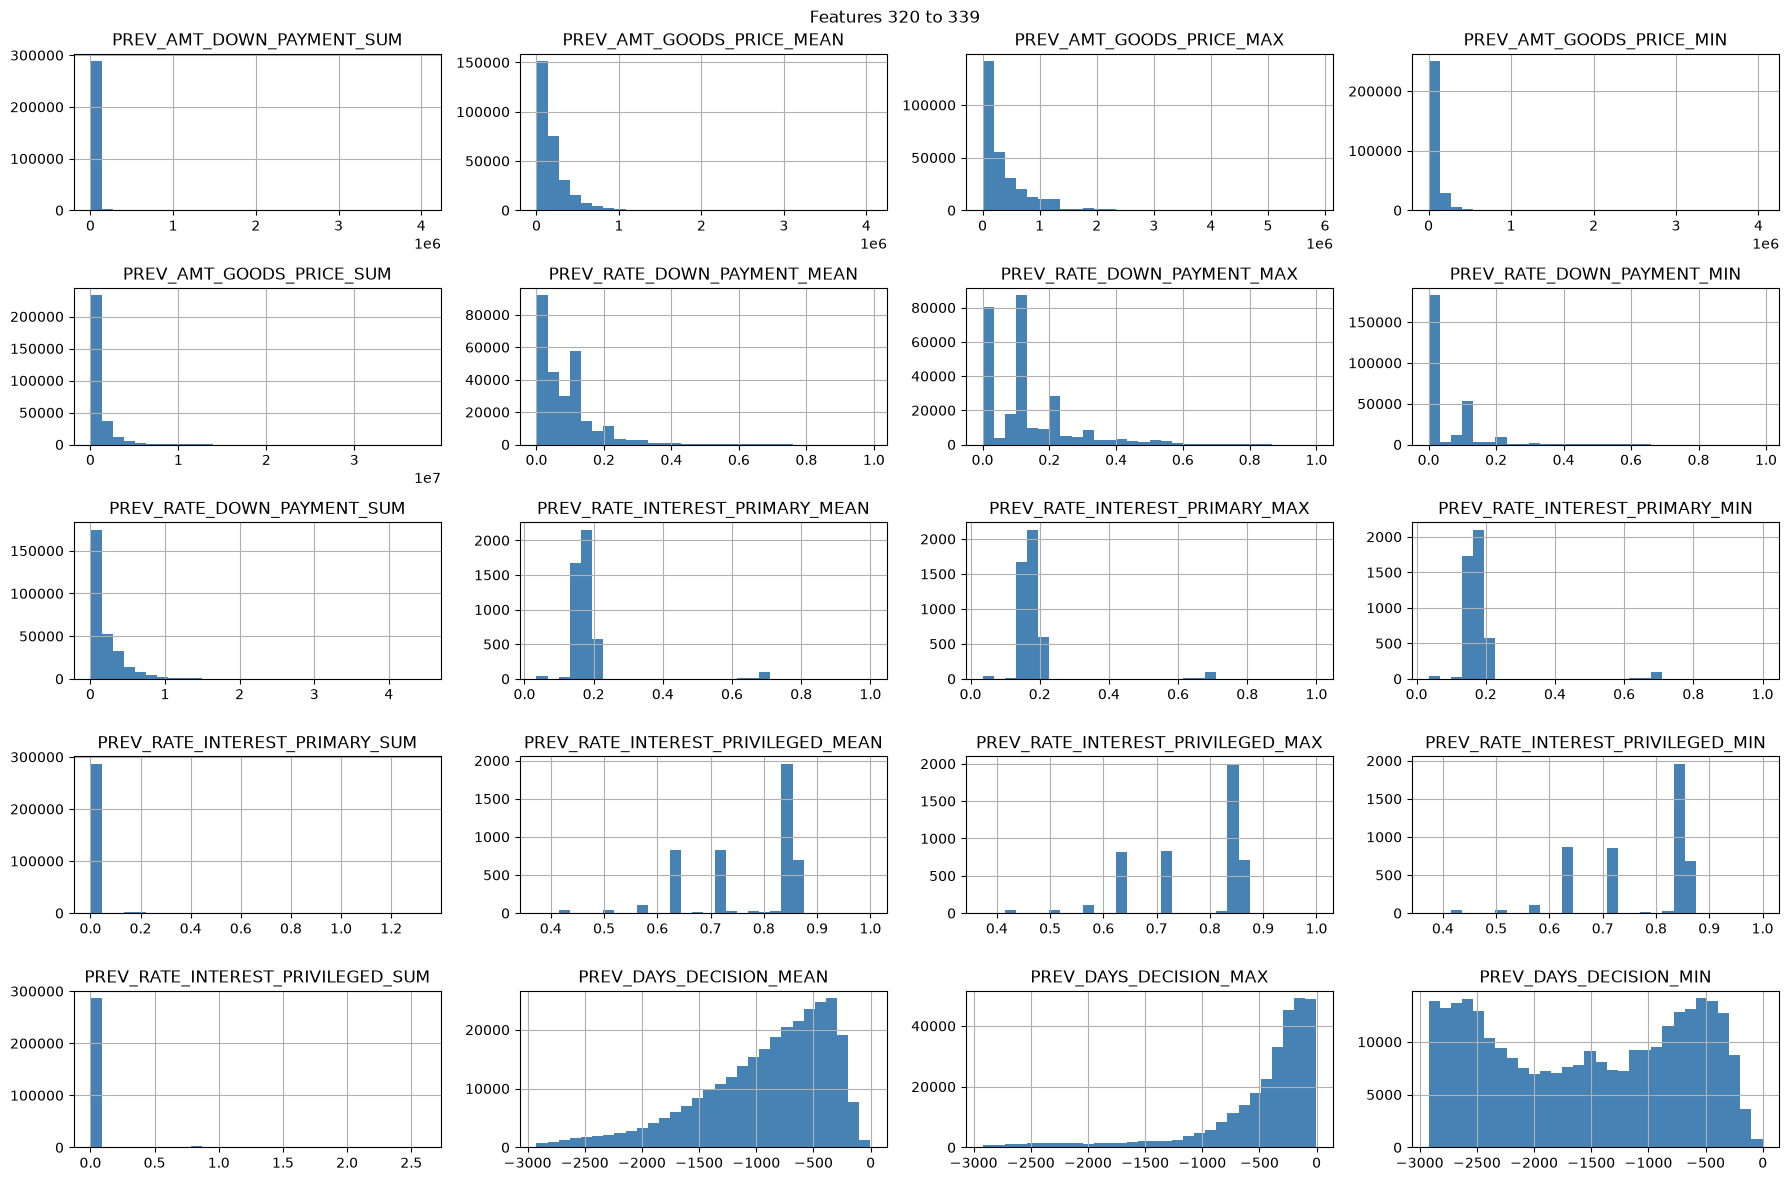

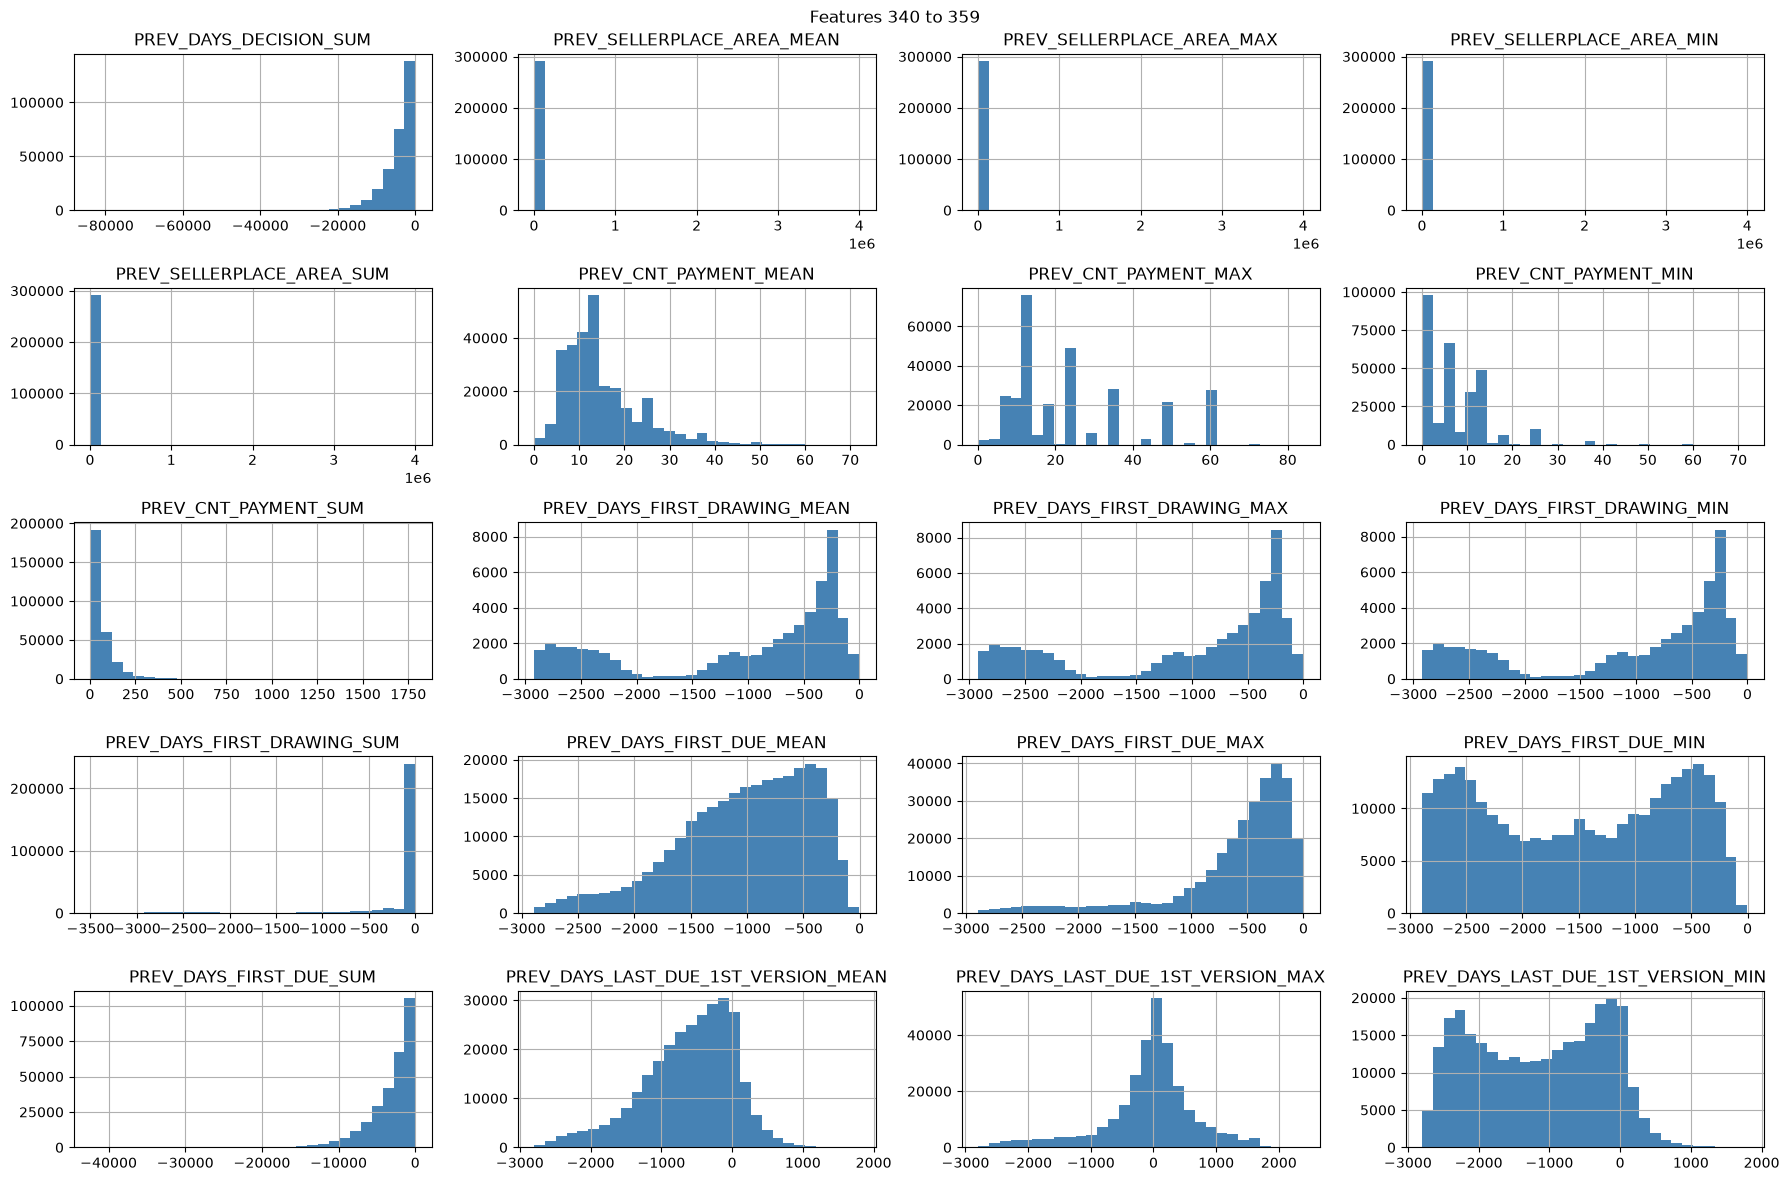

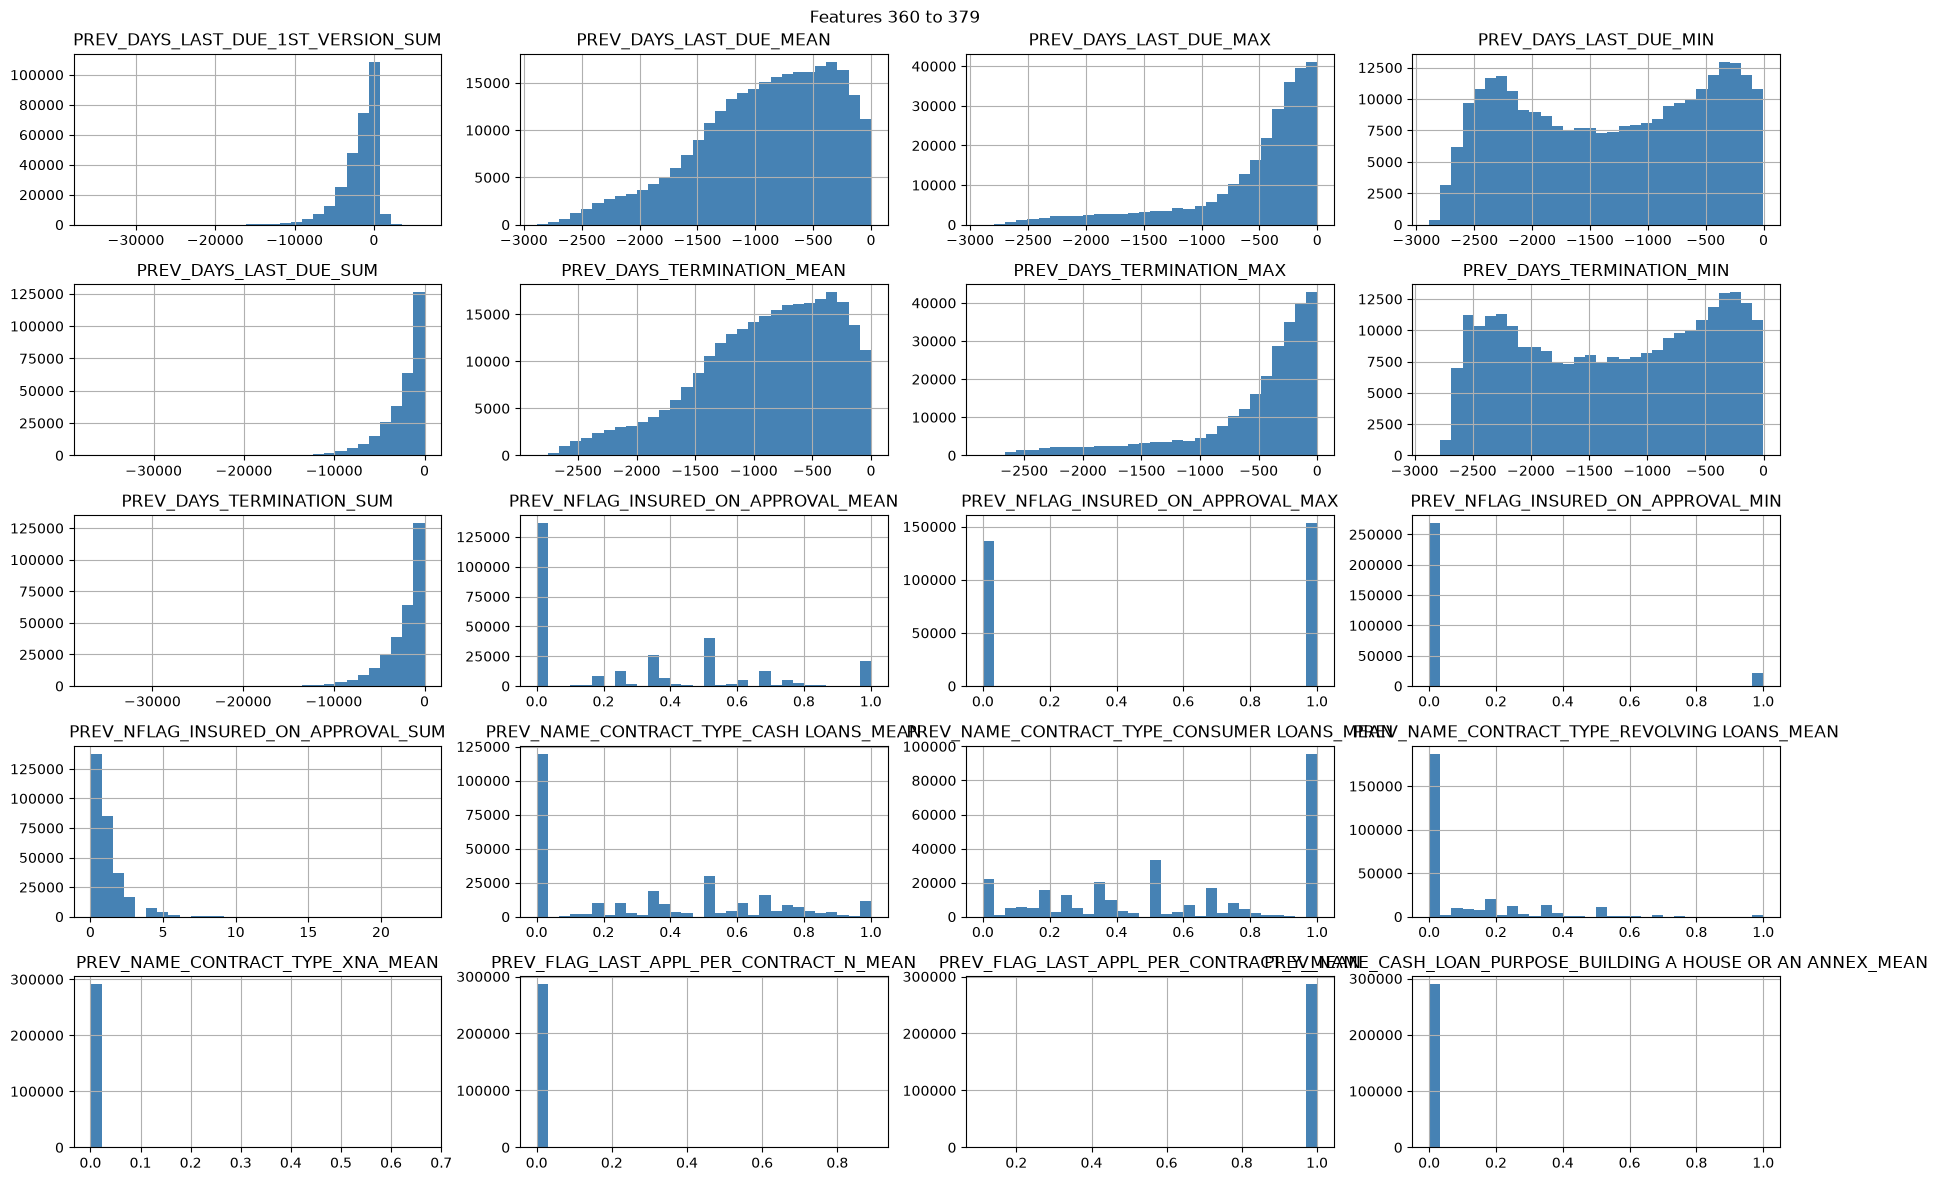

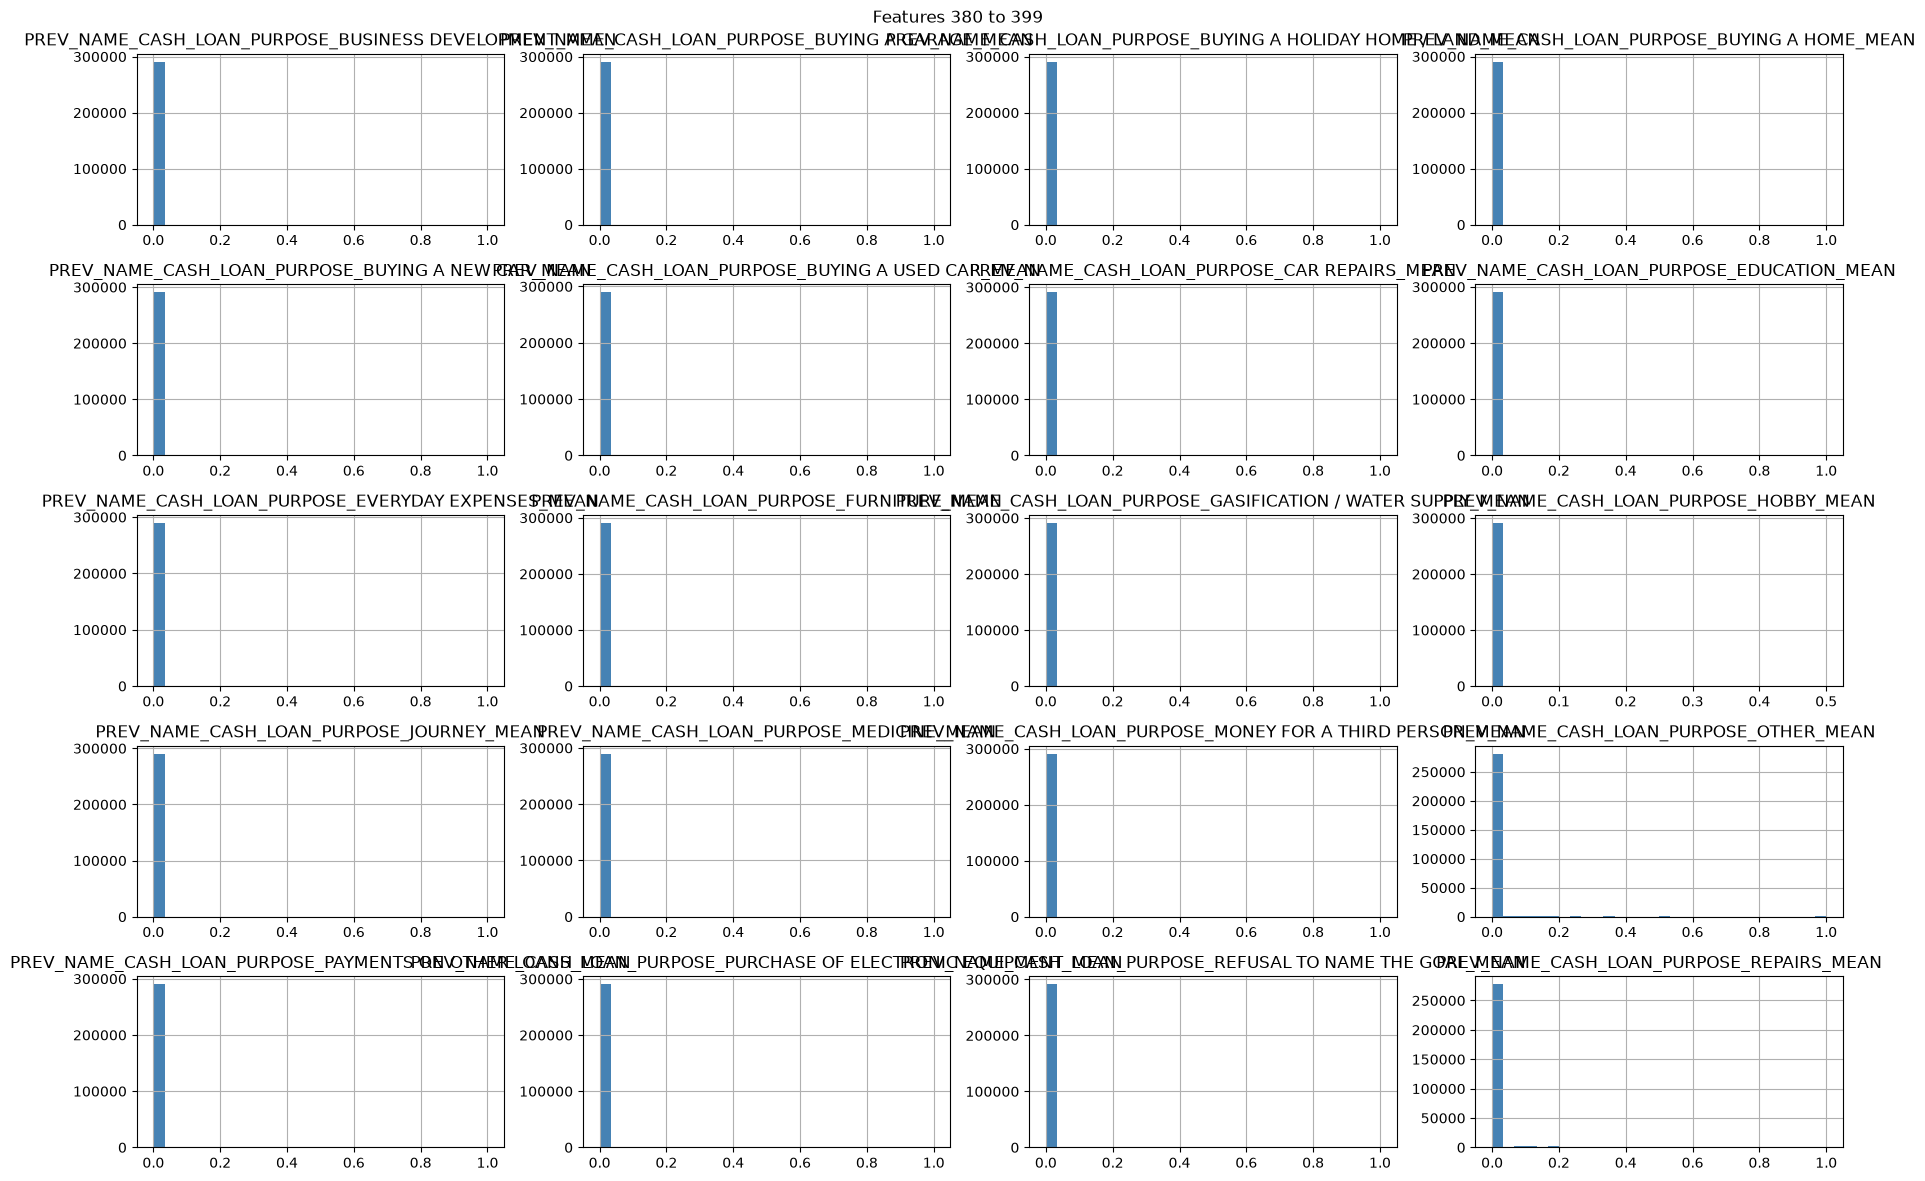

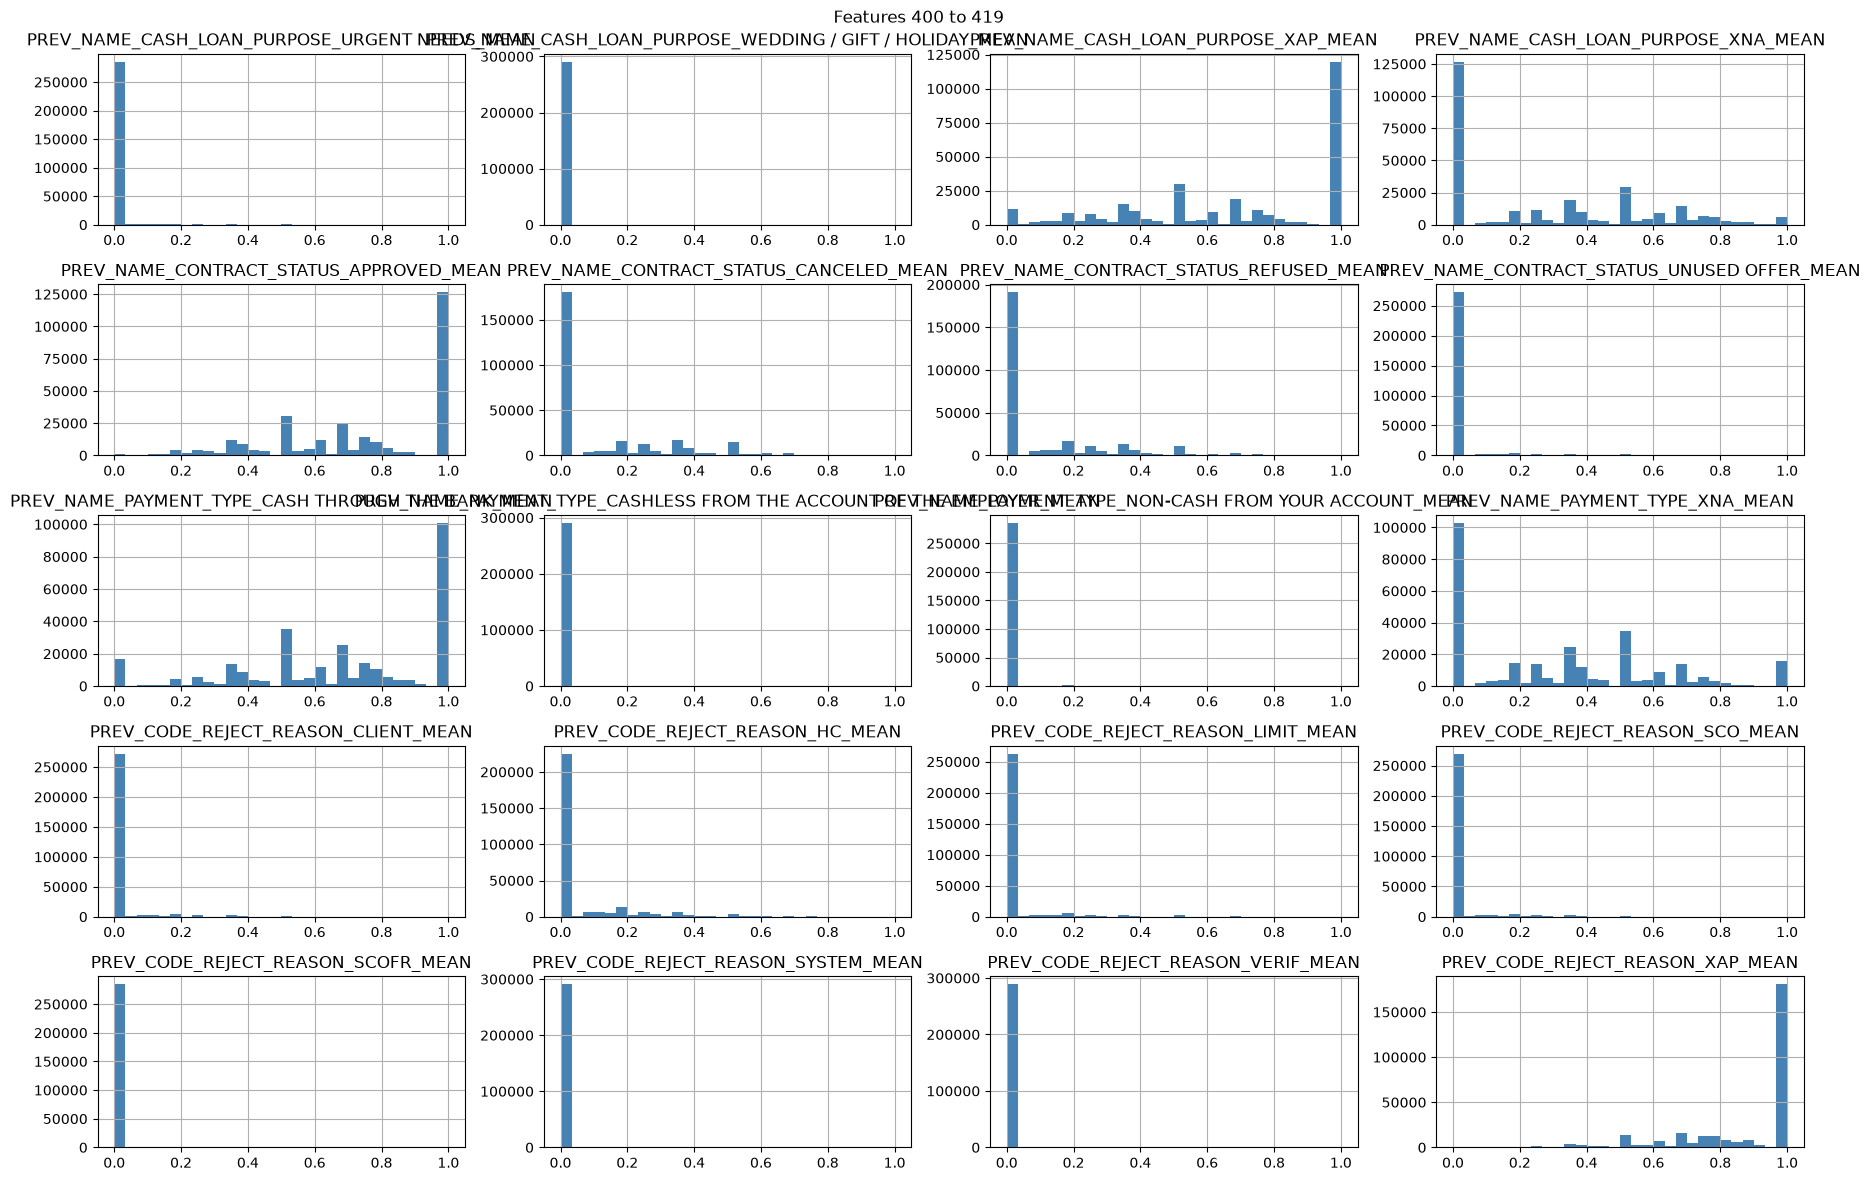

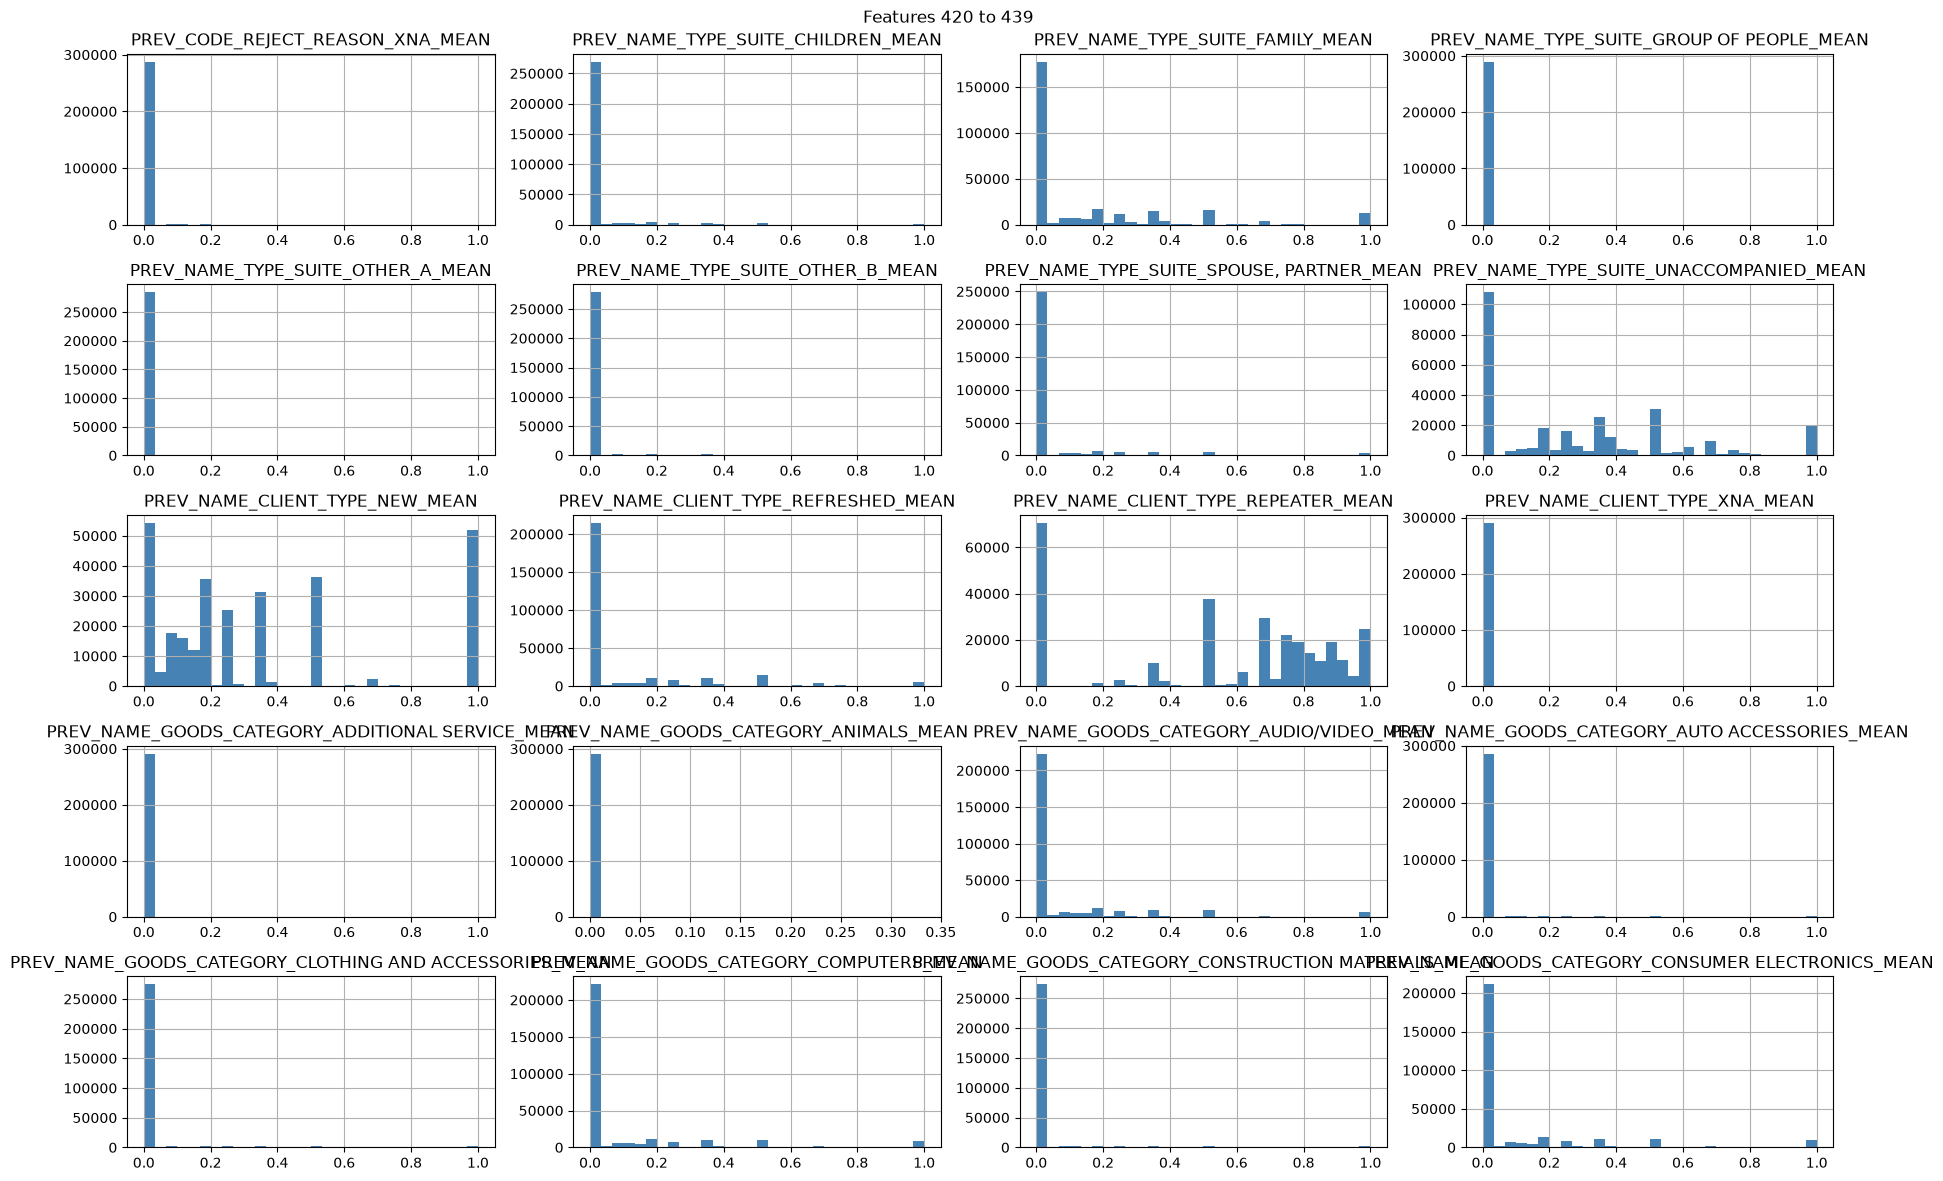

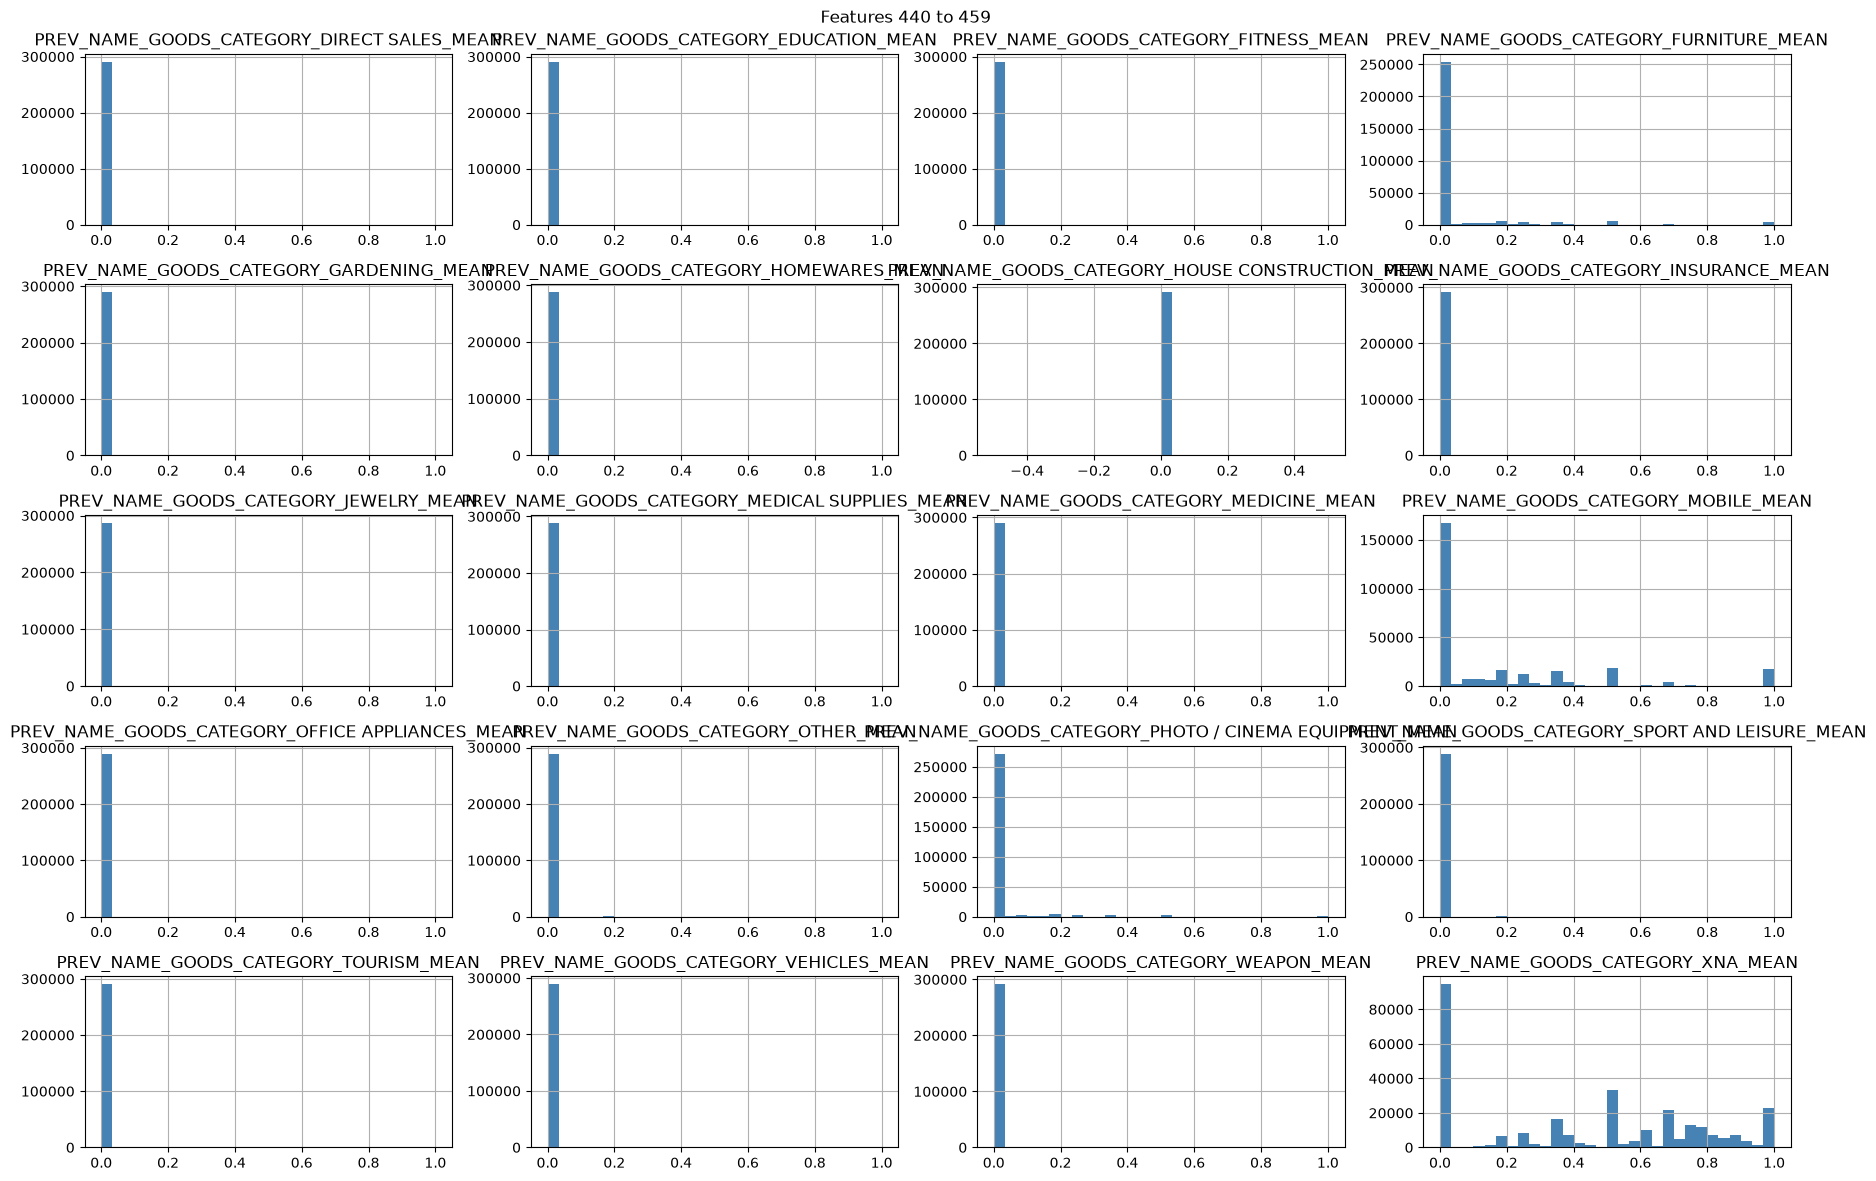

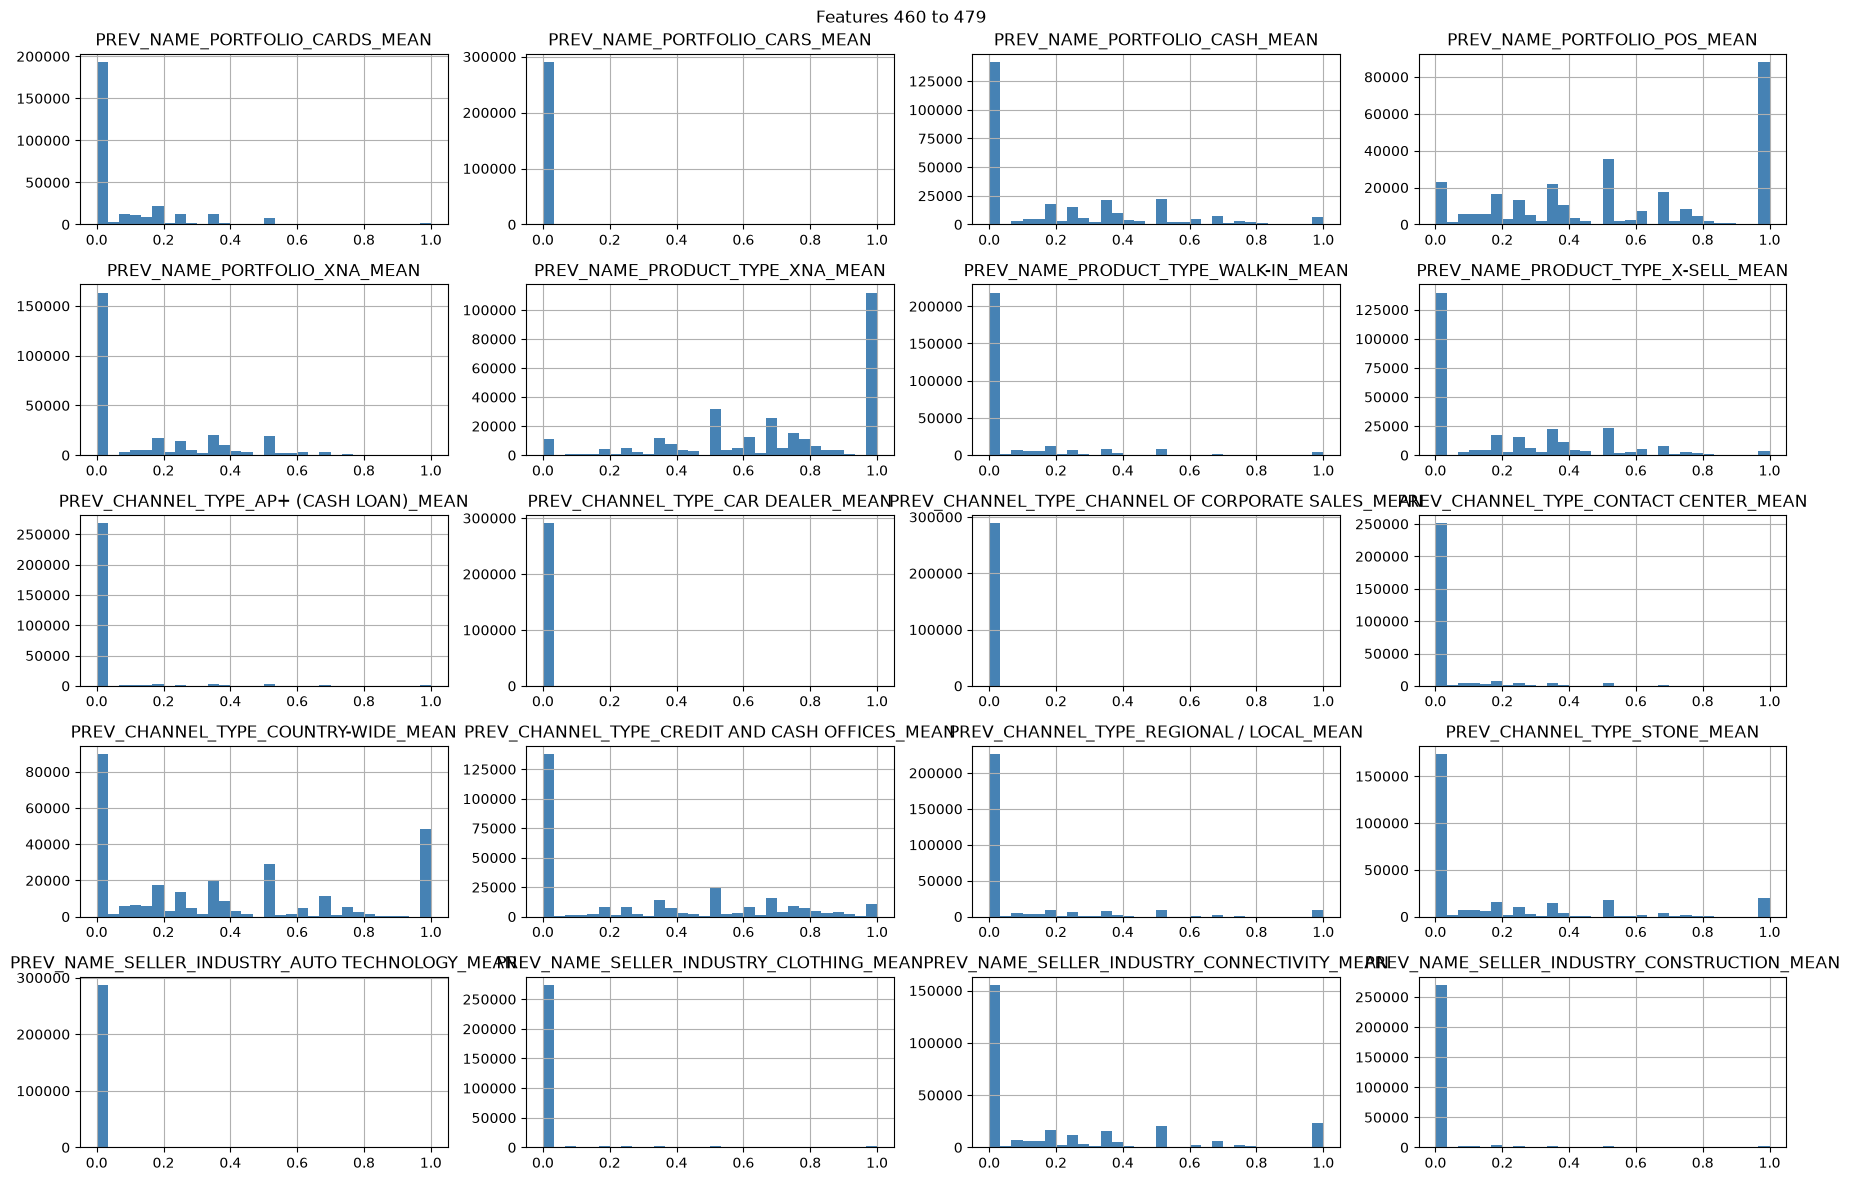

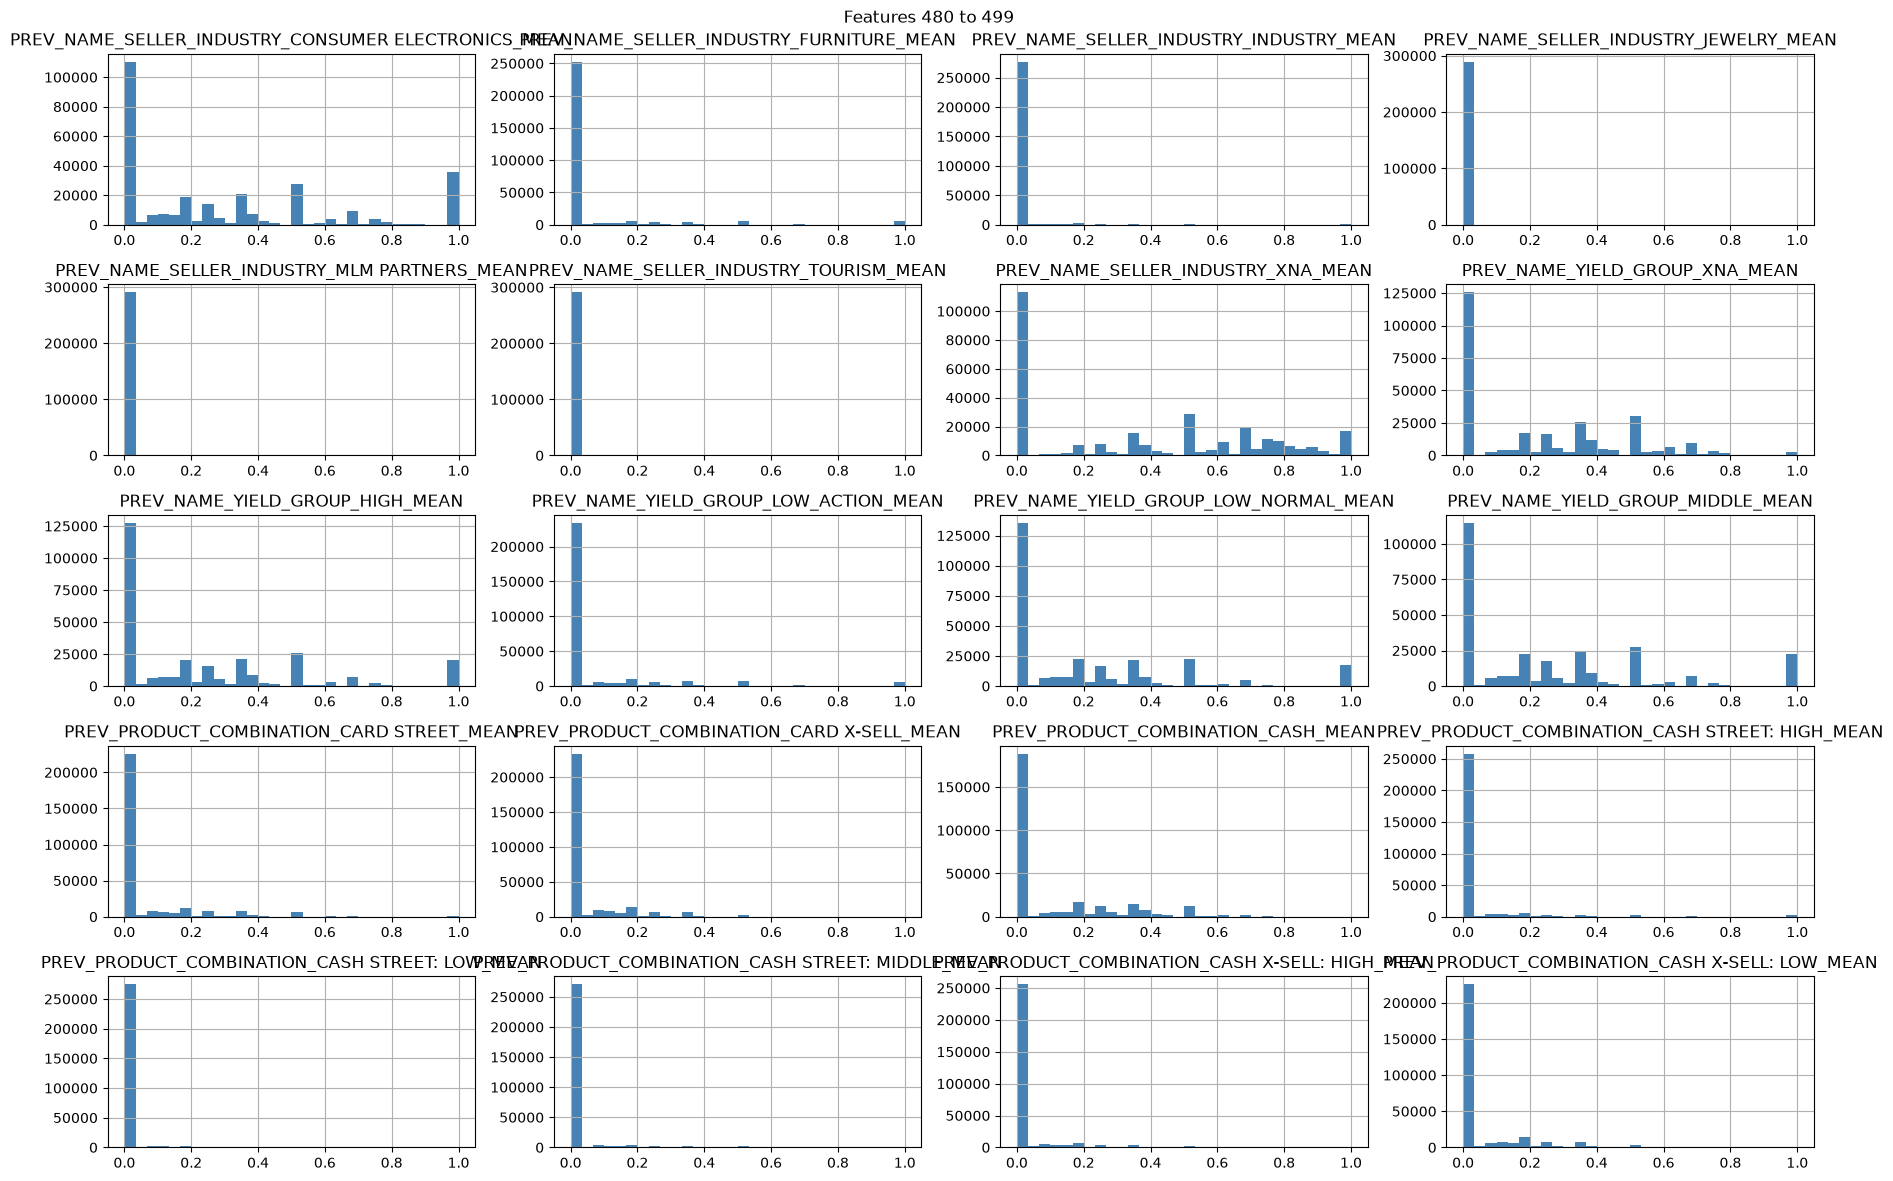

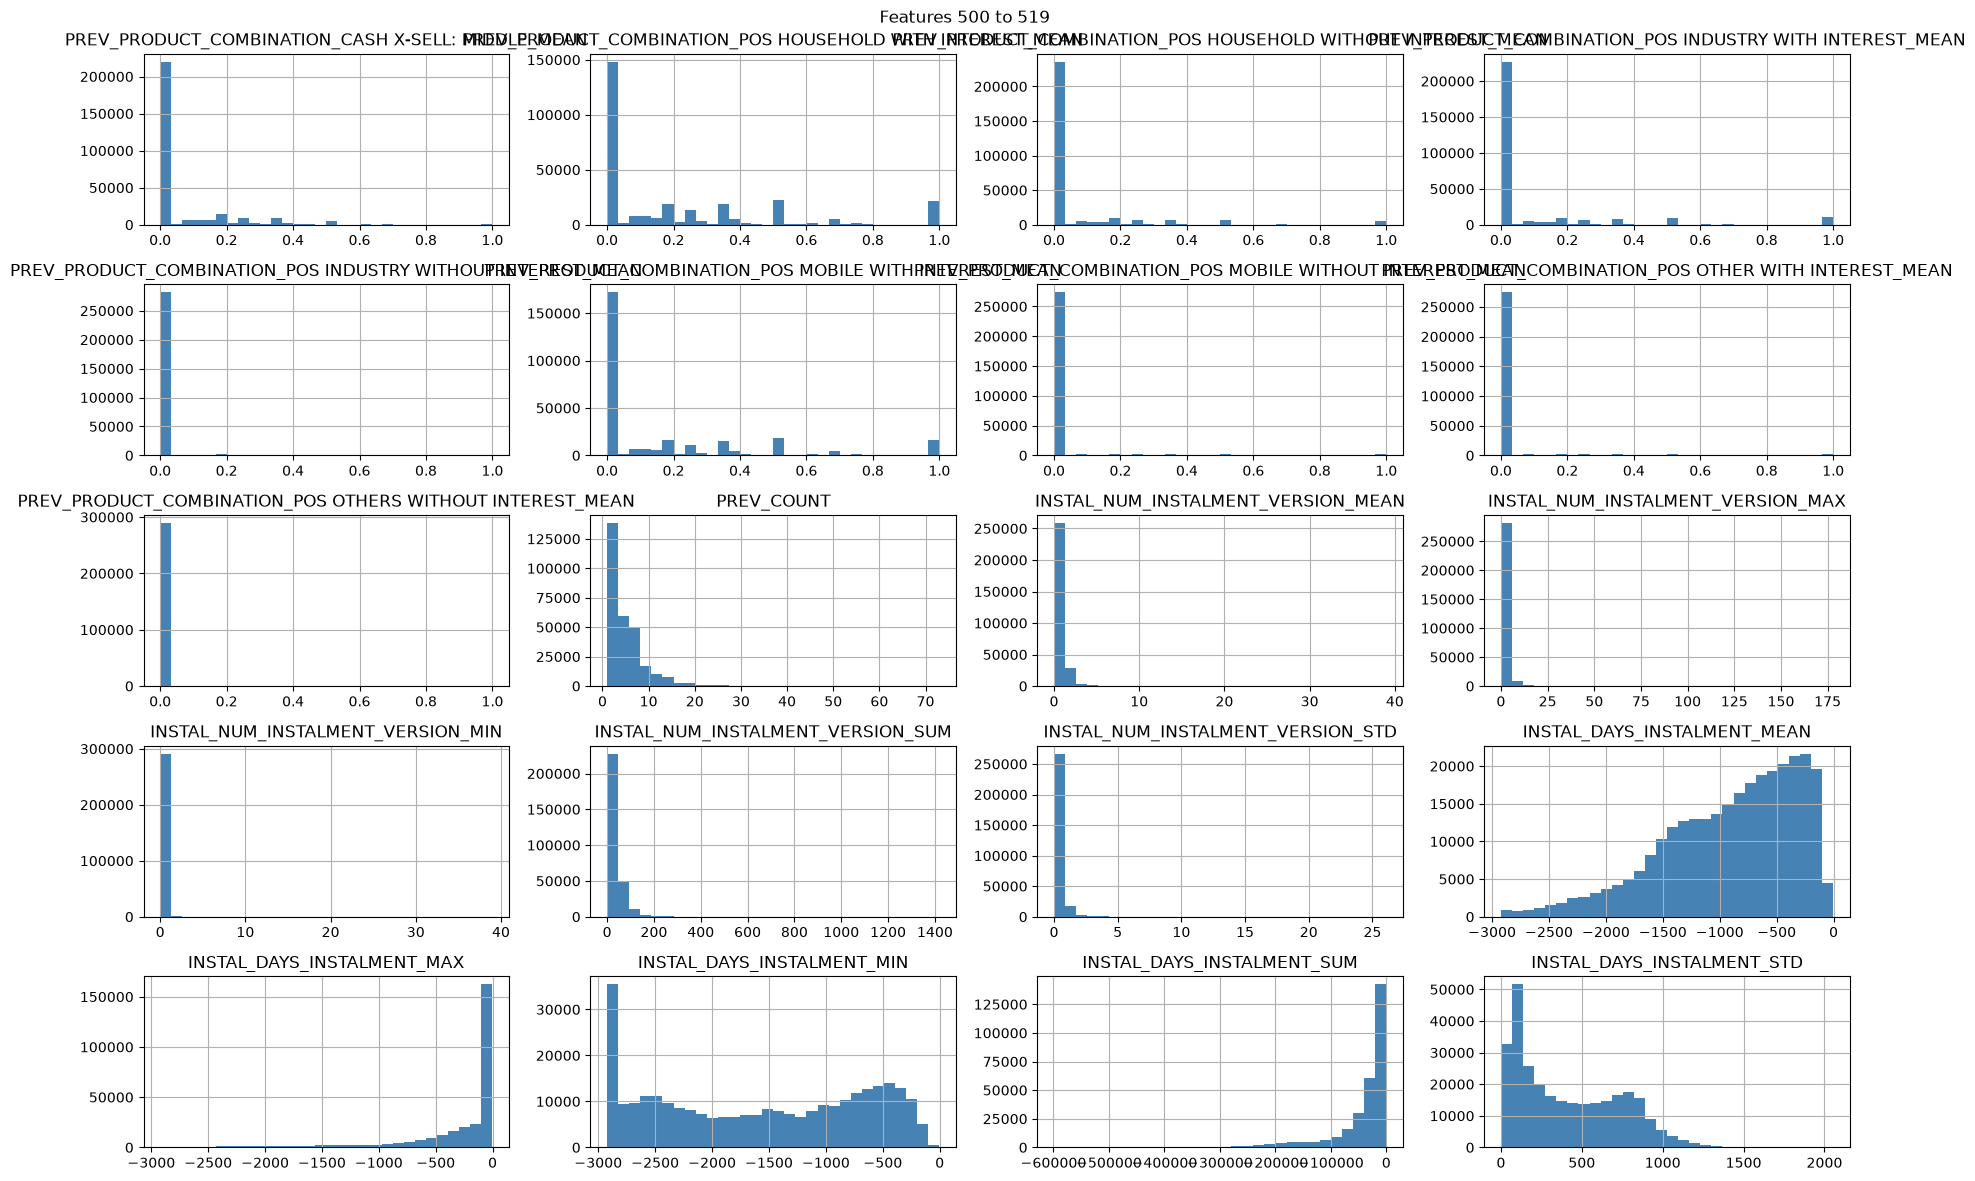

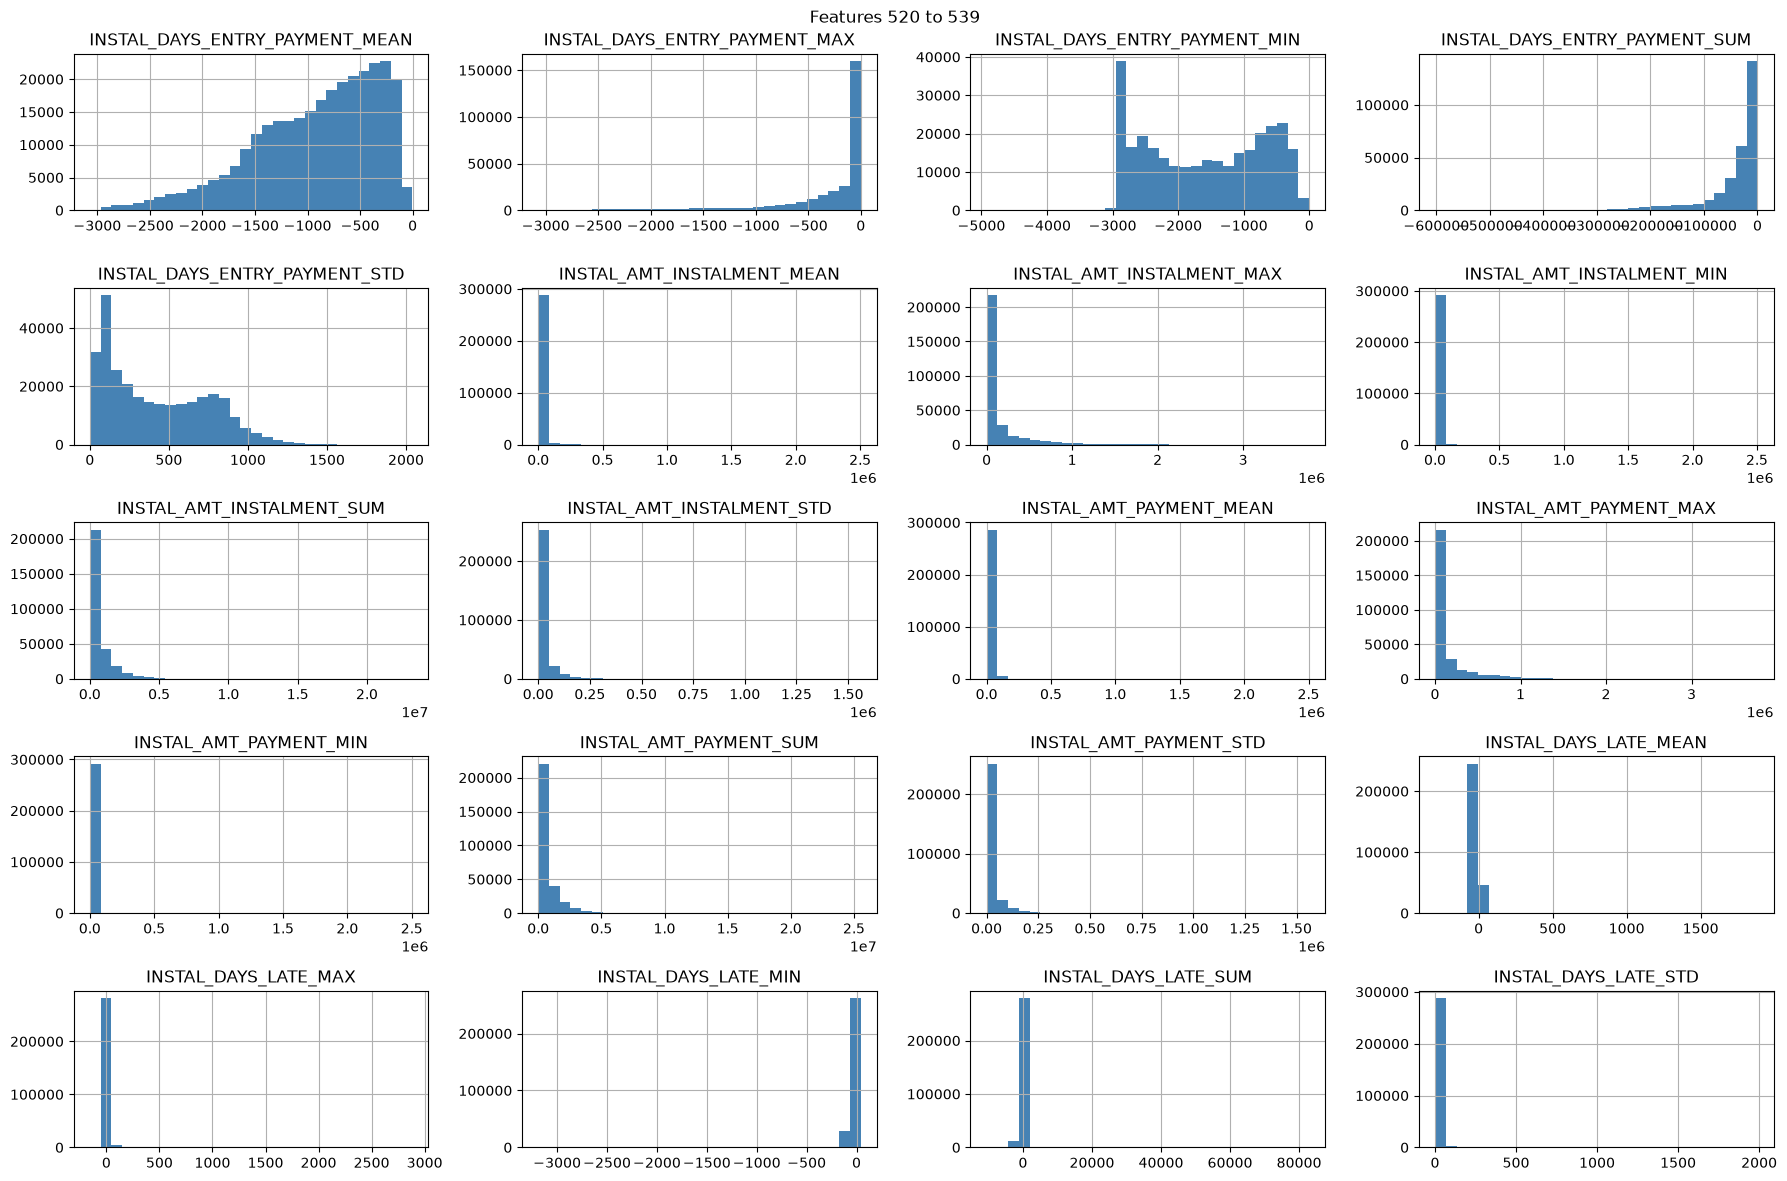

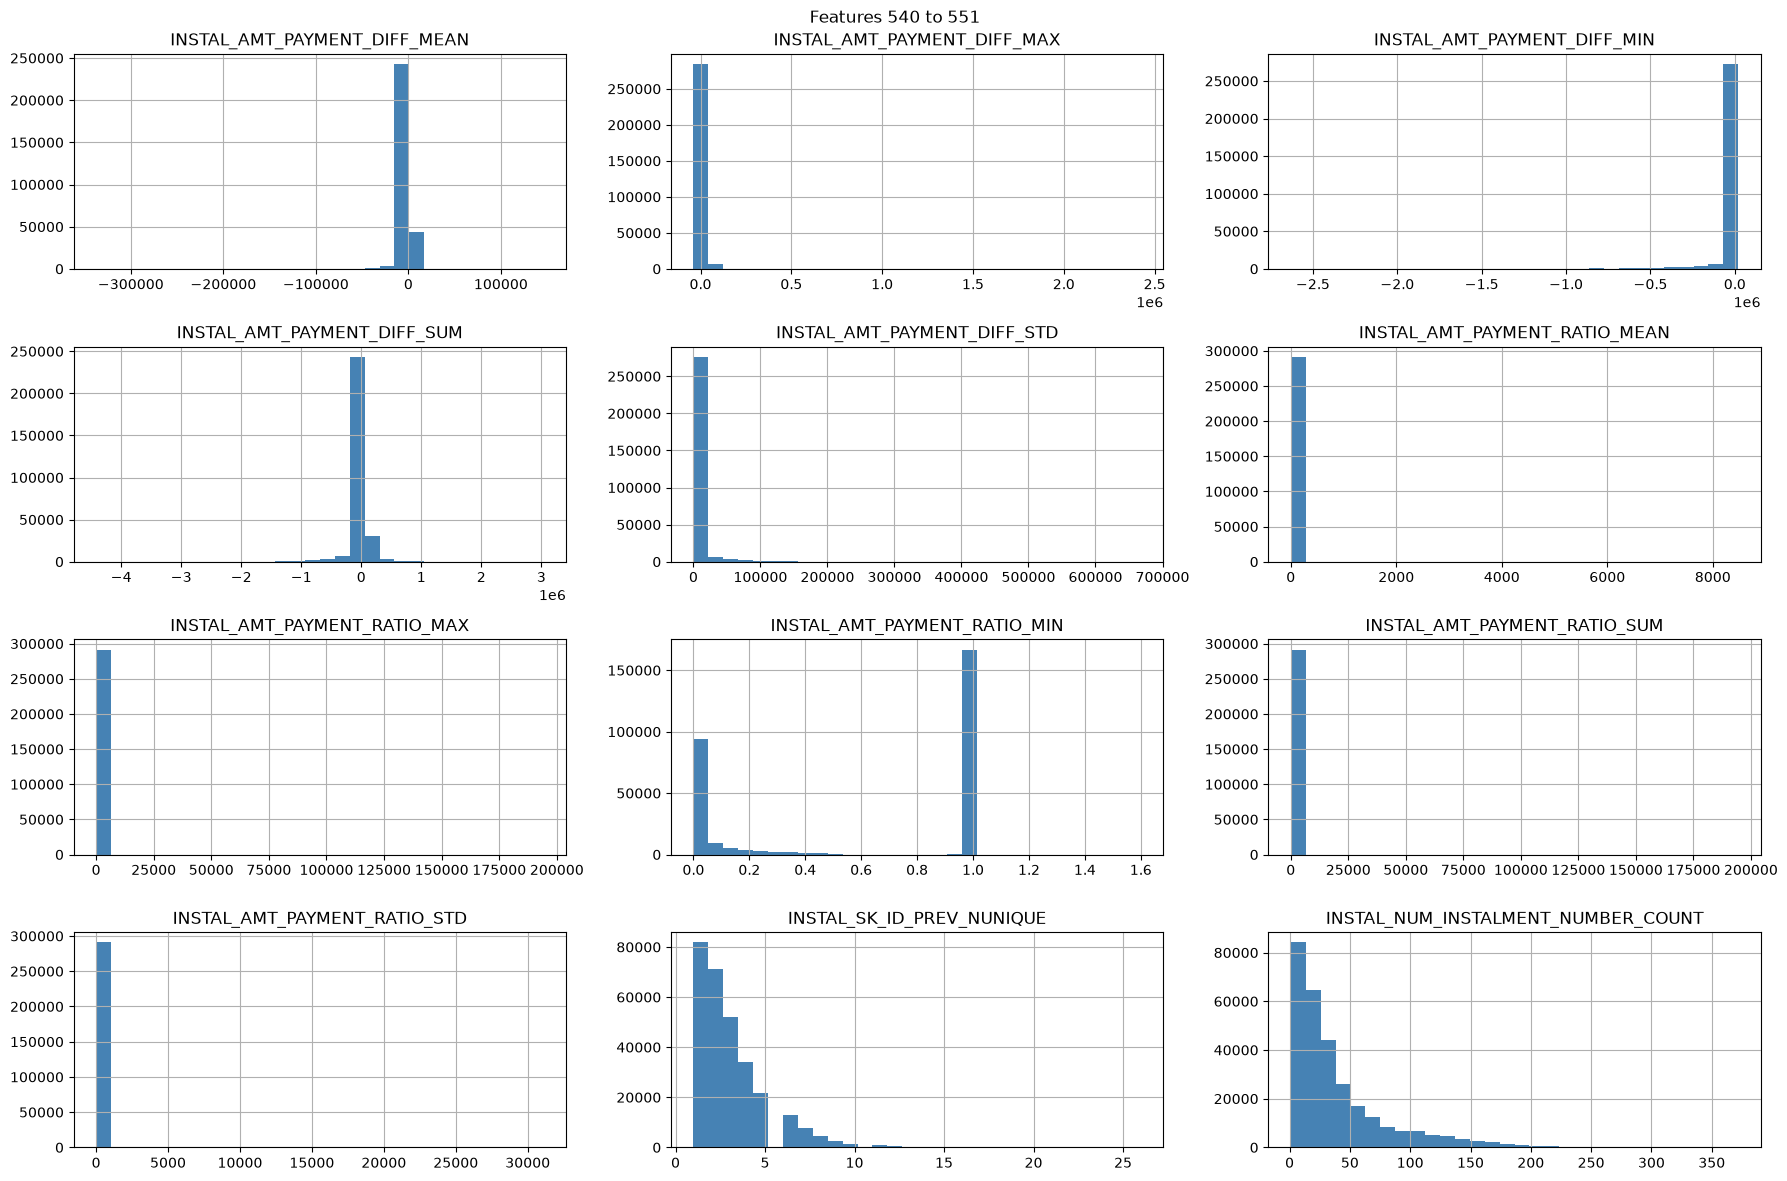

In [32]:
chunk_size = 20
cols = list(numeric_cols)

for i in range(0, len(cols), chunk_size):
    batch = cols[i:i+chunk_size]
    train[batch].hist(figsize=(18,12), bins=30, color="steelblue")
    plt.suptitle(f"Features {i} to {i+len(batch)-1}")
    plt.tight_layout()
    plt.show()

 A more efficient alternative is a skewness table, which flags which columns are worth looking at instead of scrolling through hundreds of plots:

In [33]:
skew = train[numeric_cols].skew().sort_values(ascending=False)
print("Most skewed features:")
skew.head(20)

Most skewed features:


PREV_NAME_GOODS_CATEGORY_ANIMALS_MEAN                                   539.496948
BUREAU_CREDIT_TYPE_MOBILE OPERATOR LOAN_MEAN                            513.313721
BUREAU_CREDIT_TYPE_INTERBANK CREDIT_MEAN                                513.313721
FLAG_DOCUMENT_12                                                        392.114779
AMT_INCOME_TOTAL                                                        391.559631
POS_POS_STATUS_XNA_MEAN                                                 380.470703
PREV_NAME_CASH_LOAN_PURPOSE_REFUSAL TO NAME THE GOAL_MEAN               375.176788
PREV_SELLERPLACE_AREA_MIN                                               374.351117
BUREAU_AMT_CREDIT_MAX_OVERDUE_MIN                                       371.423096
BUREAU_AMT_CREDIT_SUM_OVERDUE_MIN                                       364.549011
POS_POS_STATUS_CANCELED_MEAN                                            361.141754
PREV_SELLERPLACE_AREA_MEAN                                              357.969299
BURE

c:\Users\User\Desktop\final project\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\User\Desktop\final project\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


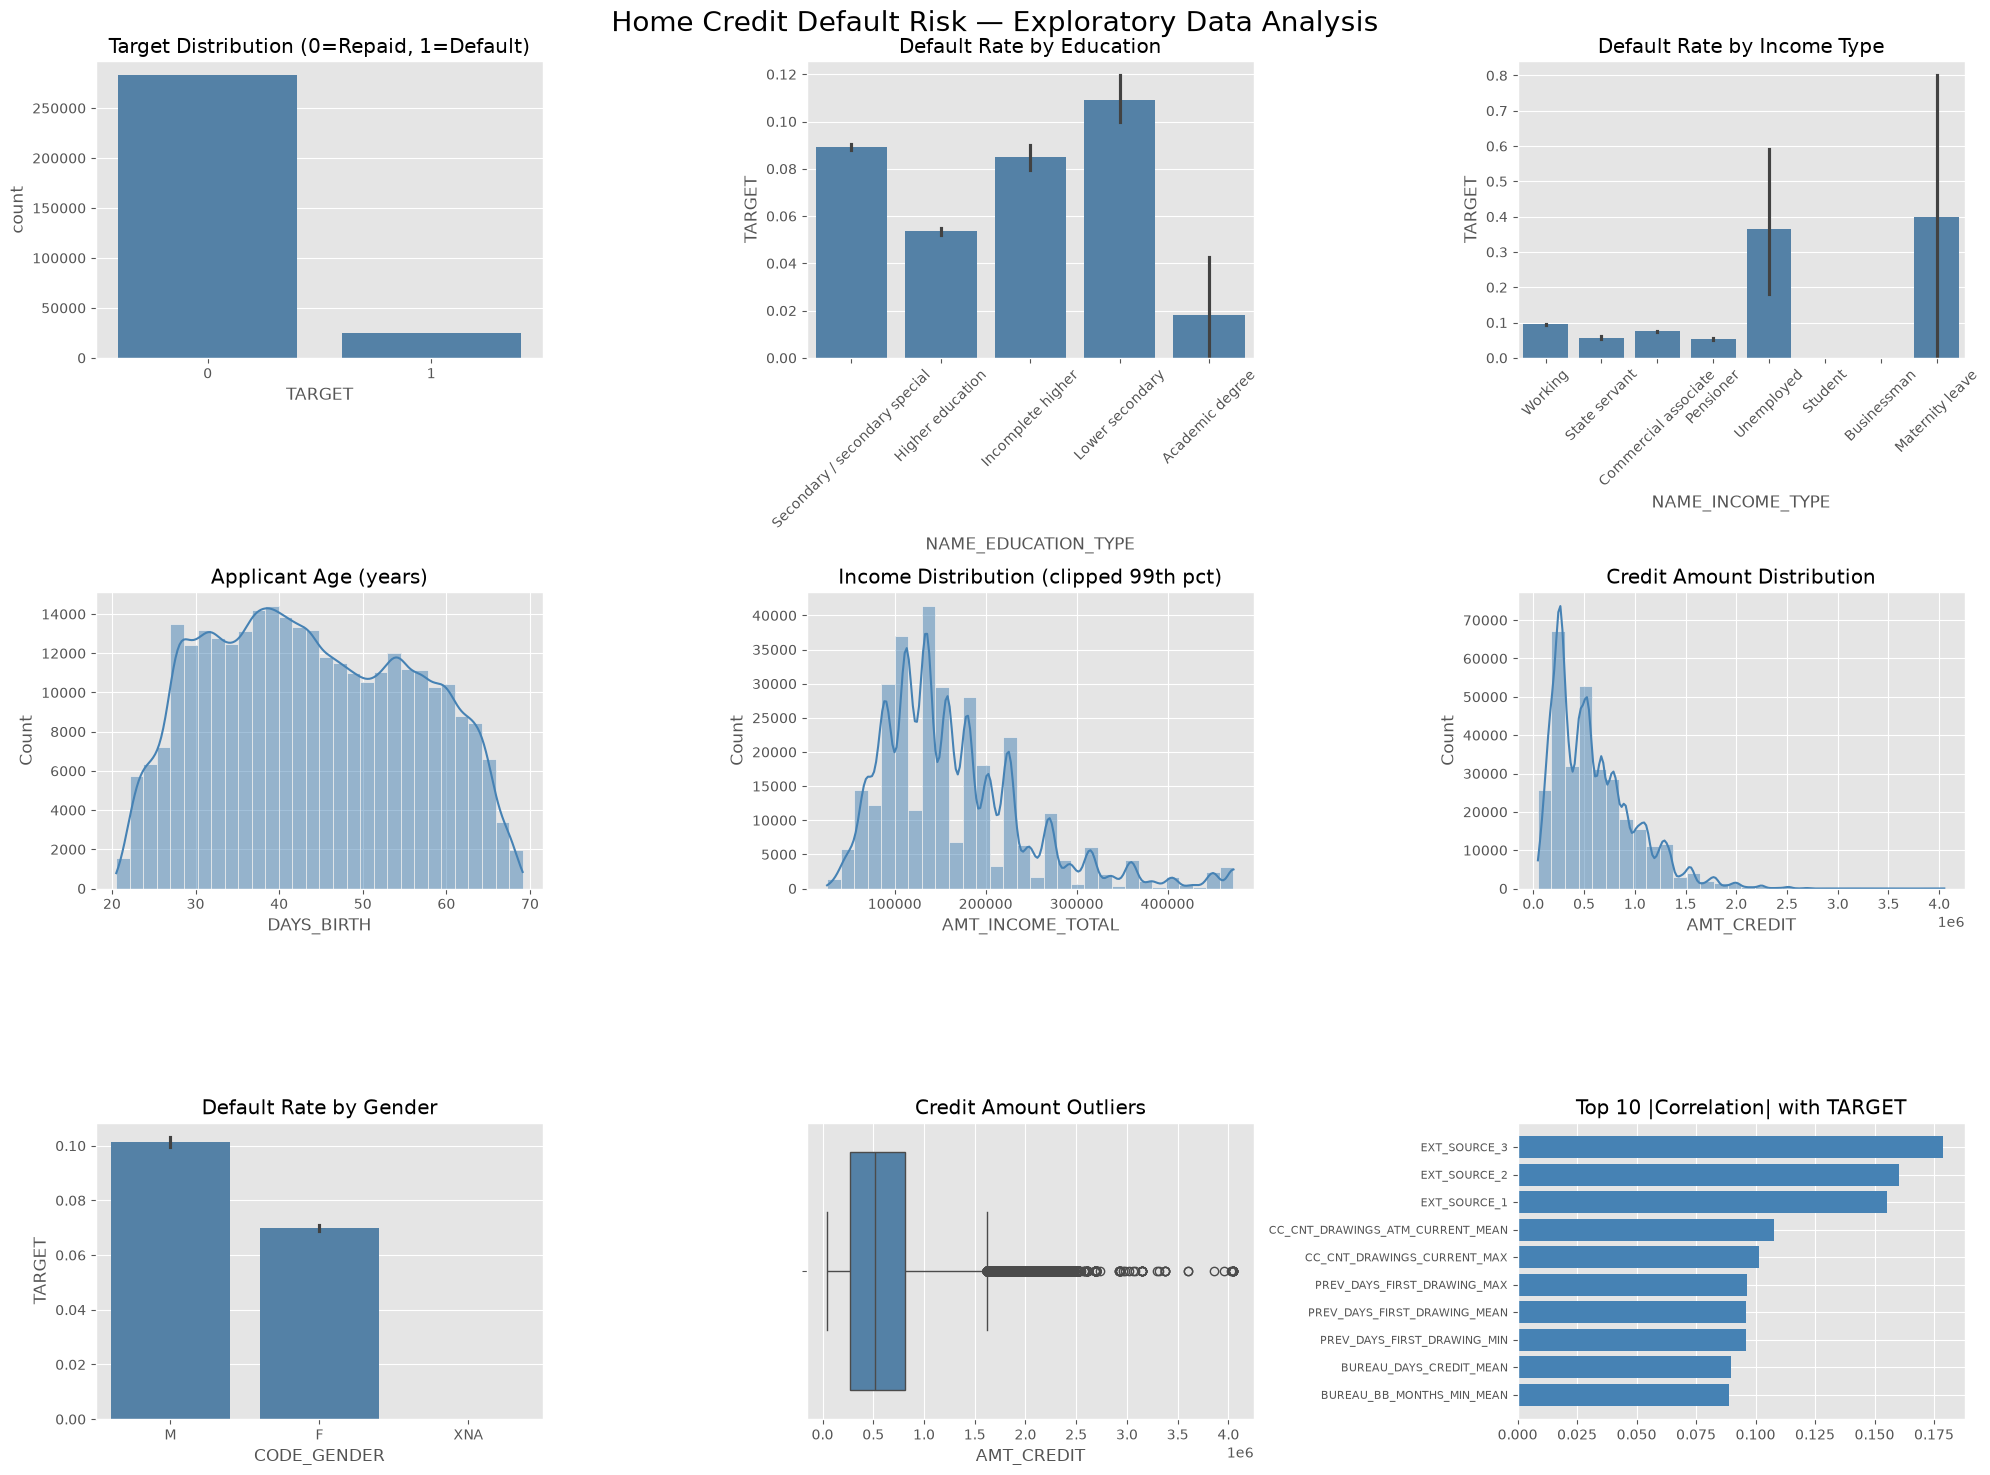

In [34]:
BLUE = "steelblue"
RED = "indianred"

plt.style.use("ggplot")

# Create dashboard
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle("Home Credit Default Risk — Exploratory Data Analysis", fontsize=20)

# 1. Target distribution (class imbalance)
sns.countplot(data=train, x="TARGET", color=BLUE, ax=axes[0,0])
axes[0,0].set_title("Target Distribution (0=Repaid, 1=Default)")

# 2. Default rate by education
sns.barplot(
    data=train, x="NAME_EDUCATION_TYPE", y="TARGET",
    estimator="mean", color=BLUE, ax=axes[0,1]
)
axes[0,1].set_title("Default Rate by Education")
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Default rate by income type
sns.barplot(
    data=train, x="NAME_INCOME_TYPE", y="TARGET",
    estimator="mean", color=BLUE, ax=axes[0,2]
)
axes[0,2].set_title("Default Rate by Income Type")
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Age distribution
age_years = -train["DAYS_BIRTH"] / 365
sns.histplot(age_years, bins=30, kde=True, color=BLUE, ax=axes[1,0])
axes[1,0].set_title("Applicant Age (years)")

# 5. Income distribution (clipped at 99th pct - long tail otherwise)
income_clipped = train["AMT_INCOME_TOTAL"].clip(upper=train["AMT_INCOME_TOTAL"].quantile(0.99))
sns.histplot(income_clipped, bins=30, kde=True, color=BLUE, ax=axes[1,1])
axes[1,1].set_title("Income Distribution (clipped 99th pct)")

# 6. Credit amount distribution
sns.histplot(train["AMT_CREDIT"], bins=30, kde=True, color=BLUE, ax=axes[1,2])
axes[1,2].set_title("Credit Amount Distribution")

# 7. Default rate by gender
sns.barplot(
    data=train, x="CODE_GENDER", y="TARGET",
    estimator="mean", color=BLUE, ax=axes[2,0]
)
axes[2,0].set_title("Default Rate by Gender")

# 8. Credit amount boxplot (outliers)
sns.boxplot(x=train["AMT_CREDIT"], color=BLUE, ax=axes[2,1])
axes[2,1].set_title("Credit Amount Outliers")

# 9. Top 10 features correlated with TARGET
top_corr = train[numeric_cols].corrwith(train["TARGET"]).drop("TARGET").abs().sort_values(ascending=False).head(10)
axes[2,2].barh(top_corr.index[::-1], top_corr.values[::-1], color=BLUE)
axes[2,2].set_title("Top 10 |Correlation| with TARGET")
axes[2,2].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

## Data  preprocessing

#### 1. Data Cleaning

Fixing the Anomaly

In [35]:
# Create a copy of the dataset so the original DataFrame remains unchanged.
def clean(df):
    df = df.copy()
    
    # Fix DAYS_EMPLOYED anomaly: flag it, then set to NaN
    
    # Create a new indicator column that records whether DAYS_EMPLOYED contained the placeholder value 365243.
    # 1 = anomalous value
    # 0 = normal value
    df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype('int8')
      # Replace the placeholder value (365243) with NaN so it is treated as missing data
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
    
    # Replace infinities (from ratio features) with NaN
  
    # Select all numerical columns.
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    # Replace positive and negative infinity values with NaN. Infinite values can appear afterfeature engineering (for example, division by zero
    # when creating ratio features).
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    #  Return the cleaned dataset.
    return df

# Clean the training dataset.
train = clean(train)

# Clean the testing dataset using the same steps.
test = clean(test)

Drop constant / near-zero-variance columns

These add nothing and just bloat the feature space - but check train variance only, then apply the same drop list to test, so you never let test data influence what you keep.

In [36]:
# Identify Constant Numerical Features


# Count the number of unique values in each numerical column.
# By default, NaN values are not included in the count.
nunique = train.select_dtypes(include=[np.number]).nunique()
# Identify columns that have only one unique value.These are constant features and provide no useful information
# for machine learning models.
constant_cols = nunique[nunique <= 1].index.tolist()
# Display how many constant columns were found and list their names.
print(f"Dropping {len(constant_cols)} constant columns:", constant_cols)
# Remove Constant Features

# Drop the constant columns from the training dataset.
train = train.drop(columns=constant_cols)

# Drop the same columns from the testing dataset.
# The list comprehension ensures that only columns present in the test dataset are removed.
test = test.drop(columns=[c for c in constant_cols if c in test.columns])

Dropping 1 constant columns: ['PREV_NAME_GOODS_CATEGORY_HOUSE CONSTRUCTION_MEAN']


Handling the Missing Values

In [37]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


# Get the list of numeric feature columns - everything except TARGET and the ID column, since those aren't things we want to impute or feed to a model
numeric_cols = train.select_dtypes(include=np.number).columns.drop(['TARGET', 'SK_ID_CURR'], errors='ignore').tolist()

# Get the list of categorical  feature columns
categorical_cols = train.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Numeric: {len(numeric_cols)} | Categorical: {len(categorical_cols)}")

#  1. Preserve missingness signal before imputing

# Find the 15 numeric columns with the highest percentage of missing values
top_missing_cols = train[numeric_cols].isna().mean().sort_values(ascending=False).head(15).index.tolist()

# For each of those columns, create a new "was this missing?" flag column
# BEFORE we fill in the blanks - this preserves the fact that a value was
# missing as its own signal, in case missingness itself is predictive

for col in top_missing_cols:
    train[f'{col}_WAS_MISSING'] = train[col].isna().astype('int8')
    test[f'{col}_WAS_MISSING'] = test[col].isna().astype('int8')

# 2. Impute numeric columns (median - robust to this dataset's skew) 

# Create an imputer that will fill blanks with each column's median value.
# Median is used instead of mean because many of these columns are heavily
# skewed (the mean gets pulled around by outliers, but the median stays close to the "typical" value)
num_imputer = SimpleImputer(strategy='median')

# Learn the median from train, and use it to fill train's blanks
train[numeric_cols] = num_imputer.fit_transform(train[numeric_cols])

# Use the SAME medians (learned from train) to fill test's blanks -
# Dont re-learn from test, or information could "leak" from test into the modeling process
test[numeric_cols] = num_imputer.transform(test[numeric_cols])

# 3. Impute categorical columns with an explicit "Missing" category

# For text columns, just fill blanks with the literal word "Missing",
# turning "no data here" into its own honest category rather than guessing
for col in categorical_cols:
    train[col] = train[col].fillna('Missing')
    test[col] = test[col].fillna('Missing')

# Confirm there's nothing left unfilled
print("Remaining missing in train:", train.isna().sum().sum())
print("Remaining missing in test:", test.isna().sum().sum())

Numeric: 550 | Categorical: 16


C:\Users\User\AppData\Local\Temp\ipykernel_18284\2475179893.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[f'{col}_WAS_MISSING'] = train[col].isna().astype('int8')
C:\Users\User\AppData\Local\Temp\ipykernel_18284\2475179893.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[f'{col}_WAS_MISSING'] = test[col].isna().astype('int8')
C:\Users\User\AppData\Local\Temp\ipykernel_18284\2475179893.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times,

Remaining missing in train: 0
Remaining missing in test: 0


 Encode categoricals 
 


First check how many unique values each one has (nunique()), because one-hot encoding creates one new column per unique category

In [39]:

cardinality = train[categorical_cols].nunique().sort_values(ascending=False)
print(cardinality)

ORGANIZATION_TYPE             58
OCCUPATION_TYPE               19
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                8
WALLSMATERIAL_MODE             8
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             5
HOUSETYPE_MODE                 4
CODE_GENDER                    3
EMERGENCYSTATE_MODE            3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_CONTRACT_TYPE             2
dtype: int64


In [40]:
# Count how many rows fall into each ORGANIZATION_TYPE category
org_counts = train["ORGANIZATION_TYPE"].value_counts()
print(org_counts)

ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7      


ORGANIZATION_TYPE is a column that tells you what kind of company each applicant works for. It has 58 different possible answers.

Some of these 58 answers show up a lot - thousands of people work in that same type of organization. 

The problem: when I one-hot encode (turn each answer into its own yes/no column), I'll get 58 new columns. That's a lot, and the rare ones don't really help the model learn much, since there's barely any data behind them.

To fix it I'll keep the 15 most common answers exactly as they are. But for every answer that's not in that top 15 (the rare ones), just relabel it as "Other" instead.

Therefore, Instead of 58 different labels, I'll only have 16 - the 15 common ones, plus one new group called "Other" that all the rare ones get lumped into.


In [41]:
# Keep only the top 15 most common organization types; group everything else into "Other"
top_orgs = train["ORGANIZATION_TYPE"].value_counts().head(15).index

train["ORGANIZATION_TYPE"] = train["ORGANIZATION_TYPE"].where(
    train["ORGANIZATION_TYPE"].isin(top_orgs), "Other"
)
test["ORGANIZATION_TYPE"] = test["ORGANIZATION_TYPE"].where(
    test["ORGANIZATION_TYPE"].isin(top_orgs), "Other"
)

print("Unique ORGANIZATION_TYPE values now:", train["ORGANIZATION_TYPE"].nunique())

Unique ORGANIZATION_TYPE values now: 15


In [42]:
train_encoded = pd.get_dummies(train, columns=categorical_cols, drop_first=False)
test_encoded = pd.get_dummies(test, columns=categorical_cols, drop_first=False)

# Align columns (test may be missing a category train had, or vice versa)
train_target = train_encoded['TARGET']
train_ids = train_encoded['SK_ID_CURR']
test_ids = test_encoded['SK_ID_CURR']

feature_cols = [c for c in train_encoded.columns if c not in ('TARGET', 'SK_ID_CURR')]
test_encoded = test_encoded.reindex(columns=feature_cols, fill_value=0)
train_encoded = train_encoded[feature_cols]

print("train_encoded:", train_encoded.shape, "| test_encoded:", test_encoded.shape)

train_encoded: (307511, 668) | test_encoded: (48744, 668)


In [44]:
def find_duplicate_cols(df, sample_frac=0.1):
    sample = df.sample(frac=sample_frac, random_state=42) if len(df) > 50000 else df
    dupes = []
    seen = {}
    for col in sample.columns:
        if col in ('SK_ID_CURR', 'TARGET'):
            continue
        key = tuple(sample[col].fillna(-999).values[:1000])  # cheap fingerprint
        if key in seen:
            dupes.append((col, seen[key]))
        else:
            seen[key] = col
    return dupes

dupes = find_duplicate_cols(train)
print(f"Found {len(dupes)} likely duplicate columns:", dupes[:10])
# Manually verify a few with train[[colA, colB]].equals(...) before dropping, since the fingerprint above is approximate

Found 60 likely duplicate columns: [('FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_2'), ('FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_2'), ('FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_2'), ('FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_2'), ('FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_2'), ('FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_2'), ('FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_2'), ('BUREAU_CREDIT_DAY_OVERDUE_MAX', 'BUREAU_CREDIT_DAY_OVERDUE_SUM'), ('BUREAU_CNT_CREDIT_PROLONG_MAX', 'BUREAU_CNT_CREDIT_PROLONG_SUM'), ('BUREAU_BB_STATUS_3_MIN', 'BUREAU_BB_STATUS_2_MIN')]


Scalling

In [45]:
scaler = StandardScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_encoded), columns=feature_cols, index=train_encoded.index)
test_scaled = pd.DataFrame(scaler.transform(test_encoded), columns=feature_cols, index=test_encoded.index)

train_scaled['TARGET'] = train_target.values
train_scaled['SK_ID_CURR'] = train_ids.values
test_scaled['SK_ID_CURR'] = test_ids.values

Save both versions that is the  raw (unscaled, un-encoded) and the processed one for everything else:

In [46]:
# Save cleaned (unscaled) data
train.to_parquet(f'{OUTPUT_DIR}/train_clean.parquet', index=False)
test.to_parquet(f'{OUTPUT_DIR}/test_clean.parquet', index=False)

# Save scaled data
train_scaled.to_parquet(f'{OUTPUT_DIR}/train_processed.parquet', index=False)
test_scaled.to_parquet(f'{OUTPUT_DIR}/test_processed.parquet', index=False)

print("Saved:")
print("- train_clean.parquet")
print("- test_clean.parquet")
print("- train_processed.parquet")
print("- test_processed.parquet")

Saved:
- train_clean.parquet
- test_clean.parquet
- train_processed.parquet
- test_processed.parquet
